In [1]:
#load package
library(dplyr)
library(Biostrings)
library(ggplot2)
library(dplyr)
library(data.table)
library(rtracklayer)
library(dplyr)
# library(ggbio)
library(reshape2)
library(ggsci)
library(viridis)
library(ggpubr)
library(ggh4x)
library(khroma)
library(qs)
MySplit = function(str,sep, n){
  return(unlist(lapply(strsplit(str,sep),"[[",n)))
}
setwd("/gpfs/group/data_sci_group/weiwu_group/liuhengxin/P_CAP-seq/")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘Biostrings’ was built under R version 4.3.3”
Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
  

## From shiyan

In [ ]:
## Hypothetical protein rate heatmap saved as PDF
library(ggplot2)
library(reshape2)
library(dplyr)

# Read per-cell dark matter summary tables
df_C282_1 <- read.csv("data/dark_matter/C282_1_per_cell_darkmatter_summary.tsv", sep = "\t", stringsAsFactors = FALSE)
df_C282_2 <- read.csv("data/dark_matter/C282_2_per_cell_darkmatter_summary.tsv", sep = "\t", stringsAsFactors = FALSE)
df_C282_3 <- read.csv("data/dark_matter/C282_3_per_cell_darkmatter_summary.tsv", sep = "\t", stringsAsFactors = FALSE)
df_C295_1 <- read.csv("data/dark_matter/C295_1_per_cell_darkmatter_summary.tsv", sep = "\t", stringsAsFactors = FALSE)
df_C295_2 <- read.csv("data/dark_matter/C295_2_per_cell_darkmatter_summary.tsv", sep = "\t", stringsAsFactors = FALSE)
df_C295_3 <- read.csv("data/dark_matter/C295_3_per_cell_darkmatter_summary.tsv", sep = "\t", stringsAsFactors = FALSE)
df_A1 <- read.csv("data/dark_matter/", sep = "\t", stringsAsFactors = FALSE)
df_A2 <- read.csv("data/dark_matter/C295_1_per_cell_darkmatter_summary.tsv", sep = "\t", stringsAsFactors = FALSE)
df_B1 <- read.csv("data/dark_matter/C295_2_per_cell_darkmatter_summary.tsv", sep = "\t", stringsAsFactors = FALSE)
df_B2 <- read.csv("data/dark_matter/C295_3_per_cell_darkmatter_summary.tsv", sep = "\t", stringsAsFactors = FALSE)

df_list <- list(
  C282_1 = df_C282_1,
  C282_2 = df_C282_2,
  C282_3 = df_C282_3,
  C295_1 = df_C295_1,
  C295_2 = df_C295_2,
  C295_3 = df_C295_3
)

for (name in names(df_list)) {
  df_list[[name]]$Sample <- name
}

df_all <- do.call(rbind, df_list)

avg_df <- aggregate(hypothetical_rate ~ species + Sample, data = df_all, FUN = mean)
top_species <- names(sort(table(df_all$species), decreasing = TRUE))[1:20]
avg_df_top <- avg_df[avg_df$species %in% top_species, ]

heatmap_df <- dcast(avg_df_top, species ~ Sample, value.var = "hypothetical_rate")
heatmap_df[is.na(heatmap_df)] <- 0

heatmap_long <- melt(
  heatmap_df,
  id.vars = "species",
  variable.name = "Sample",
  value.name = "HypotheticalRate"
)

order_species <- c(
  "Bifidobacterium breve", "Bifidobacterium longum",
  "Mediterraneibacter gnavus", "Mediterraneibacter faecis",
  "Bacteroides fragilis", "Bacteroides uniformis", "Bacteroides thetaiotaomicron",
  "Parabacteroides distasonis", "[Clostridium] innocuum", "Ruminococcus bromii",
  "Thomasclavelia ramosa", "Agathobacter rectalis", "Blautia pseudococcoides",
  "Roseburia faecis", "Faecalibacterium prausnitzii", "Faecalibacterium sp.",
  "Escherichia coli", "Veillonella parvula", "unclassfied_bacteria", "unclassfied"
)

heatmap_long$Sample <- as.character(heatmap_long$Sample)
heatmap_long$Sample[heatmap_long$Sample == "C282_1"] <- "Van_1"
heatmap_long$Sample[heatmap_long$Sample == "C282_2"] <- "Van_2"
heatmap_long$Sample[heatmap_long$Sample == "C282_3"] <- "Van_3"
heatmap_long$Sample[heatmap_long$Sample == "C295_1"] <- "FMT_1"
heatmap_long$Sample[heatmap_long$Sample == "C295_2"] <- "FMT_2"
heatmap_long$Sample[heatmap_long$Sample == "C295_3"] <- "FMT_3"
heatmap_long$species <- factor(heatmap_long$species, levels = order_species, ordered = TRUE)

breaks <- c(0, 0.4, 0.6, 0.7, 0.8, 1)
colors <- c("grey95", "#FFFFCC", "#FED976", "#FD8D3C", "#E31A1C", "#800026")

p <- ggplot(heatmap_long, aes(x = Sample, y = species, fill = HypotheticalRate)) +
  geom_tile(color = "white", linewidth = 0.4) +
  scale_fill_gradientn(
    colors = colors,
    values = scales::rescale(breaks),
    limits = c(0, 1),
    breaks = c(0, 0.5, 0.7, 0.8, 1),
    oob = scales::squish
  ) +
  geom_text(
    aes(label = sprintf("%.2f", HypotheticalRate)),
    color = ifelse(heatmap_long$HypotheticalRate >= 0.75, "white", "black"),
    size = 3
  ) +
  labs(x = "Sample", y = "Species", fill = "Hypothetical Rate") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  )


In [ ]:
ggexport(p,filename = "downstream_analysis/figures/f.rv.contig_hyporatio_species_compare_from_shiyan_26_05_25.pdf",width = 6,height = 8)

## load data

In [2]:
filels = list.files("data/dark_matter/summary/",full.names = T,recursive = T,pattern = "*per_cell_darkmatter_summary.tsv")
filels
darksmdf = NULL
for(i in filels){
    darksmdfi = read.delim(i,header = T)
    darksmdf = rbind(darksmdf,darksmdfi)
}
head(darksmdf)
darksmdf = darksmdf[,-ncol(darksmdf)]

[1] "data/dark_matter/summary//A1/per_cell_darkmatter_summary.tsv"           
 [2] "data/dark_matter/summary//A2/per_cell_darkmatter_summary.tsv"           
 [3] "data/dark_matter/summary//B1/per_cell_darkmatter_summary.tsv"           
 [4] "data/dark_matter/summary//B2/per_cell_darkmatter_summary.tsv"           
 [5] "data/dark_matter/summary//C282_1/C282_1_per_cell_darkmatter_summary.tsv"
 [6] "data/dark_matter/summary//C282_2/C282_2_per_cell_darkmatter_summary.tsv"
 [7] "data/dark_matter/summary//C282_3/C282_3_per_cell_darkmatter_summary.tsv"
 [8] "data/dark_matter/summary//C295-1/C295_1_per_cell_darkmatter_summary.tsv"
 [9] "data/dark_matter/summary//C295-2/C295_2_per_cell_darkmatter_summary.tsv"
[10] "data/dark_matter/summary//C295-3/C295_3_per_cell_darkmatter_summary.tsv"

,cell_id,total_cds,known_cds,hypothetical_cds,hypothetical_rate,short_hyp_cds_..300bp,medium_hyp_cds_301_900bp,long_hyp_cds_.900bp,genus,species
,<chr>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<chr>,<chr>
1,AAACCTG_AAACGTC_AGCTCCT,625,189,436,0.6976000,134,220,82,,unclassfied_bacteria
2,AAACCTG_AAATCCA_AAAGATG,235,77,158,0.6723404,70,70,18,,unclassfied
3,AAACCTG_AACCATG_CTCACAC,528,218,310,0.5871212,99,168,43,,unclassfied
4,AAACCTG_AACCATG_TTAGGCA,1112,429,683,0.6142086,208,347,128,Blautia coccoides,Blautia coccoides
5,AAACCTG_AATCGGT_CGGAGTC,1039,407,632,0.6082772,208,317,107,Mediterraneibacter gnavus ATCC 29149,Mediterraneibacter gnavus
6,AAACCTG_AATCGGT_GCATGAT,998,415,583,0.5841683,209,281,93,Mediterraneibacter gnavus ATCC 29149,Mediterraneibacter gnavus


In [3]:
color_df = read.csv(file = "data/refdata/color_assign_new.csv")
head(color_df)
color_vector = color_df$color_vector
names(color_vector) = color_df$X
head(color_vector)
anidf =read.csv("data/all_ani_total_25_08_27.csv")
nrow(anidf)
head(anidf)
table(anidf$sample)

taxan = read.csv("data/refdata/taxon_class_08_21.csv")
anidf = merge(anidf,taxan,by = "species")
sample_group_map <- data.frame(
  sample = c(
    "A1", "A2",
    "B1", "B2",
    "C282_1", "C282_2", "C282_3",
    "C295_1", "C295_2", "C295_3"
  ),
  group = c(
    "FMT2", "FMT2",
    "Van2", "Van2",
    "Van1", "Van1", "Van1",
    "FMT1", "FMT1", "FMT1"
  ),
  stringsAsFactors = FALSE
)
anidf = merge(anidf[,-7],sample_group_map,by = "sample")

anidf[anidf$condition == "Pretreatment",]$condition = "Pre-treatment"
anidf[anidf$condition == "Ontreatment",]$condition = "Week2"
anidf[anidf$condition == "Posttreatment",]$condition = "Week4"
anidf[anidf$condition == "Week4" & anidf$group %in% c("FMT2","Van2"),]$condition = "Week2"
head(anidf)

,X,color_vector
,<chr>,<chr>
1,Bacteroidales,#E41A1C
2,Bifidobacteriales,#79577C
3,Campylobacterales,#3C899E
4,Christensenellales,#49A75A
5,Clostridiales,#67B575
6,Eubacteriales,#85C491


Bacteroidales  Bifidobacteriales  Campylobacterales Christensenellales 
         "#E41A1C"          "#79577C"          "#3C899E"          "#49A75A" 
     Clostridiales      Eubacteriales 
         "#67B575"          "#85C491"

[1] 54595

,name,species,GCA,ANI,db,sample,group,condition
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,CAAGAAA_CGTAGCA_ACGATAC,Escherichia coli,GCF_027945035.1,100,refseq,A1,A,Pretreatment
2,CCTACAC_TTAGGAC_AACTCTT,Escherichia coli,GCF_905330275.2,100,refseq,A1,A,Pretreatment
3,GCTCTGT_GATCGTA_TCGTAGA,Phocaeicola vulgatus,GCF_024022975.1,100,refseq,A1,A,Pretreatment
4,CGGAGCT_ACCAAGT_AAATGAG,Phocaeicola vulgatus,GCF_024758205.1,100,refseq,A1,A,Pretreatment
5,AACCGCG_CATATCG_CGATTAT,Phocaeicola vulgatus,GCF_008728395.1,100,refseq,A1,A,Pretreatment
6,AAGACCT_ACGCAGA_TTGCCGT,Anaerostipes caccae,GCF_014131675.1,100,refseq,A1,A,Pretreatment



    A1     A2     B1     B2 C282_1 C282_2 C282_3 C295_1 C295_2 C295_3 
  4510   2125   1607   2000   5102   8165   5877  12792   7301   5116 

,sample,species,name,GCA,ANI,db,condition,order,class,group
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,A1,Anaerostipes caccae,GCTGGGT_CTCCTAG_AAGGTTC,GCF_036419175.1,99.09,refseq,Pre-treatment,Lachnospirales,Clostridia,FMT2
2,A1,Blautia coccoides,CCTACAC_AACCATG_ATCCGAA,GCF_034355335.1,99.16,refseq,Pre-treatment,Lachnospirales,Clostridia,FMT2
3,A1,Phocaeicola vulgatus,TTAGGCA_TCGTCTT_ATAAGGG,GCF_020091465.1,99.03,refseq,Pre-treatment,Bacteroidales,Bacteroidia,FMT2
4,A1,Thomasclavelia ramosa,ATGTGTG_TCAGATG_ACACTGA,GCF_016728785.1,99.28,refseq,Pre-treatment,Erysipelotrichales,Erysipelotrichia,FMT2
5,A1,Blautia coccoides,GAGCAGA_AATCGGT_ACACTGA,GCF_034355335.1,98.75,refseq,Pre-treatment,Lachnospirales,Clostridia,FMT2
6,A1,Thomasclavelia ramosa,TGGCGCA_ACGCAGA_GTTGCTT,GCF_016027135.1,99.14,refseq,Pre-treatment,Erysipelotrichales,Erysipelotrichia,FMT2


In [4]:
nrow(anidf)
anidf$cell_id = substr(anidf$name,8,nchar(anidf$name))
# head(anidf[anidf$group == "FMT1",])
anidf[anidf$group %in% c("FMT2","Van2"),]$cell_id = anidf[anidf$group %in% c("FMT2","Van2"),]$name
nrow(anidf[anidf$cell_id %in% darksmdf$cell_id,])
darksmdf = merge(anidf,darksmdf,by = "cell_id")
head(darksmdf)

[1] 54580

[1] 54209

,cell_id,sample,species,name,GCA,ANI,db,condition,order,class,group,total_cds,known_cds,hypothetical_cds,hypothetical_rate,short_hyp_cds_..300bp,medium_hyp_cds_301_900bp,long_hyp_cds_.900bp,genus
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<chr>
1,AAACCTG_AAACGTC_TCTGGAA,A2,Mediterraneibacter gnavus,AAACCTG_AAACGTC_TCTGGAA,GCF_030167985.1,97.33,refseq,Week2,Lachnospirales,Clostridia,FMT2,1941,840,1101,0.5672334,345,536,220,Mediterraneibacter gnavus
2,AAACCTG_AACCATG_TTAGGCA,A1,Blautia coccoides,AAACCTG_AACCATG_TTAGGCA,GCF_034355335.1,98.64,refseq,Pre-treatment,Lachnospirales,Clostridia,FMT2,1112,429,683,0.6142086,208,347,128,Blautia coccoides
3,AAACCTG_AACTCAG_TCGAGGC,B2,Raoultella planticola,AAACCTG_AACTCAG_TCGAGGC,GCF_033870315.1,99.14,refseq,Week2,Enterobacterales,Gammaproteobacteria,Van2,393,233,160,0.4071247,59,89,12,Raoultella planticola
4,AAACCTG_AATCGGT_CGGAGTC,A1,Mediterraneibacter gnavus,AAACCTG_AATCGGT_CGGAGTC,GCF_009831375.1,97.21,refseq,Pre-treatment,Lachnospirales,Clostridia,FMT2,1039,407,632,0.6082772,208,317,107,Mediterraneibacter gnavus ATCC 29149
5,AAACCTG_AATCGGT_GCATGAT,A1,Mediterraneibacter gnavus,AAACCTG_AATCGGT_GCATGAT,GCF_025152275.1,97.79,refseq,Pre-treatment,Lachnospirales,Clostridia,FMT2,998,415,583,0.5841683,209,281,93,Mediterraneibacter gnavus ATCC 29149
6,AAACCTG_AATCGGT_TCTGGAA,B1,[Clostridium] innocuum,AAACCTG_AATCGGT_TCTGGAA,GCF_012271835.1,98.55,refseq,Pre-treatment,Clostridiales,Clostridia,Van2,457,192,265,0.5798687,70,146,49,


In [5]:
qsave(darksmdf,file = "data/dark_matter/summary/darksmdf_26_06_05.qs")

## Dark matter Contig stat analysis

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by sample, condition, and group.
ℹ Output is grouped by sample and condition.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(sample, condition, group))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.

Attaching package: ‘tidyplots’


The following object is masked from ‘package:ggpubr’:

    gene_expression




[1] "#f25f5c" "#70c1b3" "#247ba0"

file saved to downstream_analysis/figures/f.rv.dark_contig_cds_stat_6samples_26_06_05.pdf



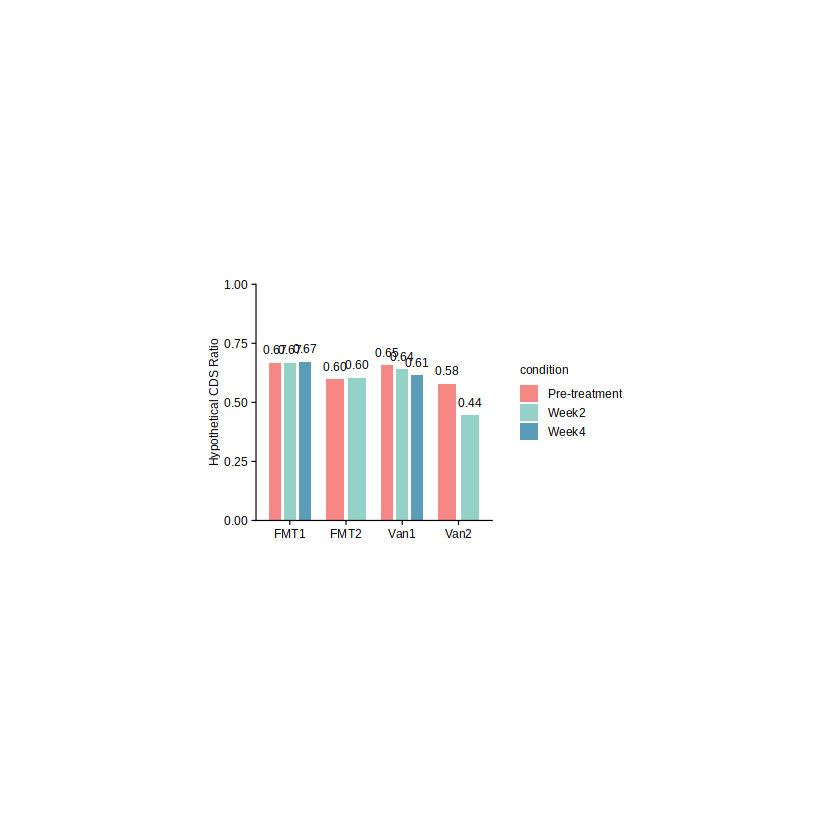

In [6]:
#total hypo cds stat
# head(darksmdf)
darksmdf.st = darksmdf %>% group_by(sample,condition,group) %>% summarise(total_cds = sum(total_cds),
                                                                         hypothetical_cds = sum(hypothetical_cds))
darksmdf.st$hypothetical_rate = darksmdf.st$hypothetical_cds/darksmdf.st$total_cds

library(tidyplots)
my_colors <- 
  new_color_scheme(c("#f25f5c","#70c1b3","#247ba0"),
                   name = "my_custom_color_scheme")
my_colors
p1.0 = darksmdf.st |> 
  tidyplot(x = group, y = hypothetical_rate, color = condition) |> 
  add_mean_bar(alpha = 0.75) |> 
  add_mean_value(accuracy = 0.01,color = "black") |>
  adjust_y_axis(limits = c(0,1)) |>
  adjust_y_axis_title(title = "Hypothetical CDS Ratio") |>
adjust_x_axis_title(title = "") |>
  # adjust_colors(colors_discrete_rainbow)
adjust_colors(new_colors = my_colors)
p1.0
ggexport(p1.0,
         filename = "downstream_analysis/figures/f.rv.dark_contig_cds_stat_6samples_26_06_05.pdf",
        width = 5,height = 4)

Warning message:
“Duplicated aesthetics after name standardisation: width”
file saved to downstream_analysis/figures/f.rv.Hypothetical_cds_percell_boxplot_stat_6samples_26_06_05.pdf



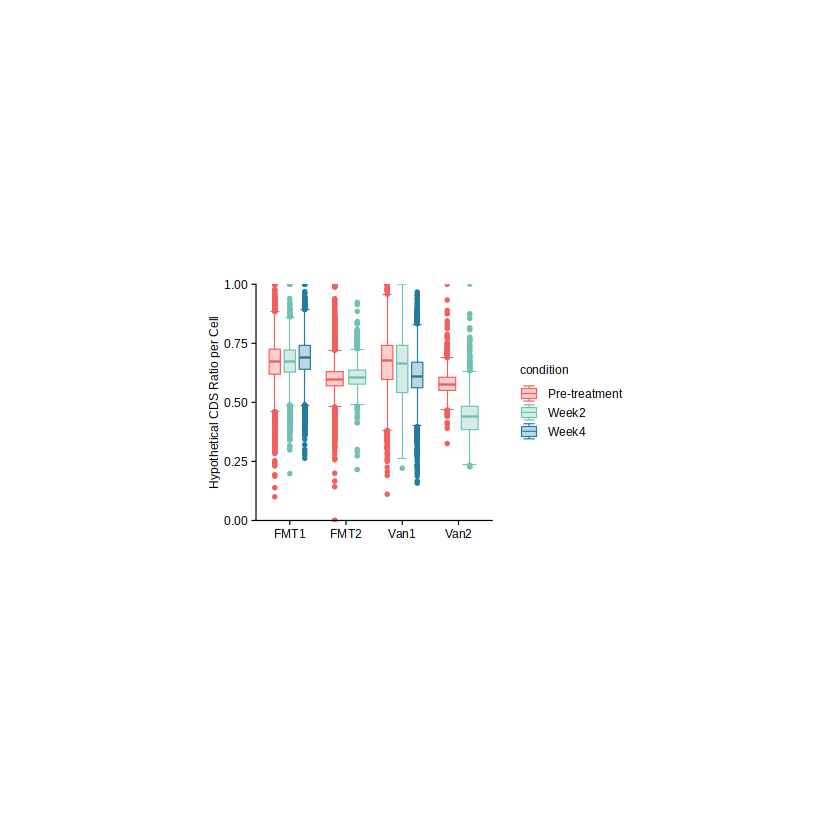

In [7]:
p1.0 = darksmdf |> 
  tidyplot(x = group, y = hypothetical_rate, color = condition) |> 
  add_boxplot(width = 0.5) |> 
  # add_test_pvalue() |>
  # add_mean_value(accuracy = 0.01,color = "black") |>
  adjust_y_axis(limits = c(0,1)) |>
  adjust_y_axis_title(title = "Hypothetical CDS Ratio per Cell") |>
  adjust_x_axis_title(title = "") |>
  # adjust_colors(colors_discrete_rainbow)
  adjust_colors(new_colors = my_colors)
p1.0
ggexport(p1.0,
         filename = "downstream_analysis/figures/f.rv.Hypothetical_cds_percell_boxplot_stat_6samples_26_06_05.pdf",
        width = 5,height = 4)

In [8]:
darksmdf = darksmdf %>% group_by(species) %>% mutate(cellnum = length(unique(name)),total_species_cds = sum(total_cds))
head(darksmdf)

cell_id,sample,species,name,GCA,ANI,db,condition,order,class,⋯,total_cds,known_cds,hypothetical_cds,hypothetical_rate,short_hyp_cds_..300bp,medium_hyp_cds_301_900bp,long_hyp_cds_.900bp,genus,cellnum,total_species_cds
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<chr>,<int>,<int>
AAACCTG_AAACGTC_TCTGGAA,A2,Mediterraneibacter gnavus,AAACCTG_AAACGTC_TCTGGAA,GCF_030167985.1,97.33,refseq,Week2,Lachnospirales,Clostridia,⋯,1941,840,1101,0.5672334,345,536,220,Mediterraneibacter gnavus,4503,3939439
AAACCTG_AACCATG_TTAGGCA,A1,Blautia coccoides,AAACCTG_AACCATG_TTAGGCA,GCF_034355335.1,98.64,refseq,Pre-treatment,Lachnospirales,Clostridia,⋯,1112,429,683,0.6142086,208,347,128,Blautia coccoides,694,691802
AAACCTG_AACTCAG_TCGAGGC,B2,Raoultella planticola,AAACCTG_AACTCAG_TCGAGGC,GCF_033870315.1,99.14,refseq,Week2,Enterobacterales,Gammaproteobacteria,⋯,393,233,160,0.4071247,59,89,12,Raoultella planticola,309,291716
AAACCTG_AATCGGT_CGGAGTC,A1,Mediterraneibacter gnavus,AAACCTG_AATCGGT_CGGAGTC,GCF_009831375.1,97.21,refseq,Pre-treatment,Lachnospirales,Clostridia,⋯,1039,407,632,0.6082772,208,317,107,Mediterraneibacter gnavus ATCC 29149,4503,3939439
AAACCTG_AATCGGT_GCATGAT,A1,Mediterraneibacter gnavus,AAACCTG_AATCGGT_GCATGAT,GCF_025152275.1,97.79,refseq,Pre-treatment,Lachnospirales,Clostridia,⋯,998,415,583,0.5841683,209,281,93,Mediterraneibacter gnavus ATCC 29149,4503,3939439
AAACCTG_AATCGGT_TCTGGAA,B1,[Clostridium] innocuum,AAACCTG_AATCGGT_TCTGGAA,GCF_012271835.1,98.55,refseq,Pre-treatment,Clostridiales,Clostridia,⋯,457,192,265,0.5798687,70,146,49,,2181,1204481


[1] 146

species,hypothetical_rate
<chr>,<dbl>
Pseudomonas aeruginosa,0.8733515
Dysgonomonas capnocytophagoides,0.8615695
Bacteroides xylanisolvens,0.7739037
Bacteroides ovatus,0.7704459
Bacteroides thetaiotaomicron,0.7568921
Parabacteroides goldsteinii,0.7555640


file saved to downstream_analysis/figures/f.rv.Hypothetical_cds_single_cell_species_26_06_05.pdf



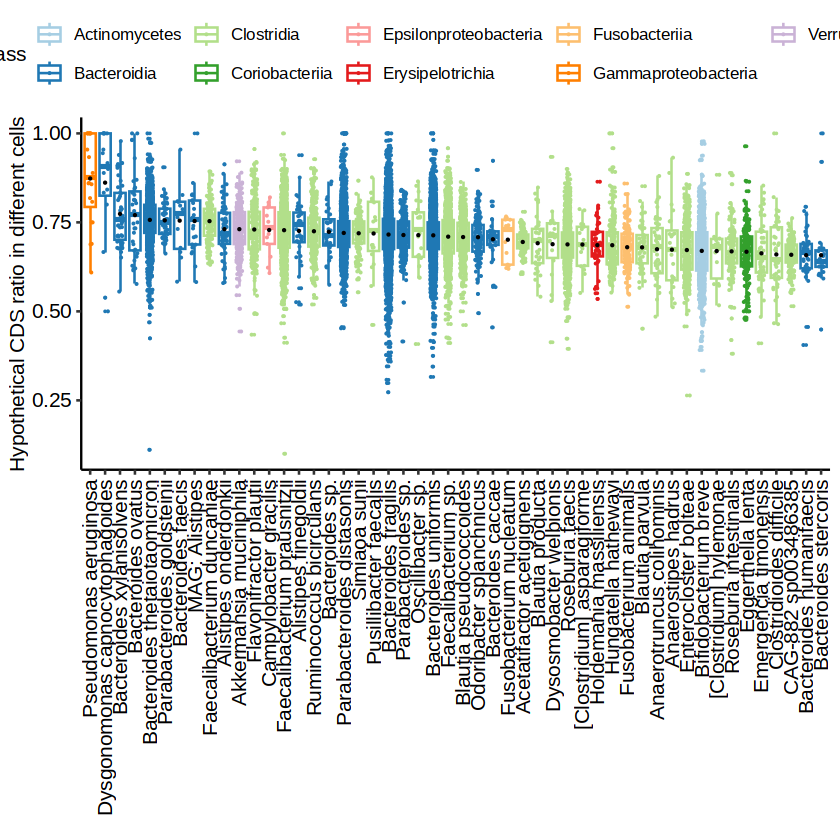

In [9]:
# pbidf = merge(pbidf,tax_df,by = "species")
ctgst1 = darksmdf[darksmdf$cellnum > 10 & darksmdf$total_species_cds > 100 & !is.na(darksmdf$species),]
ctgst1.st = ctgst1 %>% group_by(species) %>% summarise(hypothetical_rate = mean(hypothetical_rate))
# ctgst1.st = ctgst1.st[ctgst1.st$dark_contig_ratio > 0,]
nrow(ctgst1.st)
ctgst1.st = ctgst1.st[order(-ctgst1.st$hypothetical_rate),]
ctgst1.st = ctgst1.st[1:50,]
head(ctgst1.st)
ctgst1 = ctgst1[ctgst1$species %in% ctgst1.st$species,]
ctgst1$species = factor(ctgst1$species,levels = ctgst1.st$species)
p1.1 = ggplot(ctgst1,aes(x = species,y = hypothetical_rate,color = class)) + 
    geom_boxplot(outlier.size = 0) + geom_jitter(size = 0.01,width = 0.2) +
    geom_point(data = ctgst1.st, aes(x = species, y = hypothetical_rate), 
              size = 0.1, color = "black") +
    # scale_fill_manual(values = color_vector) +
    scale_fill_brewer(palette = "Paired") +
    scale_color_brewer(palette = "Paired") +
    theme_pubr() +
    xlab("") + ylab("Hypothetical CDS ratio in different cells") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p1.1
ggexport(p1.1,filename = "downstream_analysis/figures/f.rv.Hypothetical_cds_single_cell_species_26_06_05.pdf",width = 12,height = 6)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by species and class.
ℹ Output is grouped by species.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(species, class))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
file saved to downstream_analysis/figures/f.rv.hypothetical_cds_species_bar_26_06_05.pdf



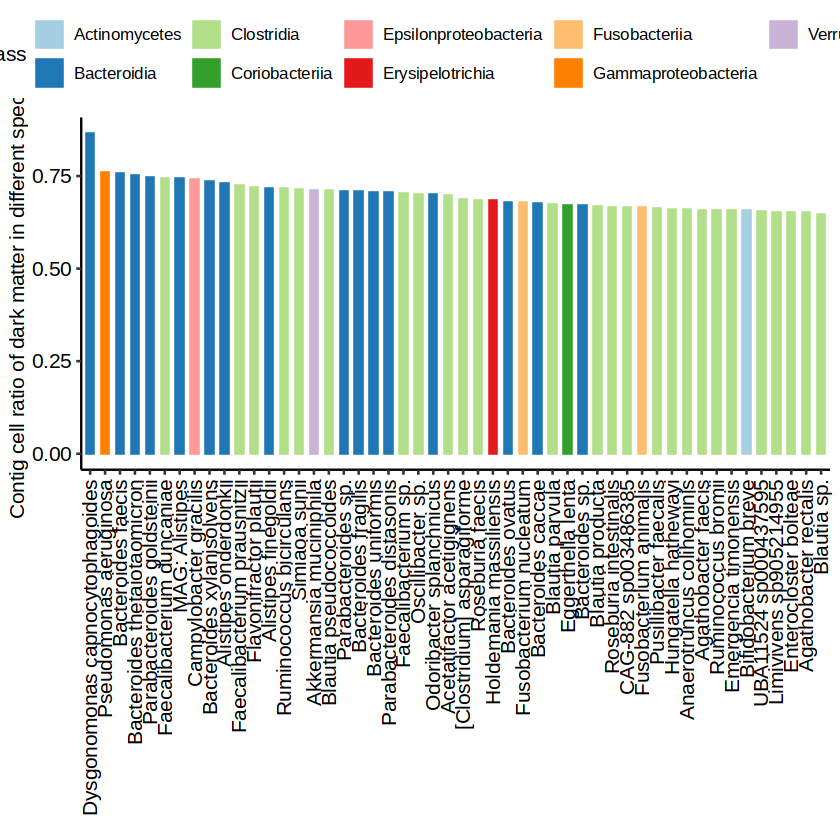

In [10]:
ctgst2 = darksmdf %>% group_by(species,class) %>% summarise(cellnum = length(unique(name)),
                                                      total_cds = sum(total_cds),
                                                     hypothetical_cds = sum(hypothetical_cds))

ctgst2$hypothetical_rate = ctgst2$hypothetical_cds/ctgst2$total_cds
ctgst2 = ctgst2[ctgst2$cellnum > 10,]
ctgst2 = ctgst2[order(-ctgst2$hypothetical_rate),]
ctgst2 = ctgst2[1:50,]

ctgst2$species = factor(ctgst2$species,levels = ctgst2$species)
p1.2 = ggplot(ctgst2,aes(x = species,y = hypothetical_rate,fill = class,color = class)) + 
    geom_bar(width = 0.5,stat = "identity") + 
    #scale_fill_manual(values = color_vector) +
    scale_fill_brewer(palette = "Paired") +
    scale_color_brewer(palette = "Paired") +
    theme_pubr() +
    xlab("") + ylab("Contig cell ratio of dark matter in different species") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p1.2
ggexport(p1.2,filename = "downstream_analysis/figures/f.rv.hypothetical_cds_species_bar_26_06_05.pdf",width = 12,height = 6)

### Stat single species change

In [11]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(forcats)
library(scales)
library(purrr)
library(ggrepel)


Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths


The following object is masked from ‘package:S4Vectors’:

    expand


Warning message:
“package ‘forcats’ was built under R version 4.3.3”
Warning message:
“package ‘scales’ was built under R version 4.3.3”

Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal



Attaching package: ‘purrr’


The following object is masked from ‘package:scales’:

    discard


The following object is masked from ‘package:GenomicRanges’:

    reduce


The following object is masked from ‘package:data.table’:

    transpose


The following object is masked from ‘package:XVector’:

    compact


The following object is masked from ‘package:IRanges’:

    reduce




In [18]:
darksmdf$group2 = darksmdf$group
darksmdf$group = substr(darksmdf$group,1,nchar(darksmdf$group) - 1)
unique(darksmdf$group)
unique(darksmdf$group2)

[1] "FMT" "Van"

[1] "FMT2" "Van2" "Van1" "FMT1"

In [19]:
darksmdf2 <- darksmdf %>%
  ungroup() %>%
  mutate(
    condition2 = case_when(
      condition %in% c("Pre-treatment", "Pretreatment", "Pre") ~ "Pre",
      condition %in% c("Week2", "Week4", "Ontreatment", "Posttreatment", "Post") ~ "Post",
      TRUE ~ as.character(condition)
    ),
    condition2 = factor(condition2, levels = c("Pre", "Post")),
    species = as.character(species),
    group = as.character(group),
    cell_id = as.character(cell_id),
    sample = as.character(sample),
    hypothetical_rate = as.numeric(hypothetical_rate),
    total_cds = as.numeric(total_cds),
    hypothetical_cds = as.numeric(hypothetical_cds)
  ) %>%
  filter(
    !is.na(group),
    !is.na(species),
    !is.na(condition2),
    !is.na(hypothetical_rate),
    total_cds > 0
  )

group_species_keep <- darksmdf2 %>%
  count(group, species, condition2, name = "cell_n") %>%
  pivot_wider(
    names_from = condition2,
    values_from = cell_n,
    values_fill = 0
  ) %>%
  filter(Pre >= 10, Post >= 10)

darksmdf_test <- darksmdf2 %>%
  semi_join(
    group_species_keep %>% select(group, species),
    by = c("group", "species")
  )

In [20]:
wilcox_group_species <- darksmdf_test %>%
  group_by(group, species) %>%
  summarise(
    pre_cell_n = sum(condition2 == "Pre"),
    post_cell_n = sum(condition2 == "Post"),

    pre_mean = mean(hypothetical_rate[condition2 == "Pre"], na.rm = TRUE),
    post_mean = mean(hypothetical_rate[condition2 == "Post"], na.rm = TRUE),
    pre_median = median(hypothetical_rate[condition2 == "Pre"], na.rm = TRUE),
    post_median = median(hypothetical_rate[condition2 == "Post"], na.rm = TRUE),

    delta_mean = post_mean - pre_mean,
    delta_median = post_median - pre_median,

    p_value = tryCatch(
      wilcox.test(
        hypothetical_rate[condition2 == "Post"],
        hypothetical_rate[condition2 == "Pre"]
      )$p.value,
      error = function(e) NA_real_
    ),

    .groups = "drop"
  ) %>%
  group_by(group) %>%
  mutate(
    padj = p.adjust(p_value, method = "BH")
  ) %>%
  ungroup() %>%
  mutate(
    sig_label = case_when(
      padj < 0.001 ~ "***",
      padj < 0.01 ~ "**",
      padj < 0.05 ~ "*",
      TRUE ~ ""
    ),
    direction = case_when(
      padj < 0.05 & delta_mean > 0.05 ~ "Increased after treatment",
      padj < 0.05 & delta_mean < -0.05 ~ "Decreased after treatment",
      TRUE ~ "Not significant"
    )
  ) %>%
  arrange(group, padj)

wilcox_group_species
prop_test_one <- function(pre_hyp, pre_total, post_hyp, post_total) {
  if (
    is.na(pre_total) || is.na(post_total) ||
    pre_total == 0 || post_total == 0
  ) {
    return(NA_real_)
  }

  prop.test(
    x = c(post_hyp, pre_hyp),
    n = c(post_total, pre_total)
  )$p.value
}
prop_group_species <- darksmdf_test %>%
  group_by(group, species, condition2) %>%
  summarise(
    total_cds_sum = sum(total_cds, na.rm = TRUE),
    hypothetical_cds_sum = sum(hypothetical_cds, na.rm = TRUE),
    hypothetical_rate_sum = hypothetical_cds_sum / total_cds_sum,
    cell_n = n_distinct(cell_id),
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = condition2,
    values_from = c(
      total_cds_sum,
      hypothetical_cds_sum,
      hypothetical_rate_sum,
      cell_n
    )
  ) %>%
  mutate(
    p_value_prop = pmap_dbl(
      list(
        hypothetical_cds_sum_Pre,
        total_cds_sum_Pre,
        hypothetical_cds_sum_Post,
        total_cds_sum_Post
      ),
      prop_test_one
    ),
    delta_prop = hypothetical_rate_sum_Post - hypothetical_rate_sum_Pre
  ) %>%
  group_by(group) %>%
  mutate(
    padj_prop = p.adjust(p_value_prop, method = "BH")
  ) %>%
  ungroup() %>%
  arrange(group, padj_prop)

prop_group_species
group_species_darkmatter_stat <- wilcox_group_species %>%
  left_join(
    prop_group_species %>%
      select(
        group,
        species,
        hypothetical_rate_sum_Pre,
        hypothetical_rate_sum_Post,
        delta_prop,
        p_value_prop,
        padj_prop
      ),
    by = c("group", "species")
  ) %>%
  arrange(group, padj)

group_species_darkmatter_stat
sig_group_species_darkmatter <- group_species_darkmatter_stat %>%
  filter(padj < 0.05,abs(delta_mean) > 0.05) %>%
  arrange(group, padj)

sig_group_species_darkmatter

Warning message:
“There were 5 warnings in `summarise()`.
The first warning was:
ℹ In argument: `p_value = tryCatch(...)`.
ℹ In group 8: `group = "FMT"`, `species = "Bacteroides thetaiotaomicron"`.
Caused by warning in `wilcox.test.default()`:
! cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 4 remaining warnings.”


group,species,pre_cell_n,post_cell_n,pre_mean,post_mean,pre_median,post_median,delta_mean,delta_median,p_value,padj,sig_label,direction
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
FMT,Agathobacter rectalis,1971,2473,0.6451205,0.6658109,0.6428571,0.6634051,0.020690372,0.020547945,3.480188e-28,1.705292e-26,***,Not significant
FMT,Faecalibacterium prausnitzii,1176,164,0.7207212,0.7805799,0.7213523,0.7864122,0.059858723,0.065059933,7.121549e-22,1.744780e-20,***,Increased after treatment
FMT,Bacteroides uniformis,1847,1749,0.7043999,0.7206568,0.7026604,0.7192308,0.016256849,0.016570362,2.823410e-18,4.611569e-17,***,Not significant
FMT,Faecalibacterium sp.,1008,68,0.7050603,0.7730877,0.7024301,0.7836817,0.068027375,0.081251556,3.329548e-14,4.078697e-13,***,Increased after treatment
FMT,Bacteroides fragilis,872,1860,0.7081541,0.6956401,0.7095735,0.6935900,-0.012514069,-0.015983519,6.422818e-10,5.245301e-09,***,Not significant
FMT,Flavonifractor plautii,148,75,0.7136235,0.7802755,0.7102934,0.7794872,0.066651948,0.069193789,5.390585e-10,5.245301e-09,***,Increased after treatment
FMT,Ruminococcus bromii,110,410,0.6158120,0.6650228,0.6188022,0.6666667,0.049210868,0.047864507,2.054133e-08,1.437893e-07,***,Not significant
FMT,Mediterraneibacter faecis,1144,348,0.5792122,0.6062945,0.5822940,0.6029516,0.027082333,0.020657570,1.489393e-07,9.122531e-07,***,Not significant
FMT,Hungatella effluvii,12,55,0.6604043,0.5887114,0.6579977,0.5914742,-0.071692844,-0.066523468,3.222929e-07,1.754706e-06,***,Decreased after treatment


group,species,total_cds_sum_Pre,total_cds_sum_Post,hypothetical_cds_sum_Pre,hypothetical_cds_sum_Post,hypothetical_rate_sum_Pre,hypothetical_rate_sum_Post,cell_n_Pre,cell_n_Post,p_value_prop,delta_prop,padj_prop
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
FMT,Faecalibacterium prausnitzii,318948,51729,228354,39792,0.7159600,0.7692397,1145,160,2.746777e-139,0.053279723,1.345921e-137
FMT,Bacteroides fragilis,392428,1008567,276139,688372,0.7036679,0.6825248,858,1824,4.813379e-130,-0.021143124,1.179278e-128
FMT,Agathobacter rectalis,688589,1052529,442580,691676,0.6427346,0.6571562,1947,2417,6.749365e-85,0.014421604,1.102396e-83
FMT,Flavonifractor plautii,43382,26907,30661,20617,0.7067678,0.7662318,144,74,1.276337e-66,0.059464052,1.563513e-65
FMT,Bacteroides uniformis,712804,682890,497658,485371,0.6981695,0.7107602,1806,1702,1.125923e-59,0.012590669,1.103404e-58
FMT,Faecalibacterium sp.,269753,15514,188592,11770,0.6991285,0.7586696,982,66,5.508579e-56,0.059541127,4.498673e-55
FMT,Hungatella effluvii,8758,79230,5778,46648,0.6597397,0.5887669,12,55,1.084460e-37,-0.070972785,7.591222e-37
FMT,Thomasclavelia ramosa,563610,187581,319230,109336,0.5664023,0.5828735,822,197,9.533340e-36,0.016471233,5.839171e-35
FMT,Phocaeicola vulgatus,224675,10822,144619,7557,0.6436809,0.6982998,521,41,4.287171e-31,0.054618887,2.334127e-30


group,species,pre_cell_n,post_cell_n,pre_mean,post_mean,pre_median,post_median,delta_mean,delta_median,p_value,padj,sig_label,direction,hypothetical_rate_sum_Pre,hypothetical_rate_sum_Post,delta_prop,p_value_prop,padj_prop
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FMT,Agathobacter rectalis,1971,2473,0.6451205,0.6658109,0.6428571,0.6634051,0.020690372,0.020547945,3.480188e-28,1.705292e-26,***,Not significant,0.6427346,0.6571562,0.0144216043,6.749365e-85,1.102396e-83
FMT,Faecalibacterium prausnitzii,1176,164,0.7207212,0.7805799,0.7213523,0.7864122,0.059858723,0.065059933,7.121549e-22,1.744780e-20,***,Increased after treatment,0.7159600,0.7692397,0.0532797231,2.746777e-139,1.345921e-137
FMT,Bacteroides uniformis,1847,1749,0.7043999,0.7206568,0.7026604,0.7192308,0.016256849,0.016570362,2.823410e-18,4.611569e-17,***,Not significant,0.6981695,0.7107602,0.0125906689,1.125923e-59,1.103404e-58
FMT,Faecalibacterium sp.,1008,68,0.7050603,0.7730877,0.7024301,0.7836817,0.068027375,0.081251556,3.329548e-14,4.078697e-13,***,Increased after treatment,0.6991285,0.7586696,0.0595411268,5.508579e-56,4.498673e-55
FMT,Bacteroides fragilis,872,1860,0.7081541,0.6956401,0.7095735,0.6935900,-0.012514069,-0.015983519,6.422818e-10,5.245301e-09,***,Not significant,0.7036679,0.6825248,-0.0211431240,4.813379e-130,1.179278e-128
FMT,Flavonifractor plautii,148,75,0.7136235,0.7802755,0.7102934,0.7794872,0.066651948,0.069193789,5.390585e-10,5.245301e-09,***,Increased after treatment,0.7067678,0.7662318,0.0594640517,1.276337e-66,1.563513e-65
FMT,Ruminococcus bromii,110,410,0.6158120,0.6650228,0.6188022,0.6666667,0.049210868,0.047864507,2.054133e-08,1.437893e-07,***,Not significant,0.6283263,0.6638967,0.0355703914,2.725389e-29,1.214037e-28
FMT,Mediterraneibacter faecis,1144,348,0.5792122,0.6062945,0.5822940,0.6029516,0.027082333,0.020657570,1.489393e-07,9.122531e-07,***,Not significant,0.5869145,0.6050173,0.0181027915,5.838332e-21,2.200602e-20
FMT,Hungatella effluvii,12,55,0.6604043,0.5887114,0.6579977,0.5914742,-0.071692844,-0.066523468,3.222929e-07,1.754706e-06,***,Decreased after treatment,0.6597397,0.5887669,-0.0709727854,1.084460e-37,7.591222e-37


group,species,pre_cell_n,post_cell_n,pre_mean,post_mean,pre_median,post_median,delta_mean,delta_median,p_value,padj,sig_label,direction,hypothetical_rate_sum_Pre,hypothetical_rate_sum_Post,delta_prop,p_value_prop,padj_prop
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FMT,Faecalibacterium prausnitzii,1176,164,0.7207212,0.7805799,0.7213523,0.7864122,0.05985872,0.06505993,7.121549e-22,1.744780e-20,***,Increased after treatment,0.7159600,0.7692397,0.053279723,2.746777e-139,1.345921e-137
FMT,Faecalibacterium sp.,1008,68,0.7050603,0.7730877,0.7024301,0.7836817,0.06802737,0.08125156,3.329548e-14,4.078697e-13,***,Increased after treatment,0.6991285,0.7586696,0.059541127,5.508579e-56,4.498673e-55
FMT,Flavonifractor plautii,148,75,0.7136235,0.7802755,0.7102934,0.7794872,0.06665195,0.06919379,5.390585e-10,5.245301e-09,***,Increased after treatment,0.7067678,0.7662318,0.059464052,1.276337e-66,1.563513e-65
FMT,Hungatella effluvii,12,55,0.6604043,0.5887114,0.6579977,0.5914742,-0.07169284,-0.06652347,3.222929e-07,1.754706e-06,***,Decreased after treatment,0.6597397,0.5887669,-0.070972785,1.084460e-37,7.591222e-37
FMT,Hungatella hathewayi,24,178,0.7725316,0.6738636,0.7555857,0.6584266,-0.09866802,-0.09715912,1.736551e-06,8.166412e-06,***,Decreased after treatment,0.7255253,0.6584736,-0.067051652,1.371507e-29,6.720384e-29
FMT,Phocaeicola vulgatus,529,41,0.6572935,0.7078992,0.6552217,0.6990291,0.05060572,0.04380738,9.397254e-06,3.837212e-05,***,Increased after treatment,0.6436809,0.6982998,0.054618887,4.287171e-31,2.334127e-30
FMT,Faecalibacterium duncaniae,139,23,0.7459219,0.7992848,0.7466667,0.8085106,0.05336287,0.06184397,2.463863e-05,9.286867e-05,***,Increased after treatment,0.7368979,0.7815812,0.044683260,2.564295e-17,8.376696e-17
FMT,Emergencia timonensis,18,36,0.6044029,0.6873582,0.6127771,0.6662921,0.08295527,0.05351503,1.500918e-03,4.085832e-03,**,Increased after treatment,0.6093478,0.6646358,0.055288029,1.304362e-08,3.363881e-08
FMT,Sellimonas intestinalis,20,27,0.5731224,0.6515999,0.5731540,0.6288210,0.07847745,0.05566700,8.594522e-03,2.005388e-02,*,Increased after treatment,0.6109396,0.6330641,0.022124414,7.202476e-03,1.138456e-02


Warning message:
“Removed 46 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
file saved to downstream_analysis/figures/f.rv.pre-post_species_hypocds_change_26_06_05.pdf

Warning message:
“Removed 46 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


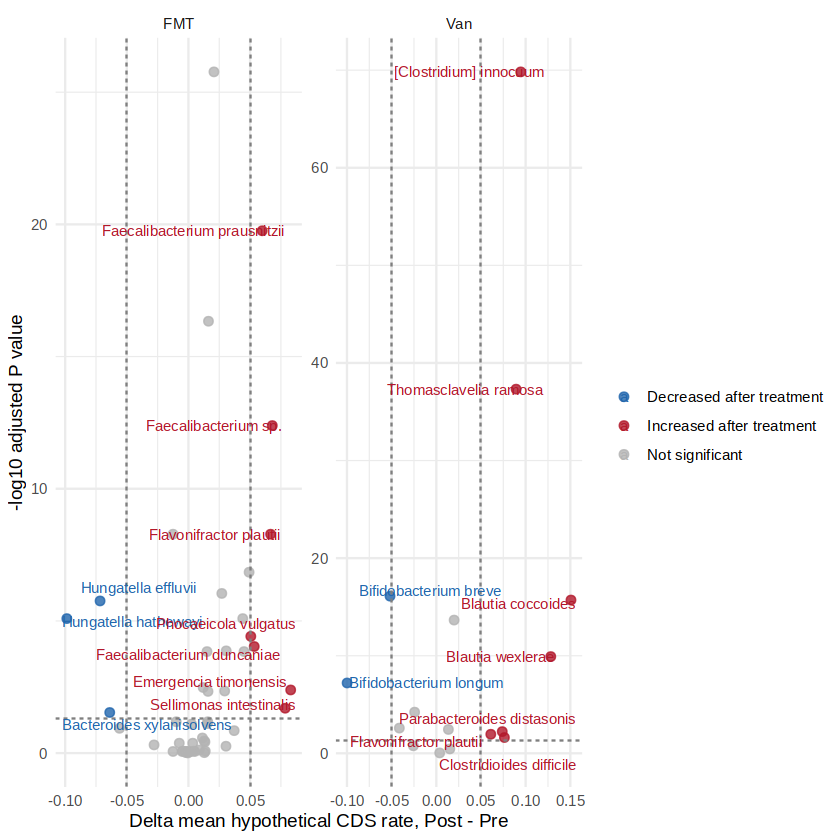

In [21]:
p_volcano_group <- group_species_darkmatter_stat %>%
  mutate(
    neglog10_padj = -log10(padj),
    species_label = ifelse(padj < 0.05 & abs(delta_mean) >= 0.05, species, NA)
  ) %>%
  ggplot(aes(x = delta_mean, y = neglog10_padj, color = direction)) +
  geom_point(size = 2, alpha = 0.8) +
  geom_vline(xintercept = 0.05, linetype = "dashed", color = "grey50") +
   geom_vline(xintercept = -0.05, linetype = "dashed", color = "grey50") +
   geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "grey50") +
  ggrepel::geom_text_repel(
    aes(label = species_label),
    size = 3,
    max.overlaps = 30
  ) +
  facet_wrap(~ group, scales = "free") +
  scale_color_manual(
    values = c(
      "Increased after treatment" = "#B2182B",
      "Decreased after treatment" = "#2166AC",
      "Not significant" = "grey70"
    )
  ) +
  labs(
    x = "Delta mean hypothetical CDS rate, Post - Pre",
    y = "-log10 adjusted P value",
    color = ""
  ) +
  theme_minimal()
ggexport(p_volcano_group,filename = "downstream_analysis/figures/f.rv.pre-post_species_hypocds_change_26_06_05.pdf",width = 10,height = 4)
p_volcano_group

file saved to downstream_analysis/figures/f.rv.pre-post_species_hypocds_change_ht_rank_26_06_05.pdf



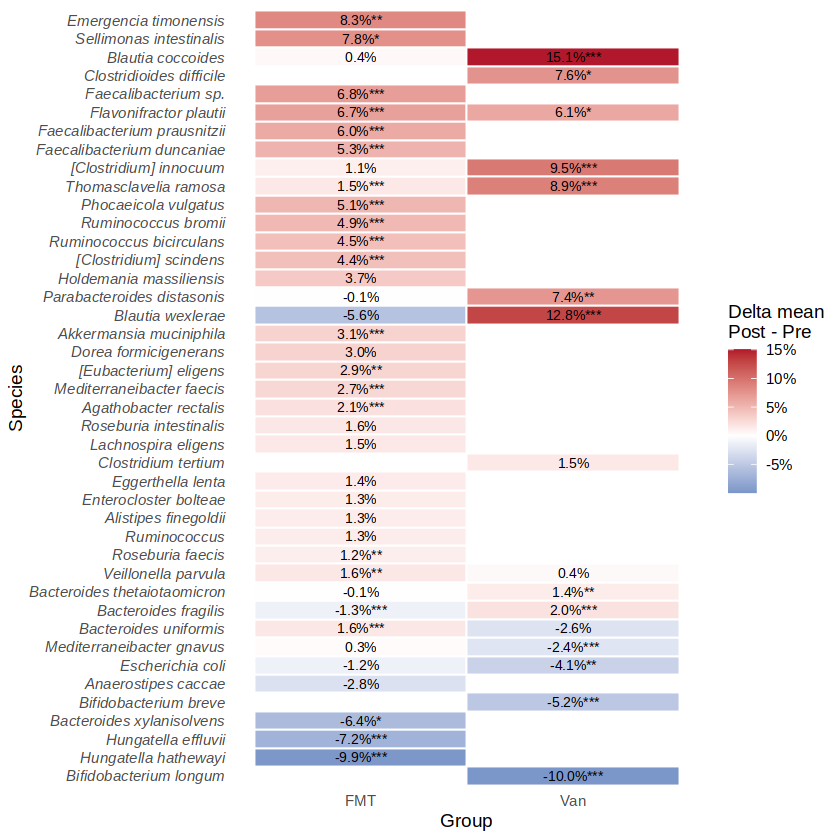

In [22]:
top_group_species <- group_species_darkmatter_stat[abs(group_species_darkmatter_stat$delta_mean) > 0.01,] %>%
  filter(pre_cell_n >= 10, post_cell_n >= 10) %>%
  arrange(padj) %>%
  slice_head(n = 80)

heatmap_group_df <- group_species_darkmatter_stat %>%
  filter(species %in% top_group_species$species) %>%
  mutate(
    species = fct_reorder(species, delta_mean, .fun = mean),
    label = paste0(sprintf("%.1f%%", delta_mean * 100), sig_label)
  )

p_heatmap_group <- ggplot(
  heatmap_group_df,
  aes(x = group, y = species, fill = delta_mean)
) +
  geom_tile(color = "white", linewidth = 0.4) +
  geom_text(aes(label = label), size = 2.8) +
  scale_fill_gradient2(
    low = "#2166AC",
    mid = "white",
    high = "#B2182B",
    midpoint = 0,
    labels = percent_format(),
    name = "Delta mean\nPost - Pre"
  ) +
  labs(
    x = "Group",
    y = "Species"
  ) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(face = "italic")
  )
ggexport(p_heatmap_group,filename = "downstream_analysis/figures/f.rv.pre-post_species_hypocds_change_ht_rank_26_06_05.pdf",
         width = 4,height = 6)

p_heatmap_group

In [23]:
top_sig_pairs <- sig_group_species_darkmatter %>%
  arrange(padj) %>%
  slice_head(n = 24) %>%
  mutate(pair_id = paste(group, species, sep = " | "))

plot_box_df <- darksmdf_test %>%
  mutate(pair_id = paste(group, species, sep = " | ")) %>%
  filter(pair_id %in% top_sig_pairs$pair_id) %>%
  mutate(
    pair_id = factor(pair_id, levels = top_sig_pairs$pair_id)
  )


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
file saved to downstream_analysis/figures/f.rv.pre-post_species_hypocds_change_box_facet_plot_26_06_05.pdf



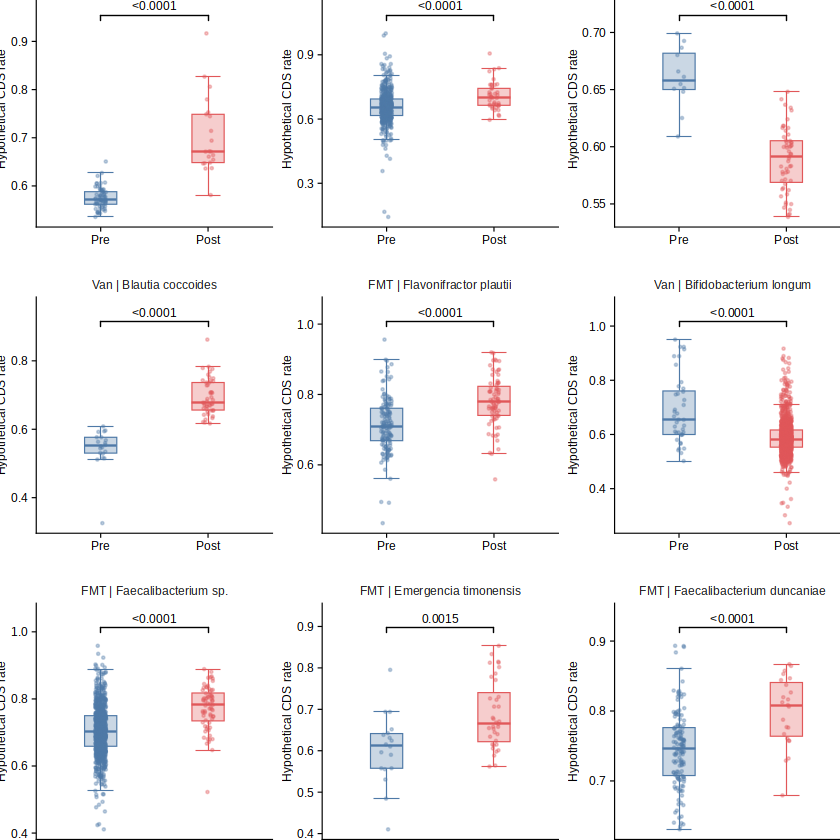

In [31]:
library(dplyr)
library(tidyplots)
library(scales)

plot_box_df2 <- plot_box_df %>%
  mutate(
    condition2 = factor(condition2, levels = c("Pre", "Post")),
    pair_id = factor(pair_id, levels = unique(pair_id))
  )

p_box_group <- plot_box_df2 |>
  tidyplot(
    x = condition2,
    y = hypothetical_rate,
    color = condition2
  ) |>
  add_boxplot(
    show_outliers = FALSE,
    box_width = 0.3
  ) |>
  add_data_points_jitter(
    jitter_width = 0.15,
    size = 0.25,
    alpha = 0.35
  ) |>
  add_test_pvalue(
    method = "wilcox_test",
    comparisons = list(c(1, 2)),
    label = "p.format",
    hide_info = TRUE,
    padding_top = 0.12
  ) |>
  adjust_colors(
    new_colors = c(
      "Pre" = "#4E79A7",
      "Post" = "#E15759"
    )
  ) |>
  add(
    ggplot2::scale_y_continuous(labels = scales::percent_format())
  ) |>
  adjust_x_axis(title = "") |>
  adjust_y_axis(title = "Hypothetical CDS rate") |>
  remove_legend() |>
  split_plot(
    by = pair_id,
    nrow = 3,
    scales = "free_y"
  )

p_box_group
ggexport(p_box_group,filename = "downstream_analysis/figures/f.rv.pre-post_species_hypocds_change_box_facet_plot_26_06_05.pdf",
         width = 12,height = 8)


## Cluster contig stat

In [32]:
head(darksmdf)

cell_id,sample,species,name,GCA,ANI,db,condition,order,class,⋯,known_cds,hypothetical_cds,hypothetical_rate,short_hyp_cds_..300bp,medium_hyp_cds_301_900bp,long_hyp_cds_.900bp,genus,cellnum,total_species_cds,group2
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<dbl>,<int>,<int>,<int>,<chr>,<int>,<int>,<chr>
AAACCTG_AAACGTC_TCTGGAA,A2,Mediterraneibacter gnavus,AAACCTG_AAACGTC_TCTGGAA,GCF_030167985.1,97.33,refseq,Week2,Lachnospirales,Clostridia,⋯,840,1101,0.5672334,345,536,220,Mediterraneibacter gnavus,4503,3939439,FMT2
AAACCTG_AACCATG_TTAGGCA,A1,Blautia coccoides,AAACCTG_AACCATG_TTAGGCA,GCF_034355335.1,98.64,refseq,Pre-treatment,Lachnospirales,Clostridia,⋯,429,683,0.6142086,208,347,128,Blautia coccoides,694,691802,FMT2
AAACCTG_AACTCAG_TCGAGGC,B2,Raoultella planticola,AAACCTG_AACTCAG_TCGAGGC,GCF_033870315.1,99.14,refseq,Week2,Enterobacterales,Gammaproteobacteria,⋯,233,160,0.4071247,59,89,12,Raoultella planticola,309,291716,Van2
AAACCTG_AATCGGT_CGGAGTC,A1,Mediterraneibacter gnavus,AAACCTG_AATCGGT_CGGAGTC,GCF_009831375.1,97.21,refseq,Pre-treatment,Lachnospirales,Clostridia,⋯,407,632,0.6082772,208,317,107,Mediterraneibacter gnavus ATCC 29149,4503,3939439,FMT2
AAACCTG_AATCGGT_GCATGAT,A1,Mediterraneibacter gnavus,AAACCTG_AATCGGT_GCATGAT,GCF_025152275.1,97.79,refseq,Pre-treatment,Lachnospirales,Clostridia,⋯,415,583,0.5841683,209,281,93,Mediterraneibacter gnavus ATCC 29149,4503,3939439,FMT2
AAACCTG_AATCGGT_TCTGGAA,B1,[Clostridium] innocuum,AAACCTG_AATCGGT_TCTGGAA,GCF_012271835.1,98.55,refseq,Pre-treatment,Clostridiales,Clostridia,⋯,192,265,0.5798687,70,146,49,,2181,1204481,Van2


In [47]:
# ## Build or load cluster-level dark matter table
# library(dplyr)
# library(readr)
# library(qs)

cltdf_file <- "data/dark_matter/summary/clusterdf_26_06_05.qs"
cluster_map_file <- "data/dark_matter/summary/all_merged_hypo_prodigal/cds_cluster_75_cluster.tsv"
library(dplyr)
library(stringr)
cluster_map <- read_tsv(cluster_map_file, show_col_types = FALSE, col_names = c("cluster_id","contig_id"))
cluster_map <- cluster_map %>%
  mutate(
    cell_id = str_remove(contig_id, "_[A-Z]+_[0-9]+_[0-9]+$")
  )
cluster_map$cluster_name <- paste0("cl", as.numeric(as.factor(cluster_map$cluster_id)))
head(cluster_map)

cltdf <- merge(
    darksmdf[, c(
      "cell_id", "sample", "species", "name", "condition", "order",
      "class", "group", "hypothetical_rate", "cellnum", "total_species_cds"
    )],
    cluster_map,
    by = "cell_id"
)
length(unique(darksmdf$cell_id))
length(unique(cltdf$cell_id))
qsave(cltdf, file = cltdf_file)

cluster_id,contig_id,cell_id,cluster_name
<chr>,<chr>,<chr>,<chr>
lib2_out_CAGCTAAACAGGCATACAGTCAGCCAAAT_OOEMDAAO_00038_1,lib2_out_CAGCTAAACAGGCATACAGTCAGCCAAAT_OOEMDAAO_00038_1,lib2_out_CAGCTAAACAGGCATACAGTCAGCCAAAT,cl2899614
lib2_out_CAGCTAAACAGGCATACAGTCAGCCAAAT_OOEMDAAO_00058_1,lib2_out_CAGCTAAACAGGCATACAGTCAGCCAAAT_OOEMDAAO_00058_1,lib2_out_CAGCTAAACAGGCATACAGTCAGCCAAAT,cl2899615
lib2_out_CAGCTAAACAGGCATACAGTCAGCCAAAT_OOEMDAAO_00058_1,lib2_out_AACCGCGACAGCGTTGGGGTCAGGGCTAA_NJAPDDJE_00087_1,lib2_out_AACCGCGACAGCGTTGGGGTCAGGGCTAA,cl2899615
lib2_out_CAGCTAAACAGGCATACAGTCAGCCAAAT_OOEMDAAO_00058_1,lib2_out_GACCTGGACAGGCACATAGTCAACCGTAA_MFGEPBLH_00063_1,lib2_out_GACCTGGACAGGCACATAGTCAACCGTAA,cl2899615
lib2_out_CAGCTAAACAGGCATACAGTCAGCCAAAT_OOEMDAAO_00058_1,lib1_out_AGCTCTCACAGACTTTCAGTCACGAACAT_MJHNCOAC_00672_1,lib1_out_AGCTCTCACAGACTTTCAGTCACGAACAT,cl2899615
lib2_out_CAGCTAAACAGGCATACAGTCAGCCAAAT_OOEMDAAO_00058_1,lib2_out_CGCTTCAACAGAACTCAGGTCAGAAATGA_HDBFGHFN_00205_1,lib2_out_CGCTTCAACAGAACTCAGGTCAGAAATGA,cl2899615


[1] 53785

[1] 53066

#### contig basic stat

In [48]:
cltdf2 <- cltdf %>%
  ungroup() %>%
  mutate(
    cell_id = as.character(cell_id),
    sample = as.character(sample),
    species = as.character(species),
    group = as.character(group),
    condition = as.character(condition),
    cluster_name = as.character(cluster_name),
    contig_id = as.character(contig_id)
  ) %>%
  distinct(
    cell_id, sample, species, name, condition, order, class, group,
    cluster_name, cluster_id, contig_id, hypothetical_rate,
    cellnum, total_species_cds
  )


cluster_size_summary <- cltdf2 %>%
  group_by(cluster_name) %>%
  summarise(
    dark_cds_n = n_distinct(contig_id),
    cell_n = n_distinct(cell_id),
    sample_n = n_distinct(sample),
    species_n = n_distinct(species),
    group_n = n_distinct(group),
    condition_n = n_distinct(condition),
    dominant_species = names(sort(table(species), decreasing = TRUE))[1],
    .groups = "drop"
  ) %>%
  arrange(desc(dark_cds_n), desc(cell_n), desc(sample_n))

cluster_size_summary

cluster_size_bins <- cluster_size_summary %>%
  mutate(
    cluster_size_bin = case_when(
      dark_cds_n == 1 ~ "1",
      dark_cds_n <= 5 ~ "2-5",
      dark_cds_n <= 10 ~ "6-10",
      dark_cds_n <= 50 ~ "11-50",
      dark_cds_n <= 100 ~ "51-100",
      TRUE ~ ">100"
    ),
    cluster_size_bin = factor(
      cluster_size_bin,
      levels = c("1", "2-5", "6-10", "11-50", "51-100", ">100")
    )
  ) %>%
  count(cluster_size_bin, name = "cluster_n") %>%
  mutate(freq = cluster_n / sum(cluster_n))

cluster_size_bins
darkmatter_overview <- cltdf2 %>%
  summarise(
    dark_cds_n = n_distinct(contig_id),
    cluster_n = n_distinct(cluster_name)
  )

darkmatter_overview

cluster_name,dark_cds_n,cell_n,sample_n,species_n,group_n,condition_n,dominant_species
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
cl3762506,3315,3033,8,68,2,3,Bacteroides fragilis
cl662242,3258,2755,10,84,2,3,Mediterraneibacter gnavus
cl286003,2989,2472,10,82,2,3,Mediterraneibacter gnavus
cl3529163,2950,2531,8,60,2,3,Bacteroides fragilis
cl3179565,2925,2274,9,82,2,3,Bacteroides uniformis
cl665306,2780,2433,10,72,2,3,Mediterraneibacter gnavus
cl3827791,2676,2167,9,77,2,3,Bacteroides uniformis
cl1513660,2657,2299,10,72,2,3,Mediterraneibacter gnavus
cl2485664,2616,2127,9,81,2,3,Bacteroides uniformis


cluster_size_bin,cluster_n,freq
<fct>,<int>,<dbl>
1,2214127,0.621133776
2-5,868946,0.243767277
6-10,212385,0.059580818
11-50,219969,0.061708373
51-100,29085,0.008159277
>100,20142,0.005650478


dark_cds_n,cluster_n
<int>,<int>
17592266,3564654


file saved to downstream_analysis/figures/f.rv.cds_cluster_overview_bar_26_06_05.pdf



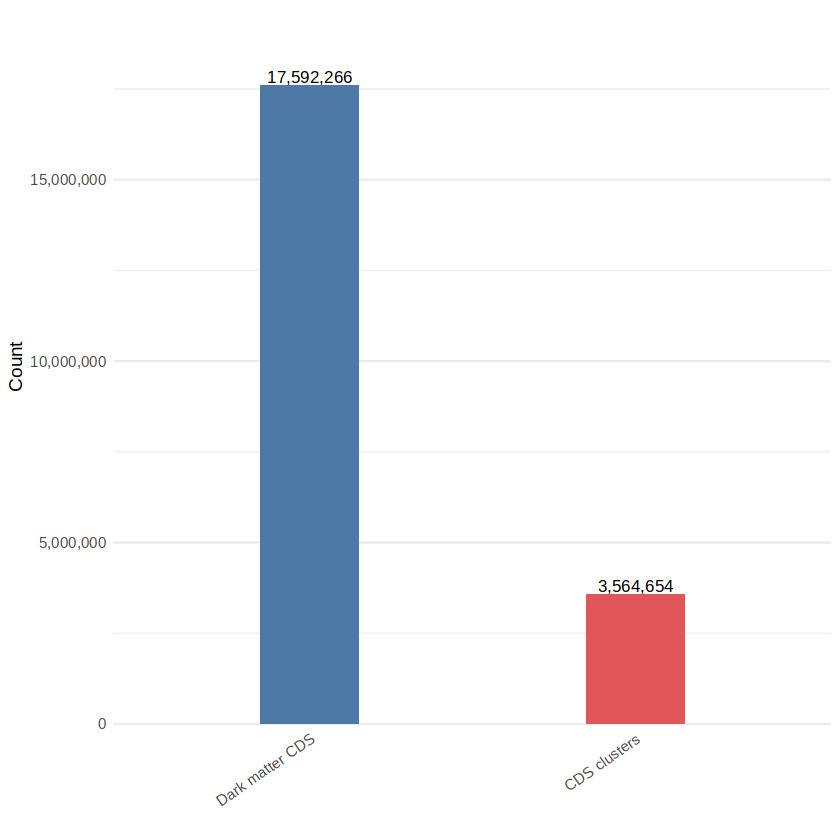

In [49]:
overview_plot_df <- darkmatter_overview %>%
  pivot_longer(
    cols = everything(),
    names_to = "metric",
    values_to = "n"
  ) %>%
  mutate(
    metric = recode(
      metric,
      dark_cds_n = "Dark matter CDS",
      cluster_n = "CDS clusters"
    ),
    metric = factor(
      metric,
      levels = c(
        "Dark matter CDS",
        "CDS clusters"
      )
    )
  )
p_overview_bar <- ggplot(
  overview_plot_df,
  aes(x = metric, y = n, fill = metric)
) +
  geom_col(width = 0.3) +
  geom_text(
    aes(label = comma(n)),
    vjust = -0.25,
    size = 3.5
  ) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  scale_fill_manual(
    values = c(
      "Dark matter CDS" = "#4E79A7",
      "CDS clusters" = "#E15759"
    )
  ) +
  labs(x = "", y = "Count") +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(angle = 35, hjust = 1)
  )

p_overview_bar
ggexport(p_overview_bar,filename = "downstream_analysis/figures/f.rv.cds_cluster_overview_bar_26_06_05.pdf",width = 4,height = 3)

In [50]:
head(cluster_size_bins)

cluster_size_bin,cluster_n,freq
<fct>,<int>,<dbl>
1,2214127,0.621133776
2-5,868946,0.243767277
6-10,212385,0.059580818
11-50,219969,0.061708373
51-100,29085,0.008159277
>100,20142,0.005650478


file saved to downstream_analysis/figures/f.rv.cds_cluster_number_distribution_bar_26_06_05.pdf



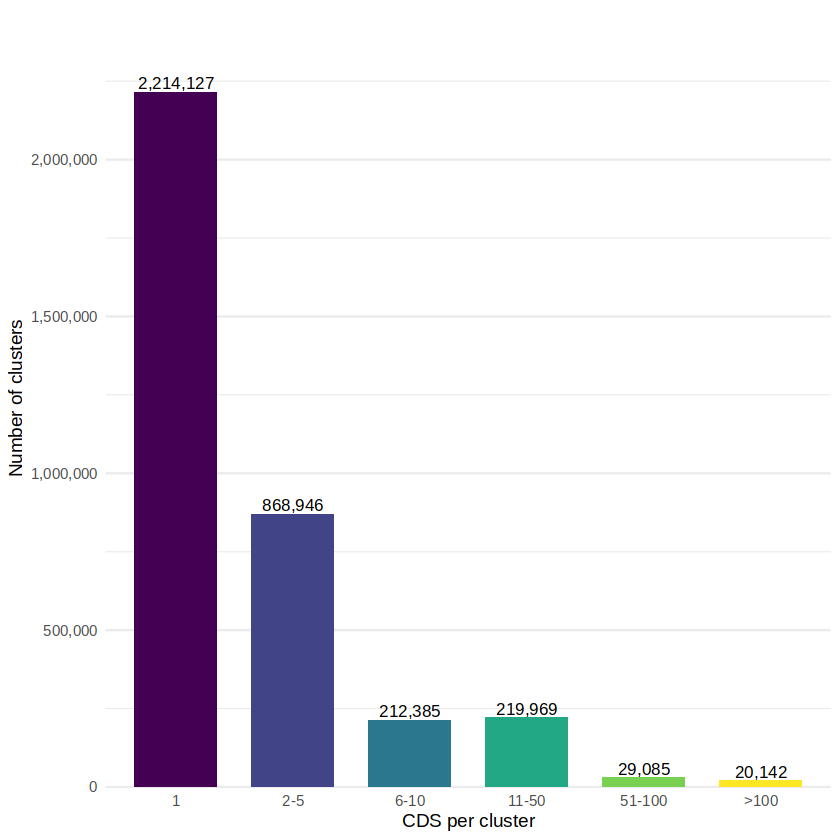

In [51]:
p_cluster_size_bin <- ggplot(
  cluster_size_bins,
  aes(x = cluster_size_bin, y = cluster_n, fill = cluster_size_bin)
) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = comma(cluster_n)),
    vjust = -0.25,
    size = 3.5
  ) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  scale_fill_viridis(discrete = T) +
  labs(
    x = "CDS per cluster",
    y = "Number of clusters"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank()
  )

p_cluster_size_bin
ggexport(p_cluster_size_bin,filename = "downstream_analysis/figures/f.rv.cds_cluster_number_distribution_bar_26_06_05.pdf",width = 4,height = 3)

#### Hub contig select

In [52]:
cltdf2 <- cltdf %>%
  ungroup() %>%
  mutate(
    condition2 = case_when(
      condition %in% c("Pre-treatment", "Pretreatment", "Pre") ~ "Pre",
      condition %in% c("Week2", "Week4", "Ontreatment", "Posttreatment", "Post") ~ "Post",
      TRUE ~ as.character(condition)
    ),
    condition2 = factor(condition2, levels = c("Pre", "Post")),
    cluster_name = as.character(cluster_name),
    species = as.character(species),
    group = as.character(group),
    sample = as.character(sample),
    cell_id = as.character(cell_id),
    hypothetical_rate = as.numeric(hypothetical_rate)
  ) %>%
  filter(
    !is.na(cluster_name),
    !is.na(species),
    !is.na(group),
    !is.na(condition2)
  ) %>%
  distinct(
    cluster_name, cluster_id, contig_id, cell_id, sample, group,
    condition2, species, order, class,
    hypothetical_rate, cellnum, total_species_cds
  )
cluster_overview <- cltdf2 %>%
  group_by(cluster_name) %>%
  summarise(
    cds_n = n_distinct(contig_id),
    cell_n = n_distinct(cell_id),
    sample_n = n_distinct(sample),
    group_n = n_distinct(group),
    condition_n = n_distinct(condition2),
    species_n = n_distinct(species),
    mean_cell_hypothetical_rate = mean(hypothetical_rate, na.rm = TRUE),
    max_cell_hypothetical_rate = max(hypothetical_rate, na.rm = TRUE),
    .groups = "drop"
  )

In [53]:
cluster_overview_filt <- cluster_overview %>%
  filter(
    cds_n >= 5,
    cell_n >= 10,
    sample_n >= 2
  )
nrow(cluster_overview_filt)
nrow(cluster_overview)
cltdf2 = cltdf2[cltdf2$cluster_name %in% cluster_overview_filt$cluster_name,]
nrow(cltdf2)
head(cltdf2)

[1] 250576

[1] 3564654

[1] 11150714

,cluster_name,cluster_id,contig_id,cell_id,sample,group,condition2,species,order,class,hypothetical_rate,cellnum,total_species_cds
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>
1,cl558142,GATCGAT_TACTTGT_ACGATAC_BIBIHLOC_00661_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01527_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
2,cl538369,GACTACA_GAAACTC_CGACTTC_IIKHPPGI_00583_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01162_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
3,cl502123,CTTCTCT_GTATAAG_TCTGGAA_DAEGBPMO_00033_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_00372_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
4,cl2792948,lib2_out_ATTCTACACAGCACTCCAGTCAAATCTTG_DFINIBOJ_00378_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01674_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
5,cl425366,CGTTCTG_TCAGATG_AGTGGGA_CJAGLNOB_00155_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01408_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
6,cl362947,CGAGAAG_GACGTGC_CGCGTTT_PJPMHMPN_00220_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01201_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439


In [54]:
# head(cltdf)
#length stat


cltdf = cltdf[cltdf$cluster_name %in% cluster_overview_filt$cluster_name,]
write.table(unique(cltdf$cluster_id),file = "data/dark_matter/summary/all_merged_hypo_prodigal/hub_cluster_ids.txt",
           row.names = F,quote = F)

In [55]:
library(ampir)
library(readr)
library(dplyr)

# =========================
# 1. 修改这里的路径和参数
# =========================
input_fasta <- "data/dark_matter/summary/all_merged_hypo_prodigal/cds_cluster_75_rep_seq.fasta"
output_dir <- "data/dark_matter/summary/all_merged_hypo_prodigal"
min_len <- 10
max_len <- 100
prob_cutoff <- 0.8
model_name <- "precursor"

dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

# =========================
# 2. 读入 fasta
# =========================
my_protein_df <- read_faa(input_fasta)

# 看一下列名，通常会有 seq_name 和 seq_aa
print(colnames(my_protein_df))

# 自动识别列名
seq_col <- intersect(c("seq_aa", "seq", "sequence"), colnames(my_protein_df))[1]
name_col <- intersect(c("seq_name", "name", "id", "header"), colnames(my_protein_df))[1]

if (is.na(seq_col) || is.na(name_col)) {
  stop(paste("无法识别序列列或名称列，当前列名为：", paste(colnames(my_protein_df), collapse = ", ")))
}

# =========================
# 3. 统计每条序列长度
# =========================
rep_len <- my_protein_df %>%
  mutate(
    cluster_id = sub("\\s.*$", "", .data[[name_col]]),
    aa_length = nchar(.data[[seq_col]])
  ) %>%
  select(cluster_id, aa_length) %>%
  distinct(cluster_id, .keep_all = TRUE)

head(rep_len)

write_tsv(
  rep_len,
  file.path(output_dir, "sequence_lengths.tsv"),
  col_names = TRUE
)

# =========================
# 4. 筛选 10-100 aa 的潜在 AMP
# =========================
amp_like_clusters <- rep_len %>%
  filter(aa_length >= min_len, aa_length <= max_len)

nrow(amp_like_clusters)

write_lines(
  amp_like_clusters$cluster_id,
  file.path(output_dir, paste0("amp_like_cluster_ids_", min_len, "_", max_len, "aa.txt"))
)

# 从原始 fasta 数据中提取对应序列
amp_like_df <- my_protein_df %>%
  mutate(cluster_id = sub("\\s.*$", "", .data[[name_col]])) %>%
  filter(cluster_id %in% amp_like_clusters$cluster_id) %>%
  distinct(cluster_id, .keep_all = TRUE)

nrow(amp_like_df)

df_to_faa(
  amp_like_df,
  file.path(output_dir, paste0("cds_cluster_75_rep_seq_", min_len, "_", max_len, "aa.fasta"))
)

# =========================
# 5. 预测潜在 AMP
# =========================
my_prediction <- predict_amps(amp_like_df, model = model_name)

head(my_prediction)

prediction_df <- bind_cols(
  amp_like_df %>%
    mutate(
      cluster_id = sub("\\s.*$", "", .data[[name_col]]),
      aa_length = nchar(.data[[seq_col]])
    ) %>%
    select(cluster_id, aa_length),
  my_prediction
)

write_tsv(
  prediction_df,
  file.path(output_dir, paste0("amp_predictions_", min_len, "_", max_len, "aa.tsv"))
)

# =========================
# 6. 保留 prob_AMP >= 0.8 的高置信 AMP
# =========================
my_predicted_amps <- amp_like_df[which(my_prediction$prob_AMP >= prob_cutoff), ]

nrow(my_predicted_amps)

df_to_faa(
  my_predicted_amps,
  file.path(output_dir, paste0("my_predicted_amps_prob_ge_", prob_cutoff, ".fasta"))
)

# 同时保存表格结果
predicted_amp_table <- prediction_df %>%
  filter(prob_AMP >= prob_cutoff)

write_tsv(
  predicted_amp_table,
  file.path(output_dir, paste0("my_predicted_amps_prob_ge_", prob_cutoff, ".tsv"))
)

cat("完成\n")
cat("总序列数:", nrow(my_protein_df), "\n")
cat("长度筛选后序列数:", nrow(amp_like_df), "\n")
cat("预测为 AMP 的序列数:", nrow(my_predicted_amps), "\n")

[1] "seq_name" "seq_aa"  


,cluster_id,aa_length
,<chr>,<int>
1,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01556_1,37
2,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01580_1,73
3,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01584_1,59
4,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01591_1,44
5,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01592_1,145
6,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01593_1,98


[1] 2573508

[1] 2573508

,seq_name,seq_aa,cluster_id,prob_AMP
,<chr>,<chr>,<chr>,<dbl>
1,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01556_1 # 3 # 113 # 1 # ID=919_1;partial=11;start_type=Edge;rbs_motif=None;rbs_spacer=None;gc_cont=0.243,GIRRYKKESYSKRFSEPLPEFYDRKIIFWNDEEKEFI,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01556_1,0.1136098351
2,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01580_1 # 1 # 219 # 1 # ID=935_1;partial=10;start_type=Edge;rbs_motif=None;rbs_spacer=None;gc_cont=0.484,VEKDGTDTVYSKDSKGNQEPYLSNERYPKISGVVVVAEGEGAHVIQNIQEAVQALFQVEAHKIKVMKMVTGR,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01580_1,0.0105292997
3,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01584_1 # 1 # 177 # 1 # ID=937_1;partial=10;start_type=Edge;rbs_motif=None;rbs_spacer=None;gc_cont=0.339,MMTDVTNVQNAFQMLIRAYIRAPLMMVSAMIMAFTINAQIAMVFLVAIIFLGVILVFL,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01584_1,0.0169443187
4,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01591_1 # 1 # 132 # 1 # ID=940_1;partial=10;start_type=Edge;rbs_motif=None;rbs_spacer=None;gc_cont=0.424,MKESIPLQFEETEALRFVKANKEGAQVTLDMGEDQVDAIVKKY,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01591_1,0.0009242859
5,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01593_1 # 1 # 294 # 1 # ID=942_1;partial=10;start_type=Edge;rbs_motif=None;rbs_spacer=None;gc_cont=0.340,MIKIGCANAYVRDINQNADVLRVYIHDCPSYIRKGFLFYKENREKIKALIPDNYRYTYTKNRSKKYEETILKVDQTSIYDTIEKKVEELEKTQYKRR,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01593_1,0.0028322878
6,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01609_1 # 1 # 204 # 1 # ID=949_1;partial=10;start_type=Edge;rbs_motif=None;rbs_spacer=None;gc_cont=0.471,VRVWDETGKESTWSEINFFEAGLLEKSDWKAQWICAEDQVSAPYFRKDFYKKETGKGHGLHLRAGIL,ACGCCGA_GTGCGGT_CGATTAT_IKADECCD_01609_1,0.0559434650


New names:
• `cluster_id` -> `cluster_id...1`
• `cluster_id` -> `cluster_id...5`


[1] 73844

完成
总序列数: 4377546 
长度筛选后序列数: 2573508 
预测为 AMP 的序列数: 73844 


## description dark matter contig cluster

### Basic hub cluster description

In [56]:
library(data.table)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggalluvial)
library(ggrepel)
library(forcats)
library(scales)
library(ggpubr)
library(readr)
safe_mode <- function(x, default = NA_character_) {
  x <- as.character(x)
  x <- x[!is.na(x) & x != ""]
  if (length(x) == 0) return(default)
  names(sort(table(x), decreasing = TRUE))[1]
}

safe_collapse <- function(x) {
  x <- as.character(x)
  x <- sort(unique(x[!is.na(x) & x != ""]))
  if (length(x) == 0) return(NA_character_)
  paste(x, collapse = "; ")
}

safe_median <- function(x) {
  x <- suppressWarnings(as.numeric(x))
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_real_)
  median(x)
}

In [87]:
## Load or build annotated cluster table used by all downstream functional analyses
library(data.table)
library(dplyr)
library(readr)
library(stringr)
library(tidyr)
library(purrr)

clean_seq_id <- function(x) {
  x <- as.character(x)
  x <- trimws(x)
  x <- sub("^>", "", x)
  x <- sub("\\s+#.*$", "", x)
  x <- sub("\\s.*$", "", x)
  x
}

read_hmmer_domtblout <- function(path, evalue_cutoff = 1e-5) {
  if (!file.exists(path)) return(tibble())
  lines <- readLines(path, warn = FALSE)
  lines <- lines[!startsWith(lines, "#") & nzchar(trimws(lines))]
  if (length(lines) == 0) return(tibble())

  parts <- strsplit(trimws(lines), "\\s+")
  get_chr <- function(x, i) if (length(x) >= i) x[[i]] else NA_character_
  get_num <- function(x, i) suppressWarnings(as.numeric(get_chr(x, i)))

  tibble(
    pfam_name = map_chr(parts, get_chr, 1),
    pfam_accession = map_chr(parts, get_chr, 2),
    pfam_tlen = map_dbl(parts, get_num, 3),
    cluster_id = clean_seq_id(map_chr(parts, get_chr, 4)),
    query_len = map_dbl(parts, get_num, 6),
    full_evalue = map_dbl(parts, get_num, 7),
    full_score = map_dbl(parts, get_num, 8),
    domain_cevalue = map_dbl(parts, get_num, 12),
    domain_ievalue = map_dbl(parts, get_num, 13),
    domain_score = map_dbl(parts, get_num, 14),
    ali_from = map_dbl(parts, get_num, 18),
    ali_to = map_dbl(parts, get_num, 19),
    domain_acc = map_dbl(parts, get_num, 22),
    pfam_description = map_chr(parts, ~ if (length(.x) >= 23) paste(.x[23:length(.x)], collapse = " ") else NA_character_)
  ) %>%
    filter(!is.na(cluster_id), full_evalue <= evalue_cutoff) %>%
    arrange(cluster_id, full_evalue, desc(full_score))
}

classify_pfam_function <- function(name, desc) {
  txt <- paste(name, desc, sep = " ")
  case_when(
    str_detect(txt, regex("integrase|recombinase|resolvase|transposase|insertion sequence|mobile element", ignore_case = TRUE)) ~ "Mobile element",
    str_detect(txt, regex("phage|viral|virus|terminase|capsid|tail|portal|holin|prophage", ignore_case = TRUE)) ~ "Phage/mobile element",
    str_detect(txt, regex("defense|restriction|methyltransferase|cas|crispr|abi|toxin|antitoxin|mcrbc|rm_type", ignore_case = TRUE)) ~ "Defense-related",
    str_detect(txt, regex("transporter|permease|MFS|ABC|efflux|TonB|binding protein", ignore_case = TRUE)) ~ "Transporter",
    str_detect(txt, regex("hydrolase|transferase|reductase|oxidoreductase|dehydrogenase|peptidase|protease|enzyme|metabolism|glycosyl", ignore_case = TRUE)) ~ "Enzyme/metabolism",
    str_detect(txt, regex("HTH|helix-turn-helix|regulator|transcription|sigma|DNA-binding", ignore_case = TRUE)) ~ "Regulatory",
    str_detect(txt, regex("membrane|transmembrane|integral membrane", ignore_case = TRUE)) ~ "Membrane protein",
    str_detect(txt, regex("DUF|unknown|hypothetical", ignore_case = TRUE)) ~ "DUF/unknown",
    TRUE ~ "Other Pfam"
  )
}

base_dir <- "data/dark_matter/summary/all_merged_hypo_prodigal"
annotated_candidates <- c(
  "data/dark_matter/summary/cltdf2_with_annotations_26_06_08.tsv",
  "/gpfs/group/data_sci_group/weiwu_group/liuhengxin/P_CAP-seq/data/dark_matter/summary/cltdf2_with_annotations_26_06_08.tsv"
)
annotated_file <- annotated_candidates[file.exists(annotated_candidates)][1]

if (!is.na(annotated_file)) {
  cltdf2_anno <- fread(annotated_file) %>% as_tibble()
} else {
  if (!exists("cltdf2")) {
    stop("Object 'cltdf2' is required to build cltdf2_anno. Please run the cltdf/cltdf2 construction cells first.", call. = FALSE)
  }

  sprot_file <- file.path(base_dir, "rep_vs_sprot.tsv")
  if (file.exists(sprot_file)) {
    sprot_file <- file.path(base_dir, "rep_vs_sprot.tsv")

if (file.exists(sprot_file)) {
  sprot_raw <- fread(
    sprot_file,
    header = FALSE,
    sep = "\t",
    fill = TRUE,
    quote = "",
    data.table = FALSE
  )

  core_cols <- c(
    "cluster_id", "sprot_hit", "pident", "aln_len",
    "mismatch", "gapopen", "qstart", "qend",
    "sstart", "send", "evalue", "bitscore"
  )

  if (ncol(sprot_raw) < length(core_cols)) {
    stop("rep_vs_sprot.tsv has fewer than 12 DIAMOND columns.", call. = FALSE)
  }

  names(sprot_raw)[seq_along(core_cols)] <- core_cols

  if (ncol(sprot_raw) >= 13) {
    desc_df <- sprot_raw[, 13:ncol(sprot_raw), drop = FALSE]
    sprot_raw$sprot_description <- apply(
      desc_df,
      1,
      function(z) paste(na.omit(as.character(z)), collapse = " ")
    )
  } else {
    sprot_raw$sprot_description <- sprot_raw$sprot_hit
  }

  sprot_anno <- sprot_raw %>%
    as_tibble() %>%
    transmute(
      cluster_id = clean_seq_id(cluster_id),
      sprot_hit = as.character(sprot_hit),
      pident = as.numeric(pident),
      aln_len = as.numeric(aln_len),
      evalue = as.numeric(evalue),
      bitscore = as.numeric(bitscore),
      sprot_description = as.character(sprot_description)
    ) %>%
    filter(!is.na(cluster_id), cluster_id != "") %>%
    arrange(cluster_id, evalue, desc(bitscore)) %>%
    group_by(cluster_id) %>%
    slice_head(n = 1) %>%
    ungroup()
} else {
  sprot_anno <- tibble(
    cluster_id = character(),
    sprot_hit = character(),
    pident = numeric(),
    aln_len = numeric(),
    evalue = numeric(),
    bitscore = numeric(),
    sprot_description = character()
  )
}
  } else {
    sprot_anno <- tibble(cluster_id = character(), sprot_hit = character(), sprot_description = character())
  }

  defense_genes_file <- file.path(base_dir, "defense_finder_out_hub/hub_cluster_seqs_defense_finder_genes.tsv")
  defense_systems_file <- file.path(base_dir, "defense_finder_out_hub/hub_cluster_seqs_defense_finder_systems.tsv")
  if (file.exists(defense_genes_file)) {
    def_anno <- fread(defense_genes_file) %>%
      as_tibble() %>%
      transmute(
        cluster_id = clean_seq_id(hit_id),
        defense_sys_id = sys_id,
        defense_type = type,
        defense_subtype = subtype,
        defense_activity = activity,
        defense_gene_name = gene_name,
        defense_hit_score = hit_score,
        defense_hit_i_eval = hit_i_eval
      ) %>%
      distinct(cluster_id, .keep_all = TRUE)
  } else if (file.exists(defense_systems_file)) {
    def_anno <- fread(defense_systems_file) %>%
      as_tibble() %>%
      transmute(
        cluster_id = clean_seq_id(sys_id),
        defense_sys_id = sys_id,
        defense_type = type,
        defense_subtype = subtype,
        defense_activity = activity
      ) %>%
      distinct(cluster_id, .keep_all = TRUE)
  } else {
    def_anno <- tibble(cluster_id = character(), defense_sys_id = character())
  }

  amp_file <- file.path(base_dir, "my_predicted_amps.fasta")
  if (file.exists(amp_file)) {
    amp_headers <- readLines(amp_file, warn = FALSE)
    amp_headers <- amp_headers[startsWith(amp_headers, ">")]
    amp_anno <- tibble(
      cluster_id = clean_seq_id(amp_headers),
      is_ampir_amp = TRUE
    ) %>% distinct(cluster_id, .keep_all = TRUE)
  } else {
    amp_anno <- tibble(cluster_id = character(), is_ampir_amp = logical())
  }

  pfam_file <- c(file.path(base_dir, "rep_pfam_hub.domtblout"), file.path(base_dir, "rep_pfam.domtblout"))
  pfam_file <- pfam_file[file.exists(pfam_file)][1]
  pfam_hits <- if (!is.na(pfam_file)) read_hmmer_domtblout(pfam_file) else tibble()
  if (nrow(pfam_hits) > 0) {
    pfam_hits <- pfam_hits %>%
      mutate(pfam_function_class = classify_pfam_function(pfam_name, pfam_description))

    pfam_anno <- pfam_hits %>%
      group_by(cluster_id) %>%
      summarise(
        has_pfam_hit = TRUE,
        best_pfam_name = first(pfam_name),
        best_pfam_description = first(pfam_description),
        best_pfam_function_class = first(pfam_function_class),
        pfam_names = paste(sort(unique(pfam_name)), collapse = "; "),
        pfam_function_classes = paste(sort(unique(pfam_function_class)), collapse = "; "),
        .groups = "drop"
      )
  } else {
    pfam_hits <- tibble()
    pfam_anno <- tibble(cluster_id = character(), has_pfam_hit = logical())
  }

  cltdf2_anno <- cltdf2 %>%
    mutate(cluster_id = as.character(cluster_id)) %>%
    left_join(sprot_anno, by = "cluster_id") %>%
    left_join(def_anno, by = "cluster_id") %>%
    left_join(amp_anno, by = "cluster_id") %>%
    left_join(pfam_anno, by = "cluster_id")
}

required_defaults <- list(
  sprot_hit = NA_character_,
  sprot_description = NA_character_,
  has_known_function = FALSE,
  dark_level = "Unannotated",
  has_pfam_hit = FALSE,
  best_pfam_name = NA_character_,
  best_pfam_description = NA_character_,
  best_pfam_function_class = NA_character_,
  pfam_names = NA_character_,
  pfam_function_classes = NA_character_,
  has_defense_hit = FALSE,
  defense_type = NA_character_,
  defense_subtype = NA_character_,
  defense_activity = NA_character_,
  is_ampir_amp = FALSE,
  amp_length_aa = NA_real_
)

for (nm in names(required_defaults)) {
  if (!nm %in% colnames(cltdf2_anno)) cltdf2_anno[[nm]] <- required_defaults[[nm]]
}

cltdf2_anno <- cltdf2_anno %>%
  mutate(
    cluster_id = as.character(cluster_id),
    cluster_name = as.character(cluster_name),
    has_known_function = !is.na(sprot_hit) | ifelse(is.na(has_known_function), FALSE, has_known_function),
    dark_level = ifelse(has_known_function, "SwissProt-annotated", dark_level),
    has_pfam_hit = ifelse(is.na(has_pfam_hit), FALSE, has_pfam_hit),
    has_defense_hit = ifelse(is.na(has_defense_hit), !is.na(defense_type), has_defense_hit),
    is_ampir_amp = ifelse(is.na(is_ampir_amp), FALSE, is_ampir_amp)
  )


In [95]:
cltdf2_anno <- cltdf2_anno %>%
  mutate(
    cluster_id = as.character(cluster_id),
    cluster_name = as.character(cluster_name),
    has_known_function = !is.na(sprot_hit) | ifelse(is.na(has_known_function), FALSE, has_known_function),
    dark_level = ifelse(has_known_function, "SwissProt-annotated", dark_level),
    has_pfam_hit = ifelse(is.na(has_pfam_hit), FALSE, has_pfam_hit),
    has_defense_hit = ifelse(is.na(has_defense_hit), FALSE, has_defense_hit) |
      !is.na(defense_sys_id) |
      !is.na(defense_type),
    is_ampir_amp = ifelse(is.na(is_ampir_amp), FALSE, is_ampir_amp)
  )

In [97]:
cltdf2_anno %>% count(dark_level, sort = TRUE)
cltdf2_anno %>% count(has_pfam_hit, sort = TRUE)
cltdf2_anno %>% count(has_defense_hit, sort = TRUE)
cltdf2_anno %>% count(is_ampir_amp, sort = TRUE)
qsave(cltdf2_anno,file = "data/dark_matter/summary/all_merged_hypo_prodigal/cltdf2_anno_26_06_08.qs")

dark_level,n
<chr>,<int>
Unannotated,9237798
SwissProt-annotated,1912916


has_pfam_hit,n
<lgl>,<int>
TRUE,6273763
FALSE,4876951


has_defense_hit,n
<lgl>,<int>
FALSE,11129618
TRUE,21096


is_ampir_amp,n
<lgl>,<int>
FALSE,11113905
TRUE,36809


In [2]:
cltdf2_anno = qread("data/dark_matter/summary/all_merged_hypo_prodigal/cltdf2_anno_26_06_08.qs")

In [98]:
safe_mode <- function(x, default = NA_character_) {
  x <- as.character(x)
  x <- x[!is.na(x) & x != ""]
  if (length(x) == 0) return(default)
  names(sort(table(x), decreasing = TRUE))[1]
}

safe_collapse <- function(x) {
  x <- as.character(x)
  x <- sort(unique(x[!is.na(x) & x != ""]))
  if (length(x) == 0) return(NA_character_)
  paste(x, collapse = "; ")
}

safe_median <- function(x) {
  x <- suppressWarnings(as.numeric(x))
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_real_)
  median(x)
}

cluster_summary <- cltdf2_anno %>%
  group_by(cluster_name) %>%
  summarise(
    cds_n = n_distinct(contig_id),
    cell_n = n_distinct(cell_id),
    sample_n = n_distinct(sample),
    species_n = n_distinct(species),
    group_n = n_distinct(group),

    dominant_species = safe_mode(species),
    dark_level = safe_mode(dark_level),

    has_known_function = any(has_known_function, na.rm = TRUE),
    has_pfam_hit = any(has_pfam_hit, na.rm = TRUE),
    has_defense_hit = any(has_defense_hit, na.rm = TRUE),
    is_ampir_amp = any(is_ampir_amp, na.rm = TRUE),

    best_sprot_description = safe_mode(sprot_description),
    best_pfam_name = safe_mode(best_pfam_name),
    best_pfam_description = safe_mode(best_pfam_description),
    best_pfam_function_class = safe_mode(best_pfam_function_class),
    pfam_names = safe_collapse(pfam_names),
    pfam_function_classes = safe_collapse(pfam_function_classes),

    defense_type = safe_collapse(defense_type),
    defense_subtype = safe_collapse(defense_subtype),
    defense_activity = safe_collapse(defense_activity),

    amp_length_aa = safe_median(amp_length_aa),

    .groups = "drop"
  ) %>%
  arrange(desc(cds_n), desc(cell_n), desc(sample_n))
cluster_summary

cluster_name,cds_n,cell_n,sample_n,species_n,group_n,dominant_species,dark_level,has_known_function,has_pfam_hit,⋯,best_sprot_description,best_pfam_name,best_pfam_description,best_pfam_function_class,pfam_names,pfam_function_classes,defense_type,defense_subtype,defense_activity,amp_length_aa
<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<lgl>,<lgl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
cl3762506,3315,3033,8,68,2,Bacteroides fragilis,Unannotated,FALSE,FALSE,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cl662242,3258,2755,10,84,2,Mediterraneibacter gnavus,SwissProt-annotated,TRUE,TRUE,⋯,sp|P61623|XIS_STRA5 Excisionase from transposon Tn916 OS=Streptococcus agalactiae serotype V (strain ATCC BAA-611 / 2603 V/R) OX=208435 GN=xis PE=4 SV=1,Tn916-Xis,Excisionase from transposon Tn916,Other Pfam,Tn916-Xis,Other Pfam,NA,NA,NA,NA
cl286003,2989,2472,10,82,2,Mediterraneibacter gnavus,Unannotated,FALSE,FALSE,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cl3529163,2950,2531,8,60,2,Bacteroides fragilis,Unannotated,FALSE,FALSE,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cl3179565,2925,2274,9,82,2,Bacteroides uniformis,Unannotated,FALSE,FALSE,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cl665306,2780,2433,10,72,2,Mediterraneibacter gnavus,Unannotated,FALSE,TRUE,⋯,NA,TcpE,TcpE family,Other Pfam,TcpE,Other Pfam,NA,NA,NA,NA
cl3827791,2676,2167,9,77,2,Bacteroides uniformis,Unannotated,FALSE,FALSE,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cl1513660,2657,2299,10,72,2,Mediterraneibacter gnavus,Unannotated,FALSE,TRUE,⋯,NA,ArdA,Antirestriction protein (ArdA),Defense-related,ArdA,Defense-related,NA,NA,NA,NA
cl2485664,2616,2127,9,81,2,Bacteroides uniformis,Unannotated,FALSE,FALSE,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [99]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(ggpubr)

dark_overview <- cltdf2_anno %>%
  summarise(
    dark_cds_n = n_distinct(contig_id),
    cluster_n = n_distinct(cluster_name),
    cell_n = n_distinct(cell_id),
    sample_n = n_distinct(sample),
    species_n = n_distinct(species),
    group_n = n_distinct(group),
    defense_cluster_n = n_distinct(cluster_name[has_defense_hit]),
    amp_cluster_n = n_distinct(cluster_name[is_ampir_amp]),
    known_function_cluster_n = n_distinct(cluster_name[has_known_function])
  )

In [186]:
overview_plot_df

metric,n
<fct>,<int>
Dark CDS,10581972
Clusters,250576
Cells,52979
Samples,10
Species,322
Groups,2
Defense clusters,373
AMP clusters,1013
Known-function clusters,47315


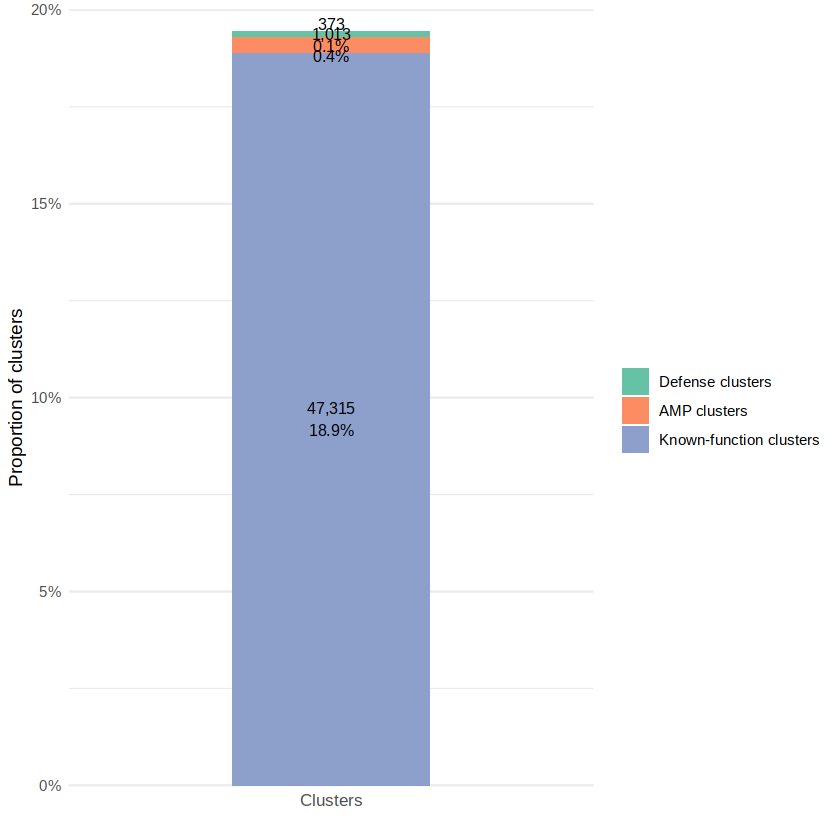

file saved to downstream_analysis/figures/f.rv.dark_cds_cluster_anno_basic_bar_26_06_08.pdf



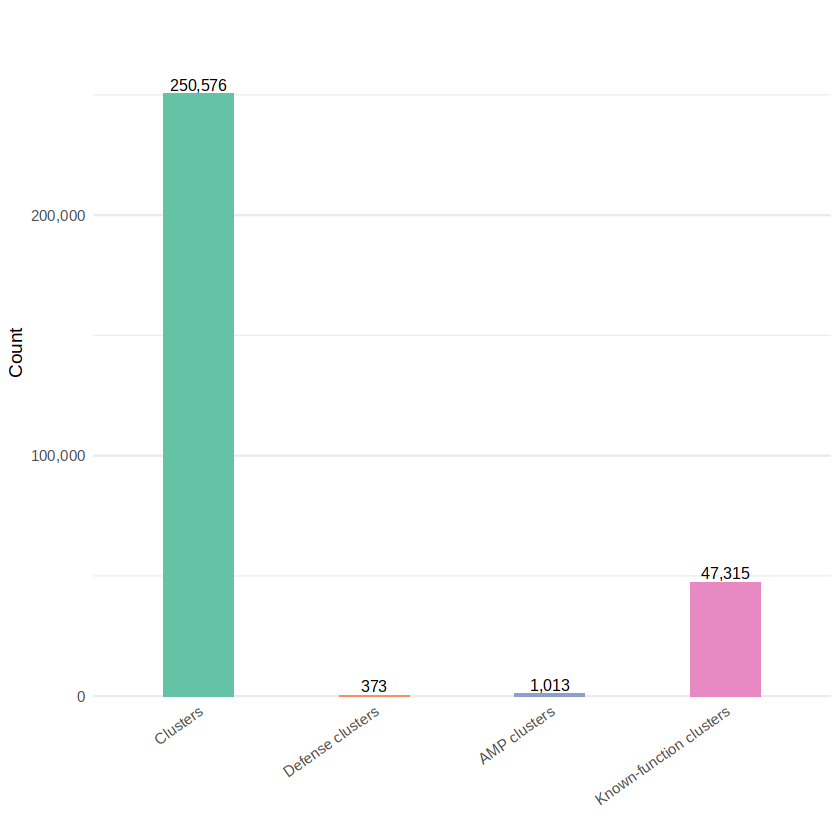

In [188]:

# ggexport(
#   p_overview_prop,
#   filename = "downstream_analysis/figures/f.rv.dark_cds_cluster_anno_basic_prop_bar_26_06_08.pdf",
#   width = 4.5,
#   height = 4
# )

overview_plot_df <- dark_overview %>%
  pivot_longer(everything(), names_to = "metric", values_to = "n") %>%
  mutate(
    metric = recode(
      metric,
      dark_cds_n = "Dark CDS",
      cluster_n = "Clusters",
      cell_n = "Cells",
      sample_n = "Samples",
      species_n = "Species",
      group_n = "Groups",
      defense_cluster_n = "Defense clusters",
      amp_cluster_n = "AMP clusters",
      known_function_cluster_n = "Known-function clusters"
    ),
    metric = factor(metric, levels = metric)
  )

p_overview <- ggplot(overview_plot_df[overview_plot_df$metric %in% 
                                      c("Clusters","Defense clusters","AMP clusters","Known-function clusters"),], 
                     aes(x = metric, y = n, fill = metric)) +
  geom_col(width = 0.4) +
  geom_text(aes(label = comma(n)), vjust = -0.25, size = 3.2) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.14))) +
  scale_fill_brewer(palette = "Set2") +
  labs(x = "", y = "Count") +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(angle = 35, hjust = 1)
  )

p_overview
ggexport(p_overview,filename = "downstream_analysis/figures/f.rv.dark_cds_cluster_anno_basic_bar_26_06_08.pdf",width = 4.5,height = 4)

In [198]:
colnames(cltdf2_anno)

[1] "cluster_name"             "cluster_id"              
 [3] "contig_id"                "cell_id"                 
 [5] "sample.x"                 "group"                   
 [7] "condition2"               "species"                 
 [9] "order"                    "class"                   
[11] "hypothetical_rate"        "cellnum"                 
[13] "total_species_cds"        "sprot_hit"               
[15] "pident"                   "aln_len"                 
[17] "evalue"                   "bitscore"                
[19] "sprot_description"        "defense_sys_id"          
[21] "defense_type"             "defense_subtype"         
[23] "defense_activity"         "defense_gene_name"       
[25] "defense_hit_score"        "defense_hit_i_eval"      
[27] "is_ampir_amp"             "has_pfam_hit"            
[29] "best_pfam_name"           "best_pfam_description"   
[31] "best_pfam_function_class" "pfam_names"              
[33] "pfam_function_classes"    "has_known_function"      
[35] "dark_level"               "has_defense_hit"         
[37] "amp_length_aa"            "sample.y"                
[39] "sample_name"

In [192]:
library(dplyr)
library(ggplot2)
library(scales)
library(ggpubr)

# 1. 先整理到 cluster level
cluster_class_df <- cltdf2_anno %>%
  group_by(cluster_name) %>%
  summarise(
    has_defense_hit = any(has_defense_hit, na.rm = TRUE),
    is_ampir_amp = any(is_ampir_amp, na.rm = TRUE),
    has_known_function = any(has_known_function, na.rm = TRUE)
  ) %>%
  mutate(
    cluster_class = case_when(
      has_defense_hit ~ "Defense-related",
      is_ampir_amp ~ "AMP",
      has_known_function ~ "Known-function",
      TRUE ~ "Unknown"
    ),
    cluster_class = factor(
      cluster_class,
      levels = c("Unknown", "Known-function", "AMP", "Defense-related")
    )
  )

# 2. 统计每一类 cluster 数量和比例
cluster_class_summary <- cluster_class_df %>%
  count(cluster_class, name = "cluster_n") %>%
  mutate(
    prop = cluster_n / sum(cluster_n),
    label = paste0(comma(cluster_n), "\n", percent(prop, accuracy = 0.1))
  )

cluster_class_summary

cluster_class,cluster_n,prop,label
<fct>,<int>,<dbl>,<chr>
Unknown,202012,0.806190537,"202,012 80.6%"
Known-function,47178,0.188278207,"47,178 18.8%"
AMP,1013,0.004042686,"1,013 0.4%"
Defense-related,373,0.001488570,373 0.1%


file saved to downstream_analysis/figures/f.rv.dark_cds_cluster_class_prop_bar_26_06_22.pdf



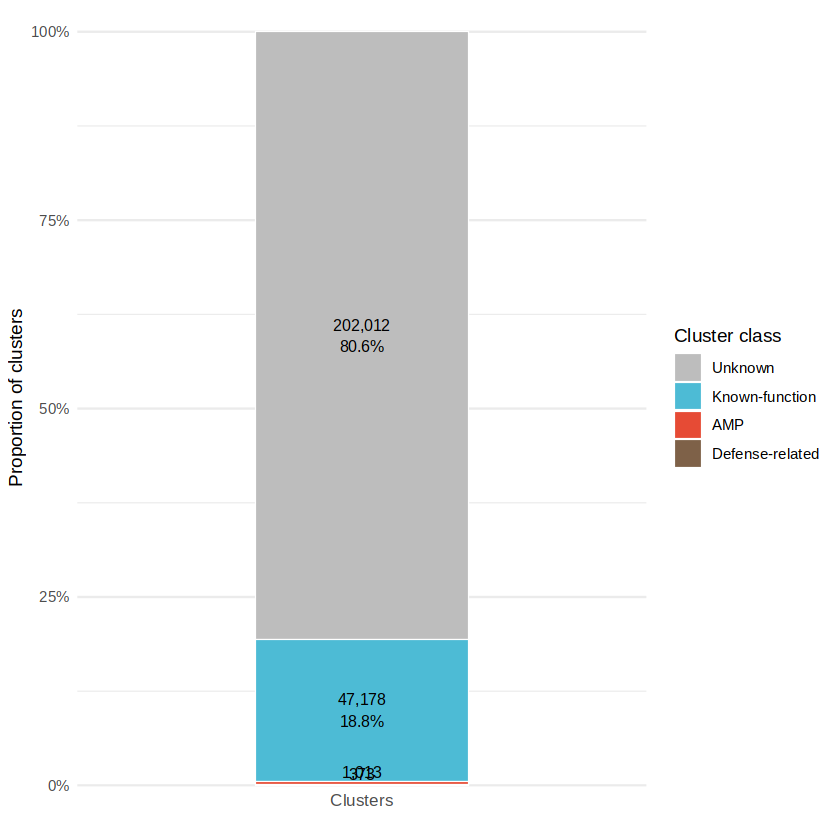

In [196]:
cluster_class_cols <- c(
  "Unknown" = "#BDBDBD",
  "Known-function" = "#4DBBD5",
  "AMP" = "#E64B35",
  "Defense-related" = "#7E6148"
)

p_cluster_class_prop <- ggplot(
  cluster_class_summary,
  aes(x = "Clusters", y = prop, fill = cluster_class)
) +
  geom_col(width = 0.45, color = "white", linewidth = 0.25) +
  geom_text(
    aes(label = label),
    position = position_stack(vjust = 0.5),
    size = 3.2
  ) +
  scale_y_continuous(
    labels = percent_format(accuracy = 1),
    expand = expansion(mult = c(0, 0.03))
  ) +
  scale_fill_manual(values = cluster_class_cols) +
  labs(
    x = "",
    y = "Proportion of clusters",
    fill = "Cluster class"
  ) +
  theme_minimal() +
  theme(
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(size = 10),
    legend.position = "right"
  )

p_cluster_class_prop

ggexport(
  p_cluster_class_prop,
  filename = "downstream_analysis/figures/f.rv.dark_cds_cluster_class_prop_bar_26_06_22.pdf",
  width = 4,
  height = 4
)

In [3]:
library(dplyr)
library(ggplot2)
library(scales)
library(ggpubr)

# -----------------------------
# 1. 整理到 cluster level
# -----------------------------

cluster_class_df <- cltdf2_anno %>%
  group_by(cluster_name) %>%
  summarise(
    has_known_function = any(has_known_function, na.rm = TRUE),
    has_defense_hit = any(has_defense_hit, na.rm = TRUE),
    is_ampir_amp = any(is_ampir_amp, na.rm = TRUE),
    has_pfam_hit = any(has_pfam_hit, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    major_class = case_when(
      has_known_function ~ "Known-function clusters",
      TRUE ~ "Functionally uncharacterized clusters"
    ),
    
    # 只在 unknown-function clusters 里继续细分
    subclass = case_when(
      has_known_function ~ "Known-function clusters",
      !has_known_function & has_defense_hit ~ "Defense-related candidates",
      !has_known_function & is_ampir_amp ~ "AMP-like candidates",
      !has_known_function & has_pfam_hit ~ "Pfam-domain candidates",
      TRUE ~ "Unannotated clusters"
    ),
    
    subclass = factor(
      subclass,
      levels = c(
        "Known-function clusters",
        "Defense-related candidates",
        "AMP-like candidates",
        "Pfam-domain candidates",
        "Unannotated clusters"
      )
    )
  )



Warning message:
“package ‘scales’ was built under R version 4.3.3”

Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal




In [4]:
head(cluster_class_df)

cluster_name,has_known_function,has_defense_hit,is_ampir_amp,has_pfam_hit,major_class,subclass
<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<chr>,<fct>
cl10,FALSE,FALSE,FALSE,TRUE,Functionally uncharacterized clusters,Pfam-domain candidates
cl1000004,FALSE,FALSE,FALSE,FALSE,Functionally uncharacterized clusters,Unannotated clusters
cl1000008,FALSE,FALSE,FALSE,TRUE,Functionally uncharacterized clusters,Pfam-domain candidates
cl1000010,FALSE,FALSE,FALSE,FALSE,Functionally uncharacterized clusters,Unannotated clusters
cl1000031,FALSE,FALSE,FALSE,FALSE,Functionally uncharacterized clusters,Unannotated clusters
cl1000039,FALSE,FALSE,FALSE,TRUE,Functionally uncharacterized clusters,Pfam-domain candidates


In [5]:
library(dplyr)
library(ggplot2)
library(scales)
library(ggpubr)

# -----------------------------
# 1. 第一层：All clusters 中 Known vs Unknown
# -----------------------------

major_summary <- cluster_class_df %>%
  count(major_class, name = "cluster_n") %>%
  mutate(
    bar = "All clusters",
    annotation_class = major_class,
    prop = cluster_n / sum(cluster_n)
  ) %>%
  select(bar, annotation_class, cluster_n, prop)

# -----------------------------
# 2. 第二层：Unknown-function clusters 内部细分
# -----------------------------

unknown_sub_summary <- cluster_class_df %>%
  filter(!has_known_function) %>%
  count(subclass, name = "cluster_n") %>%
  mutate(
    bar = "Functionally\nuncharacterized clusters",
    annotation_class = as.character(subclass),
    prop = cluster_n / sum(cluster_n)
  ) %>%
  select(bar, annotation_class, cluster_n, prop)

# -----------------------------
# 3. 合并作图数据
# -----------------------------

plot_df <- bind_rows(
  major_summary,
  unknown_sub_summary
) %>%
  mutate(
    label = paste0(comma(cluster_n), "\n", percent(prop, accuracy = 0.1)),
    label_show = ifelse(prop >= 0.03, label, ""),
    bar = factor(
      bar,
      levels = c("All clusters", "Functionally\nuncharacterized clusters")
    ),
    annotation_class = factor(
      annotation_class,
      levels = c(
        "Known-function clusters",
        "Functionally uncharacterized clusters",
        "Defense-related candidates",
        "AMP-like candidates",
        "Pfam-domain candidates",
        "Unannotated clusters"
      )
    )
  )

plot_df

bar,annotation_class,cluster_n,prop,label,label_show
<fct>,<fct>,<int>,<dbl>,<chr>,<chr>
All clusters,Functionally uncharacterized clusters,203261,0.811175053,"203,261 81.1%","203,261 81.1%"
All clusters,Known-function clusters,47315,0.188824947,"47,315 18.9%","47,315 18.9%"
Functionally uncharacterized clusters,Defense-related candidates,312,0.001534972,312 0.2%,
Functionally uncharacterized clusters,AMP-like candidates,937,0.004609837,937 0.5%,
Functionally uncharacterized clusters,Pfam-domain candidates,92391,0.454543666,"92,391 45.5%","92,391 45.5%"
Functionally uncharacterized clusters,Unannotated clusters,109621,0.539311526,"109,621 53.9%","109,621 53.9%"


file saved to downstream_analysis/figures/f.rv.dark_cds_cluster_annotation_containment_bar_26_06_28.pdf



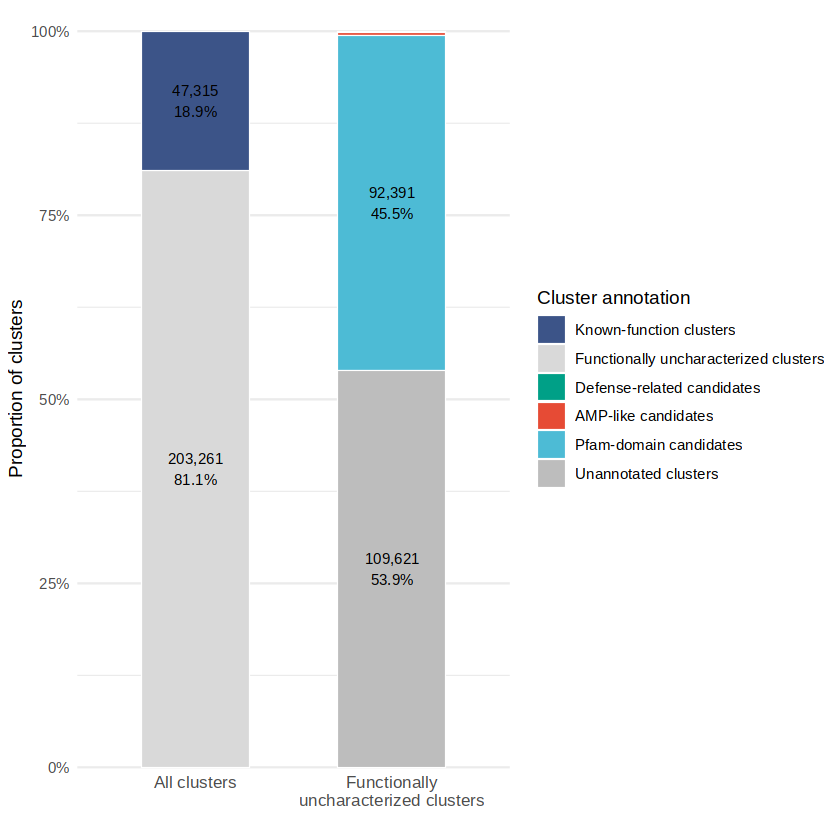

In [207]:
containment_cols <- c(
  "Known-function clusters" = "#3C5488",
  "Functionally uncharacterized clusters" = "#D9D9D9",
  "Defense-related candidates" = "#00A087",
  "AMP-like candidates" = "#E64B35",
  "Pfam-domain candidates" = "#4DBBD5",
  "Unannotated clusters" = "#BDBDBD"
)

p_cluster_containment <- ggplot(
  plot_df,
  aes(x = bar, y = prop, fill = annotation_class)
) +
  geom_col(width = 0.55, color = "white", linewidth = 0.25) +
  geom_text(
    aes(label = label_show),
    position = position_stack(vjust = 0.5),
    size = 3.1
  ) +
  scale_y_continuous(
    labels = percent_format(accuracy = 1),
    expand = expansion(mult = c(0, 0.03))
  ) +
  scale_fill_manual(values = containment_cols, drop = FALSE) +
  labs(
    x = "",
    y = "Proportion of clusters",
    fill = "Cluster annotation"
  ) +
  theme_minimal() +
  theme(
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(size = 10),
    legend.position = "right"
  )

p_cluster_containment

ggexport(
  p_cluster_containment,
  filename = "downstream_analysis/figures/f.rv.dark_cds_cluster_annotation_containment_bar_26_06_28.pdf",
  width = 6.2,
  height = 4
)

In [11]:
# head(plot_df)
head(plot_df)

bar,annotation_class,cluster_n,prop,label,label_show
<fct>,<fct>,<int>,<dbl>,<chr>,<chr>
All clusters,Functionally uncharacterized clusters,203261,0.811175053,"203,261 81.1%","203,261 81.1%"
All clusters,Known-function clusters,47315,0.188824947,"47,315 18.9%","47,315 18.9%"
Functionally uncharacterized clusters,Defense-related candidates,312,0.001534972,312 0.2%,
Functionally uncharacterized clusters,AMP-like candidates,937,0.004609837,937 0.5%,
Functionally uncharacterized clusters,Pfam-domain candidates,92391,0.454543666,"92,391 45.5%","92,391 45.5%"
Functionally uncharacterized clusters,Unannotated clusters,109621,0.539311526,"109,621 53.9%","109,621 53.9%"


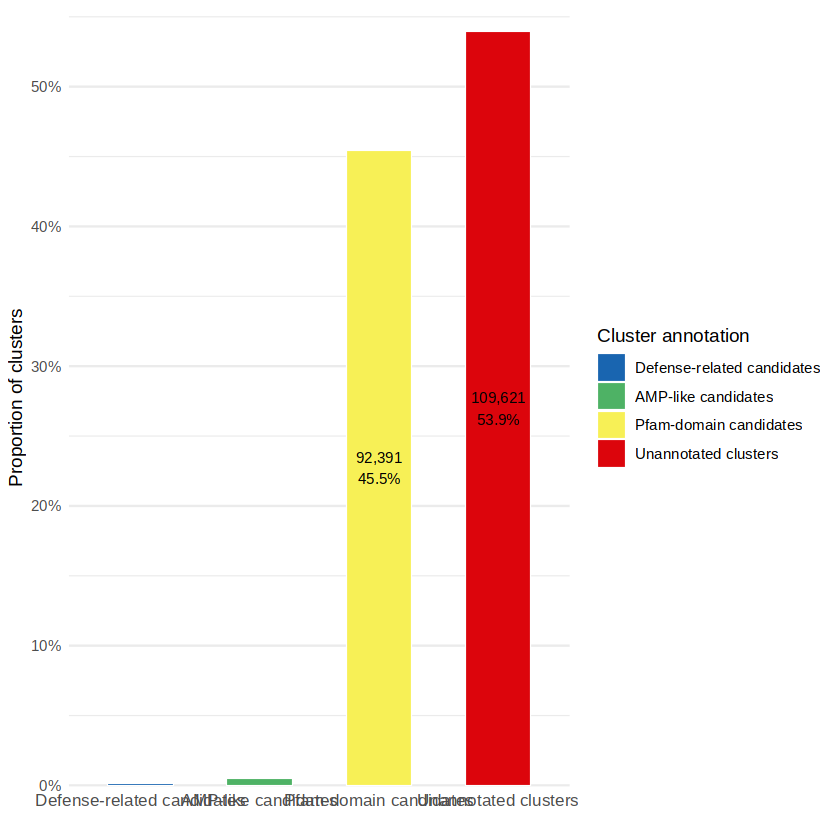

In [10]:
plot_df2 = plot_df[as.character(plot_df$bar) == "Functionally\nuncharacterized clusters",]
p_cluster_containment <- ggplot(
  plot_df2,
  aes(x = annotation_class, y = prop, fill = annotation_class)
) +
  geom_col(width = 0.55, color = "white", linewidth = 0.25) +
  geom_text(
    aes(label = label_show),
    position = position_stack(vjust = 0.5),
    size = 3.1
  ) +
  scale_y_continuous(
    labels = percent_format(accuracy = 1),
    expand = expansion(mult = c(0, 0.03))
  ) +
  scale_fill_discreterainbow() +
  # scale_fill_manual(values = containment_cols, drop = FALSE) +
  labs(
    x = "",
    y = "Proportion of clusters",
    fill = "Cluster annotation"
  ) +
  theme_minimal() +
  theme(
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(size = 10),
    legend.position = "right"
  )

p_cluster_containment

In [13]:
install.packages("ggbreak")

also installing the dependencies ‘ggfun’, ‘aplot’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



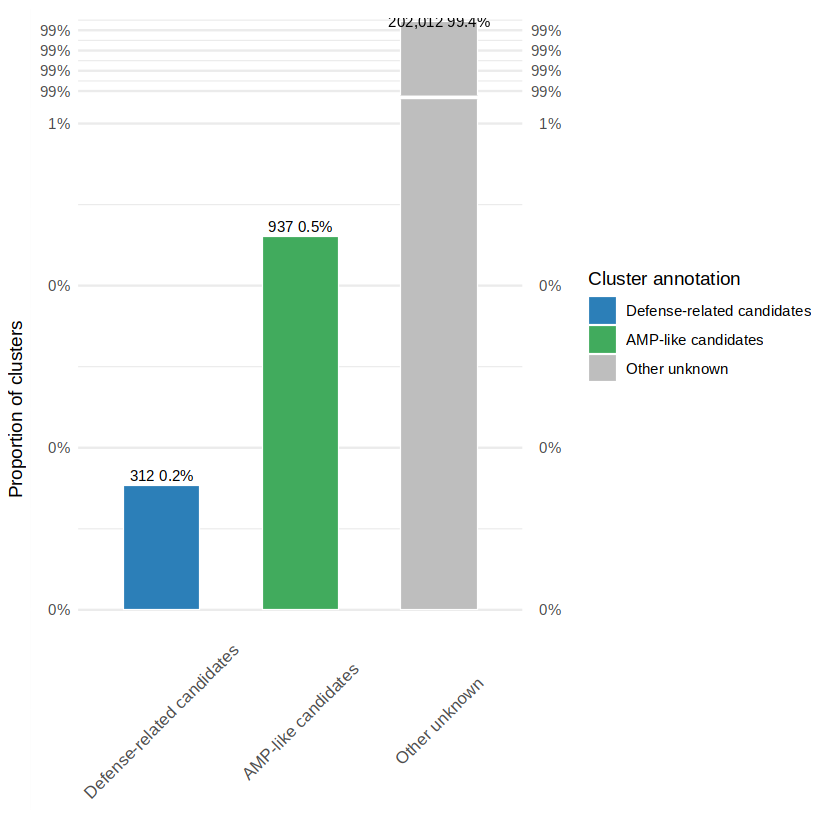

In [30]:
library(dplyr)
library(ggplot2)
library(scales)
library(ggbreak)

plot_df2 <- plot_df %>%
  filter(as.character(bar) == "Functionally\nuncharacterized clusters") %>%
  mutate(
    annotation_class = case_when(
      annotation_class %in% c("Pfam-domain candidates", "Unannotated clusters") ~ "Other unknown",
      TRUE ~ as.character(annotation_class)
    )
  ) %>%
  group_by(annotation_class) %>%
  summarise(cluster_n = sum(cluster_n), .groups = "drop") %>%
  mutate(
    prop = cluster_n / sum(cluster_n),
    label = comma(cluster_n),
    label_show = paste0(label, " ", percent(prop, accuracy = 0.1)),
    annotation_class = factor(
      annotation_class,
      levels = c(
        "Defense-related candidates",
        "AMP-like candidates",
        "Other unknown"
      )
    )
  )

p_cluster_containment <- ggplot(
  plot_df2,
  aes(x = annotation_class, y = prop, fill = annotation_class)
) +
  geom_col(width = 0.55, color = "white", linewidth = 0.25) +
  geom_text(
    aes(label = label_show),
    vjust = c(-0.4, -0.4, 0.5),
    size = 3.1
  ) +
  scale_y_continuous(
    labels = percent_format(accuracy = 1),
    expand = expansion(mult = c(0, 0.0003))
  ) +
  ggbreak::scale_y_break(c(0.006, 0.993)) +
  scale_fill_manual(
    values = c(
      "Defense-related candidates" = "#2C7FB8",
      "AMP-like candidates" = "#41AB5D",
      "Other unknown" = "grey"
    )
  ) +
  labs(
    x = "",
    y = "Proportion of clusters",
    fill = "Cluster annotation"
  ) +
  theme_minimal() +
  theme(
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(size = 10,angle = 45,vjust = 0.5),
    legend.position = "right"
  )

p_cluster_containment

In [33]:
ggexport(
  p_cluster_containment,
  filename = "downstream_analysis/figures/f.rv.dark_cds_cluster_annotation_containment_bar_26_06_29.pdf",
  width = 6,
  height = 5
)

file saved to downstream_analysis/figures/f.rv.dark_cds_cluster_annotation_containment_bar_26_06_29.pdf



file saved to downstream_analysis/figures/f.rv.dark_cds_pfam_anno_basic_stat_bar_26_06_28.pdf



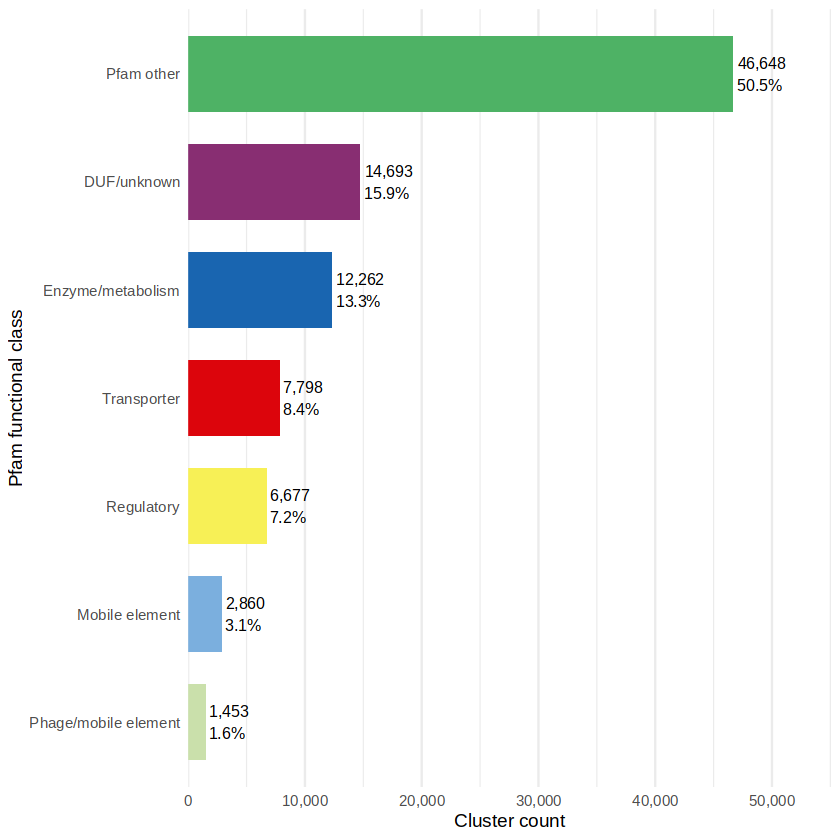

In [213]:
library(dplyr)
library(ggplot2)
library(scales)
library(ggpubr)
library(forcats)

# -----------------------------
# 1. cluster-level summary
# -----------------------------

pfam_priority <- c(
  "Phage/mobile element",
  "Mobile element",
  "Transporter",
  "Enzyme/metabolism",
  "Regulatory",
  "DUF/unknown"
)

cluster_summary <- cltdf2_anno %>%
  group_by(cluster_name) %>%
  summarise(
    has_known_function = any(has_known_function, na.rm = TRUE),
    has_defense_hit = any(has_defense_hit, na.rm = TRUE),
    is_ampir_amp = any(is_ampir_amp, na.rm = TRUE),
    has_pfam_hit = any(has_pfam_hit, na.rm = TRUE),
    
    # 每个 cluster 选择一个代表性 Pfam functional class
    best_pfam_function_class = {
      x <- unique(na.omit(best_pfam_function_class[has_pfam_hit]))
      x <- pfam_priority[pfam_priority %in% x]
      ifelse(length(x) > 0, x[1], NA_character_)
    },
    
    .groups = "drop"
  ) %>%
  mutate(
    major_class = case_when(
      has_known_function ~ "Known-function clusters",
      TRUE ~ "Functionally uncharacterized clusters"
    ),
    
    function_class = case_when(
      has_known_function ~ "Known-function clusters",
      !has_known_function & has_defense_hit ~ "Defense-related candidates",
      !has_known_function & is_ampir_amp ~ "AMP-like candidates",
      !has_known_function & has_pfam_hit ~ "Pfam-domain candidates",
      TRUE ~ "Unannotated clusters"
    ),
    
    function_class = factor(
      function_class,
      levels = c(
        "Known-function clusters",
        "Defense-related candidates",
        "AMP-like candidates",
        "Pfam-domain candidates",
        "Unannotated clusters"
      )
    )
  )

pfam_function_summary <- cluster_summary %>%
  filter(
    !has_known_function,
    !has_defense_hit,
    !is_ampir_amp,
    has_pfam_hit
  ) %>%
  mutate(
    best_pfam_function_class = ifelse(
      is.na(best_pfam_function_class) | best_pfam_function_class == "",
      "Pfam other",
      best_pfam_function_class
    )
  ) %>%
  count(best_pfam_function_class, name = "cluster_n") %>%
  mutate(
    freq = cluster_n / sum(cluster_n),
    label = paste0(comma(cluster_n), "\n", percent(freq, accuracy = 0.1))
  ) %>%
  arrange(desc(cluster_n))

pfam_cols <- c(
  "Phage/mobile element" = "#8DD3C7",
  "Mobile element" = "#FFFFB3",
  "Transporter" = "#BEBADA",
  "Enzyme/metabolism" = "#FB8072",
  "Regulatory" = "#80B1D3",
  "DUF/unknown" = "#FDB462",
  "Pfam other" = "#B3B3B3"
)

p_pfam_function_class <- pfam_function_summary %>%
  ggplot(aes(
    x = fct_reorder(best_pfam_function_class, cluster_n),
    y = cluster_n,
    fill = best_pfam_function_class
  )) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = label),
    hjust = -0.1,
    size = 3.2
  ) +
  coord_flip() +
  scale_y_continuous(
    labels = comma,
    expand = expansion(mult = c(0, 0.18))
  ) +
  scale_fill_discreterainbow() +
  labs(
    x = "Pfam functional class",
    y = "Cluster count"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.major.y = element_blank()
  )

p_pfam_function_class

ggexport(
  p_pfam_function_class,
  filename = "downstream_analysis/figures/f.rv.dark_cds_pfam_anno_basic_stat_bar_26_06_28.pdf",
  width = 5.5,
  height = 5
)

In [210]:
defense_type_summary <- cltdf2_anno %>%
  group_by(cluster_name) %>%
  mutate(
    cluster_has_known_function = any(has_known_function, na.rm = TRUE),
    cluster_has_defense_hit = any(has_defense_hit, na.rm = TRUE)
  ) %>%
  ungroup() %>%
  filter(
    !cluster_has_known_function,
    cluster_has_defense_hit,
    has_defense_hit
  ) %>%
  distinct(cluster_name, defense_type, defense_subtype, defense_activity) %>%
  mutate(
    defense_type = ifelse(
      is.na(defense_type) | defense_type == "",
      "Unknown defense type",
      defense_type
    ),
    defense_subtype = ifelse(
      is.na(defense_subtype) | defense_subtype == "",
      "Unknown subtype",
      defense_subtype
    ),
    defense_activity = ifelse(
      is.na(defense_activity) | defense_activity == "",
      "Unknown activity",
      defense_activity
    )
  ) %>%
  count(defense_type, defense_subtype, defense_activity, name = "cluster_n") %>%
  arrange(desc(cluster_n))

file saved to downstream_analysis/figures/f.rv.dark_cds_defend_anno_basic_stat_bar_26_06_28.pdf



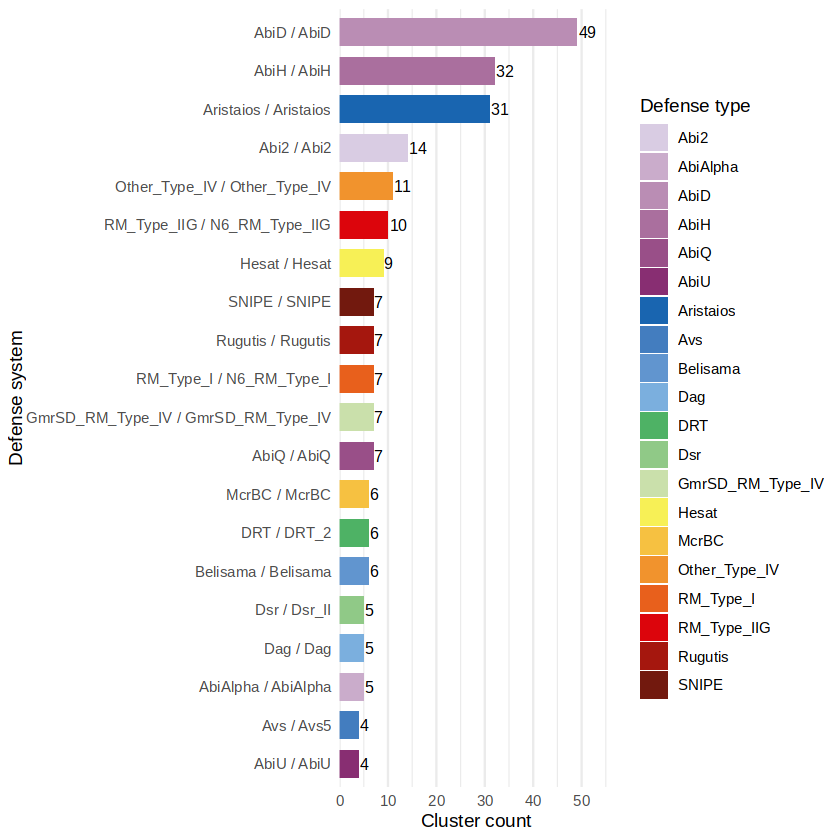

In [212]:
p_defense_type <- defense_type_summary %>%
  mutate(
    defense_label = paste(defense_type, defense_subtype, sep = " / "),
    defense_label = ifelse(
      nchar(defense_label) > 55,
      paste0(substr(defense_label, 1, 52), "..."),
      defense_label
    )
  ) %>%
  slice_head(n = 20) %>%
  ggplot(aes(
    x = fct_reorder(defense_label, cluster_n),
    y = cluster_n,
    fill = defense_type
  )) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = comma(cluster_n)),
    hjust = -0.1,
    size = 3.2
  ) +
  coord_flip() +
  scale_y_continuous(
    labels = comma,
    expand = expansion(mult = c(0, 0.15))
  ) +
  labs(
    x = "Defense system",
    y = "Cluster count",
    fill = "Defense type"
  ) +
  theme_minimal() +
scale_fill_discreterainbow() +
  theme(
    panel.grid.major.y = element_blank(),
    legend.position = "right"
  )

p_defense_type

ggexport(
  p_defense_type,
  filename = "downstream_analysis/figures/f.rv.dark_cds_defend_anno_basic_stat_bar_26_06_28.pdf",
  width = 6.5,
  height = 6
)

file saved to downstream_analysis/figures/f.rv.dark_cds_all_anno_basic_stat_bar_26_06_08.pdf



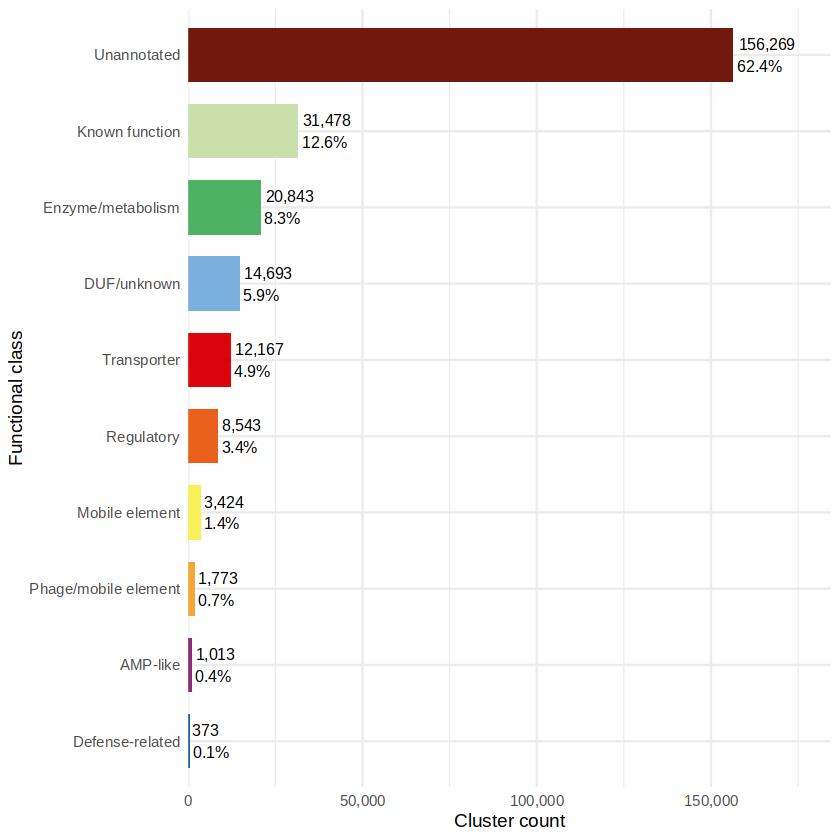

In [102]:
cluster_summary <- cluster_summary %>%
  mutate(
    function_class = case_when(
      is_ampir_amp ~ "AMP-like",
      has_defense_hit ~ "Defense-related",
      has_pfam_hit & best_pfam_function_class == "Phage/mobile element" ~ "Phage/mobile element",
      has_pfam_hit & best_pfam_function_class == "Mobile element" ~ "Mobile element",
      has_pfam_hit & best_pfam_function_class == "Transporter" ~ "Transporter",
      has_pfam_hit & best_pfam_function_class == "Enzyme/metabolism" ~ "Enzyme/metabolism",
      has_pfam_hit & best_pfam_function_class == "Regulatory" ~ "Regulatory",
      has_known_function ~ "Known function",
      has_pfam_hit & best_pfam_function_class == "DUF/unknown" ~ "DUF/unknown",
      TRUE ~ "Unannotated"
    )
  )
p_function_class_updated <- cluster_summary %>%
  count(function_class, name = "cluster_n") %>%
  mutate(freq = cluster_n / sum(cluster_n)) %>%
  ggplot(aes(x = fct_reorder(function_class, cluster_n), y = cluster_n, fill = function_class)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = paste0(comma(cluster_n), "\n", percent(freq, accuracy = 0.1))), hjust = -0.1, size = 3.2) +
  coord_flip() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.18))) +
  labs(
    x = "Functional class",
    y = "Cluster count"
  ) +
  theme_minimal() +
  scale_fill_discreterainbow() +
  theme(legend.position = "none")

p_function_class_updated
ggexport(p_function_class_updated,filename = "downstream_analysis/figures/f.rv.dark_cds_all_anno_basic_stat_bar_26_06_08.pdf",width = 5,height = 5)

### Pfam

file saved to downstream_analysis/figures/f.rv.dark_cds_pfam_anno_basic_stat_bar_26_06_08.pdf



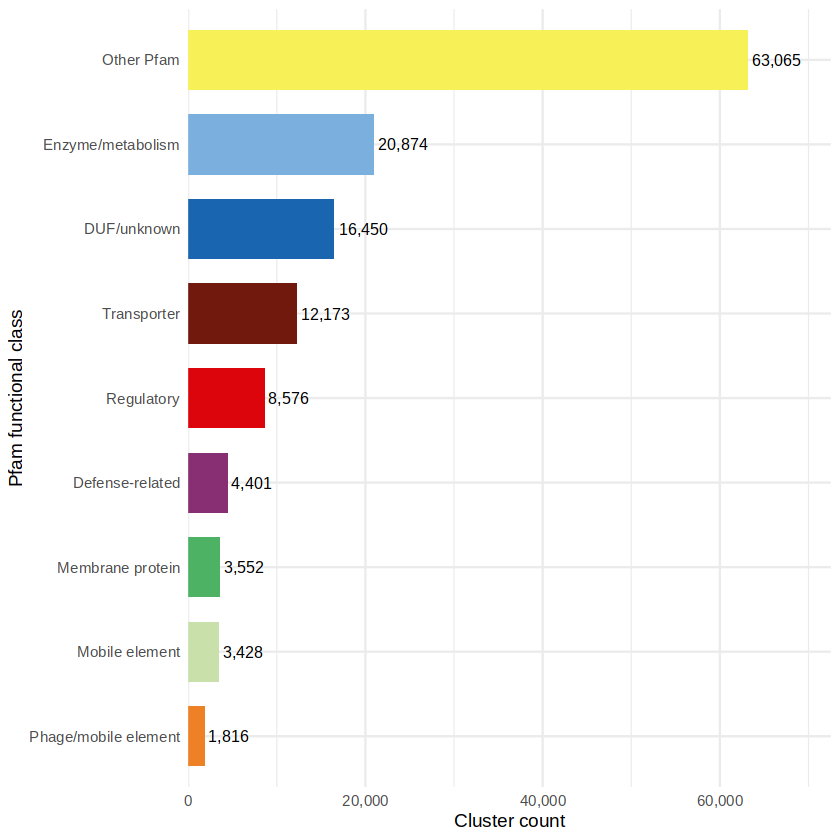

In [103]:
p_pfam_function_class <- cluster_summary %>%
  filter(has_pfam_hit) %>%
  count(best_pfam_function_class, name = "cluster_n") %>%
  mutate(freq = cluster_n / sum(cluster_n)) %>%
  ggplot(aes(x = fct_reorder(best_pfam_function_class, cluster_n), y = cluster_n, fill = best_pfam_function_class)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = comma(cluster_n)), hjust = -0.1, size = 3.3) +
  coord_flip() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.15))) +
  labs(
    x = "Pfam functional class",
    y = "Cluster count"
  ) +
  theme_minimal() +
  scale_fill_discreterainbow() +
  theme(legend.position = "none")

p_pfam_function_class
ggexport(p_pfam_function_class,filename = "downstream_analysis/figures/f.rv.dark_cds_pfam_anno_basic_stat_bar_26_06_08.pdf",width = 5,height = 5)

file saved to downstream_analysis/figures/f.rv.dark_cds_top_pfam_domains_bar_26_06_01.pdf



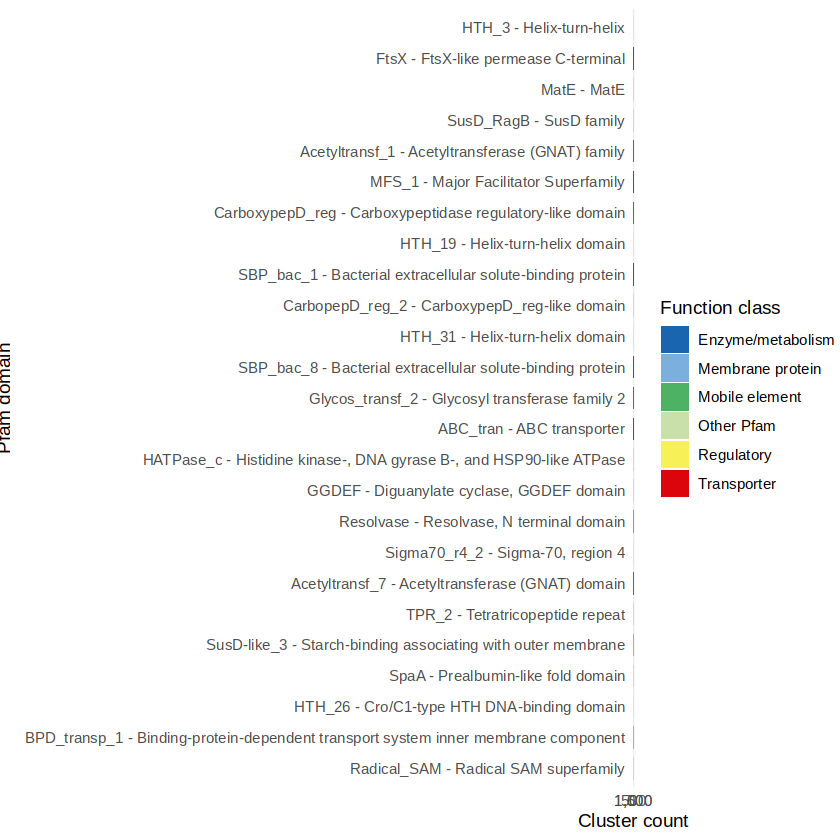

In [104]:
p_top_pfam_domains <- pfam_hits %>%
  distinct(cluster_id, pfam_name, pfam_description, pfam_function_class) %>%
  count(pfam_name, pfam_description, pfam_function_class, name = "cluster_n") %>%
  arrange(desc(cluster_n)) %>%
  slice_head(n = 25) %>%
  mutate(
    pfam_label = paste0(pfam_name, " - ", pfam_description)
  ) %>%
  ggplot(aes(x = fct_reorder(pfam_label, cluster_n), y = cluster_n, fill = pfam_function_class)) +
  geom_col(width = 0.7) +
  coord_flip() +
  scale_y_continuous(labels = comma) +
 scale_fill_discreterainbow() +
  labs(
    x = "Pfam domain",
    y = "Cluster count",
    fill = "Function class"
  ) +
  theme_minimal()

p_top_pfam_domains
ggexport(p_top_pfam_domains,filename = "downstream_analysis/figures/f.rv.dark_cds_top_pfam_domains_bar_26_06_01.pdf",width = 9,height = 6)


### DefenseFinder

In [84]:
colnames(cltdf2_anno)
table(cltdf2_anno$has_defense_hit)

[1] "cluster_name"             "cluster_id"              
 [3] "contig_id"                "cell_id"                 
 [5] "sample"                   "group"                   
 [7] "condition2"               "species"                 
 [9] "order"                    "class"                   
[11] "hypothetical_rate"        "cellnum"                 
[13] "total_species_cds"        "sprot_hit"               
[15] "pident"                   "aln_len"                 
[17] "evalue"                   "bitscore"                
[19] "sprot_description"        "defense_sys_id"          
[21] "is_ampir_amp"             "has_pfam_hit"            
[23] "best_pfam_name"           "best_pfam_description"   
[25] "best_pfam_function_class" "pfam_names"              
[27] "pfam_function_classes"    "has_known_function"      
[29] "dark_level"               "has_defense_hit"         
[31] "defense_type"             "defense_subtype"         
[33] "defense_activity"         "amp_length_aa"


   FALSE 
11150714 

file saved to downstream_analysis/figures/f.rv.dark_cds_defend_anno_basic_stat_bar_26_06_08.pdf



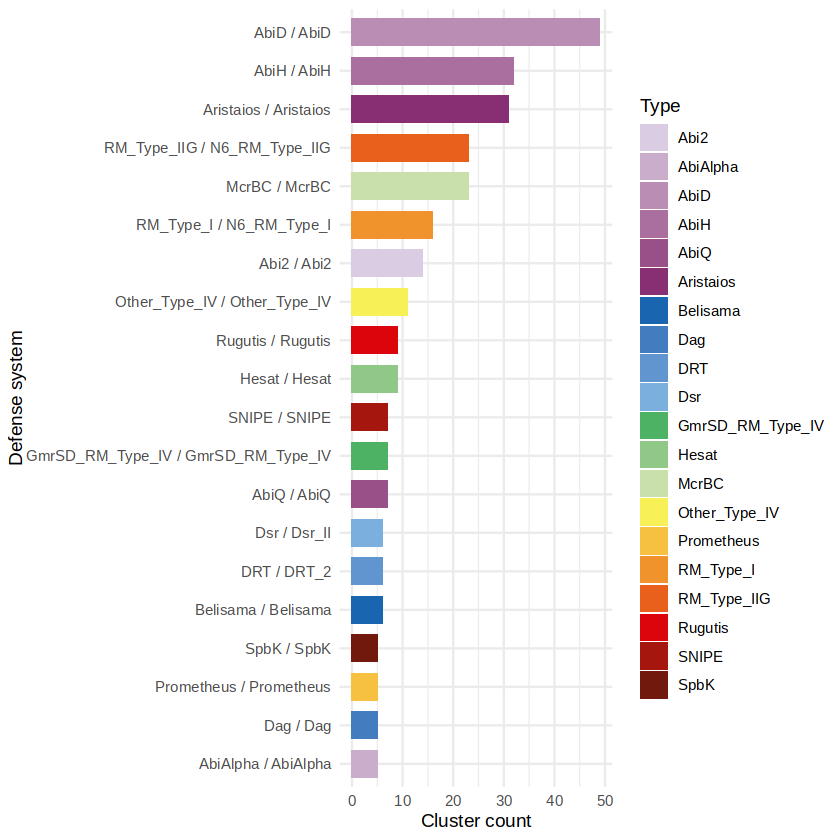

In [105]:
defense_type_summary <- cltdf2_anno %>%
  filter(has_defense_hit) %>%
  distinct(cluster_name, defense_type, defense_subtype, defense_activity) %>%
  count(defense_type, defense_subtype, defense_activity, name = "cluster_n") %>%
  arrange(desc(cluster_n))

# defense_type_summary

p_defense_type <- defense_type_summary %>%
  mutate(defense_label = paste(defense_type, defense_subtype, sep = " / ")) %>%
  slice_head(n = 20) %>%
  ggplot(aes(x = fct_reorder(defense_label, cluster_n), y = cluster_n, fill = defense_type)) +
  geom_col(width = 0.7) +
  coord_flip() +
  scale_y_continuous(labels = comma) +
  scale_fill_discreterainbow() +
  labs(x = "Defense system", y = "Cluster count", fill = "Type") +
  theme_minimal()

p_defense_type
ggexport(p_defense_type,filename = "downstream_analysis/figures/f.rv.dark_cds_defend_anno_basic_stat_bar_26_06_08.pdf",width = 6,height = 6)

###  species shared dark matter cluster

In [109]:
# colnames(cltdf2_anno)
table(cltdf2_anno$condition2)


    Pre    Post 
5015136 6135578 

In [108]:
library(dplyr)
library(tidyr)
library(purrr)
library(forcats)
library(ggplot2)
library(ggalluvial)
library(ggrepel)

shared_base_group <- cltdf2_anno %>%
  distinct(
    group,
    condition2,
    cluster_name,
    contig_id,
    species,
    has_known_function,
    has_defense_hit,
    is_ampir_amp,
    dark_level
  ) %>%
  filter(!is.na(species), species != "")

shared_base_group <- shared_base_group %>%
  mutate(
    function_class = case_when(
      is_ampir_amp ~ "AMP-like",
      has_defense_hit ~ "Defense-related",
      has_known_function ~ "Known function",
      TRUE ~ "Unannotated"
    )
  )

species_pairs_by_group <- shared_base_group %>%
  group_by(group, condition2, cluster_name, function_class) %>%
  summarise(
    species_list = list(sort(unique(species))),
    species_n = n_distinct(species),
    contig_n = n_distinct(contig_id),
    .groups = "drop"
  ) %>%
  filter(species_n >= 2) %>%
  mutate(
    species_pair = map(species_list, ~ combn(.x, 2, simplify = FALSE))
  ) %>%
  select(-species_list) %>%
  unnest(species_pair) %>%
  mutate(
    species_from = map_chr(species_pair, 1),
    species_to = map_chr(species_pair, 2)
  ) %>%
  select(-species_pair)

species_pair_edges_group <- species_pairs_by_group %>%
  group_by(group, condition2, species_from, species_to, function_class) %>%
  summarise(
    shared_cluster_n = n_distinct(cluster_name),
    shared_contig_n = sum(contig_n, na.rm = TRUE),
    cluster_list = paste(sort(unique(cluster_name)), collapse = "; "),
    .groups = "drop"
  ) %>%
  arrange(group, desc(shared_cluster_n))

plot_species_pair_edges_group <- species_pair_edges_group %>%
  group_by(group) %>%
  arrange(desc(shared_cluster_n), desc(shared_contig_n), .by_group = TRUE) %>%
  slice_head(n = 30) %>%
  ungroup() %>%
  mutate(
    species_from = fct_lump_n(species_from, n = 20, w = shared_cluster_n),
    species_to = fct_lump_n(species_to, n = 20, w = shared_cluster_n)
  )

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
file saved to downstream_analysis/figures/f.rv.dark_cds_dark_matter_species_diff_group_sankey_stat_bar_26_06_08.pdf



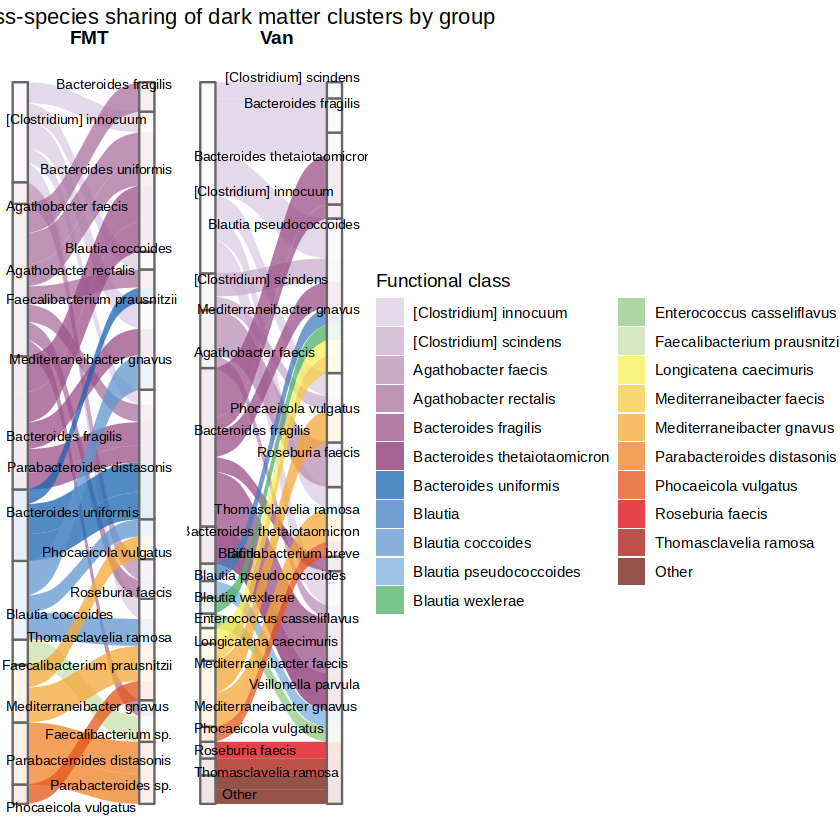

In [110]:
p_species_pair_group_alluvial <- ggplot(
  plot_species_pair_edges_group,
  aes(
    axis1 = species_from,
    axis2 = species_to,
    y = shared_cluster_n
  )
) +
  scale_x_discrete(
    limits = c("Species A", "Species B"),
    expand = c(0.08, 0.08)
  ) +
  geom_alluvium(
    aes(fill = species_from),
    width = 0.12,
    alpha = 0.75
  ) +
  geom_stratum(
    width = 0.12,
    alpha = 0.85,
    color = "grey40"
  ) +
  geom_text_repel(
    stat = "stratum",
    aes(label = after_stat(stratum)),
    force = 0.5,
    direction = "y",
    nudge_x = 0.25,
    segment.size = 0.3,
    size = 2.8,
    max.overlaps = 100
  ) +
  facet_wrap(~ group, scales = "free_y", ncol = 2) +
  scale_fill_discreterainbow() +
  labs(
    title = "Potential cross-species sharing of dark matter clusters by group",
    x = "",
    y = "Shared cluster count",
    fill = "Functional class"
  ) +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 13),
    strip.text = element_text(size = 11, face = "bold"),
    legend.position = "right"
  )

p_species_pair_group_alluvial
ggexport(p_species_pair_group_alluvial,filename = "downstream_analysis/figures/f.rv.dark_cds_dark_matter_species_diff_group_sankey_stat_bar_26_06_08.pdf",
         width = 10,height = 6)

In [111]:
library(dplyr)
library(tidyr)
library(purrr)
library(forcats)
library(ggplot2)
library(ggalluvial)
library(ggrepel)

## =========================
## 1. 整理 Pre / Post
## =========================

shared_base_prepost <- cltdf2_anno %>%
  mutate(
    condition2 = factor(condition2, levels = c("Pre", "Post")),
    function_class = case_when(
      is_ampir_amp ~ "AMP-like",
      has_defense_hit ~ "Defense-related",
      has_known_function ~ "Known function",
      TRUE ~ "Unannotated"
    )
  ) %>%
  distinct(
    group,
    condition2,
    cluster_name,
    contig_id,
    species,
    function_class
  ) %>%
  filter(
    !is.na(group),
    !is.na(condition2),
    !is.na(cluster_name),
    !is.na(species),
    species != ""
  )

In [112]:
## =========================
## 2. 构建 Pre species -> Post species
## =========================

cluster_prepost_species <- shared_base_prepost %>%
  group_by(group, cluster_name, function_class, condition2) %>%
  summarise(
    species_list = list(sort(unique(species))),
    contig_n = n_distinct(contig_id),
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = condition2,
    values_from = c(species_list, contig_n)
  ) %>%
  filter(
    !map_lgl(species_list_Pre, is.null),
    !map_lgl(species_list_Post, is.null)
  )

In [113]:
prepost_species_edges <- cluster_prepost_species %>%
  mutate(
    species_pair = map2(
      species_list_Pre,
      species_list_Post,
      ~ expand.grid(
        species_pre = .x,
        species_post = .y,
        stringsAsFactors = FALSE
      )
    )
  ) %>%
  select(group, cluster_name, function_class, contig_n_Pre, contig_n_Post, species_pair) %>%
  unnest(species_pair) %>%
  mutate(
    contig_n = coalesce(contig_n_Pre, 0L) + coalesce(contig_n_Post, 0L)
  )

In [114]:
species_prepost_edges_group <- prepost_species_edges %>%
  group_by(group, species_pre, species_post, function_class) %>%
  summarise(
    shared_cluster_n = n_distinct(cluster_name),
    shared_contig_n = sum(contig_n, na.rm = TRUE),
    cluster_list = paste(sort(unique(cluster_name)), collapse = "; "),
    .groups = "drop"
  ) %>%
  arrange(group, desc(shared_cluster_n))
plot_species_prepost_edges_group <- species_prepost_edges_group %>%
  group_by(group) %>%
  arrange(desc(shared_cluster_n), desc(shared_contig_n), .by_group = TRUE) %>%
  slice_head(n = 30) %>%
  ungroup() %>%
  mutate(
    species_pre = fct_lump_n(species_pre, n = 20, w = shared_cluster_n),
    species_post = fct_lump_n(species_post, n = 20, w = shared_cluster_n)
  )

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
file saved to downstream_analysis/figures/f.rv.dark_cds_dark_matter_prepost_species_diff_group_sankey_stat_bar_26_06_08.pdf



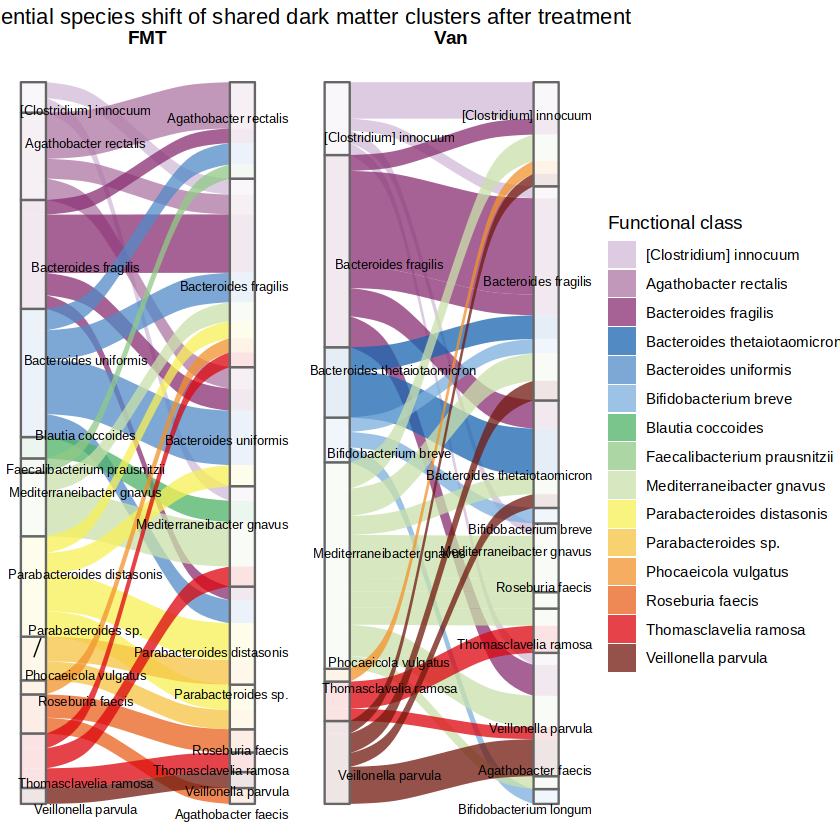

In [115]:
p_species_prepost_group_alluvial <- ggplot(
  plot_species_prepost_edges_group,
  aes(
    axis1 = species_pre,
    axis2 = species_post,
    y = shared_cluster_n
  )
) +
  scale_x_discrete(
    limits = c("Pre-treatment species", "Post-treatment species"),
    expand = c(0.08, 0.08)
  ) +
  geom_alluvium(
    aes(fill = species_pre),
    width = 0.12,
    alpha = 0.75
  ) +
  geom_stratum(
    width = 0.12,
    alpha = 0.85,
    color = "grey40"
  ) +
  geom_text_repel(
    stat = "stratum",
    aes(label = after_stat(stratum)),
    force = 0.5,
    direction = "y",
    nudge_x = 0.25,
    segment.size = 0.3,
    size = 2.6,
    max.overlaps = 100
  ) +
  facet_wrap(~ group, scales = "free_y", ncol = 2) +
  scale_fill_discreterainbow() +
  # scale_fill_manual(
  #   values = c(
  #     "AMP-like" = "#E15759",
  #     "Defense-related" = "#4E79A7",
  #     "Known function" = "#59A14F",
  #     "Unannotated" = "grey80"
  #   )
  # ) +
  labs(
    title = "Potential species shift of shared dark matter clusters after treatment",
    x = "",
    y = "Shared cluster count",
    fill = "Functional class"
  ) +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 13),
    strip.text = element_text(size = 11, face = "bold"),
    legend.position = "right"
  )

p_species_prepost_group_alluvial
ggexport(p_species_prepost_group_alluvial,filename = "downstream_analysis/figures/f.rv.dark_cds_dark_matter_prepost_species_diff_group_sankey_stat_bar_26_06_08.pdf",
         width = 10,height = 6)

In [116]:
library(dplyr)
library(stringr)
library(tidyr)
library(purrr)
library(ggplot2)
library(scales)

## =========================
## 1. 定义转移元件关键词
## =========================

mobile_keyword <- regex(
  "integrase|recombinase|transposase|resolvase|phage|viral|virus|plasmid|conjug|terminase|capsid|tail|portal|holin|mobile|insertion sequence",
  ignore_case = TRUE
)

defense_keyword <- regex(
  "defense|restriction|methyltransferase|cas|crispr|abi|toxin|antitoxin|mcrbc|rm_type",
  ignore_case = TRUE
)

In [117]:
cluster_mobile_anno <- cltdf2_anno %>%
  group_by(cluster_name) %>%
  summarise(
    has_known_function = any(has_known_function, na.rm = TRUE),
    has_defense_hit = any(has_defense_hit, na.rm = TRUE),
    is_ampir_amp = any(is_ampir_amp, na.rm = TRUE),

    sprot_text = paste(unique(na.omit(sprot_description)), collapse = "; "),
    pfam_name_text = paste(unique(na.omit(best_pfam_name)), collapse = "; "),
    pfam_desc_text = paste(unique(na.omit(best_pfam_description)), collapse = "; "),
    pfam_class_text = paste(unique(na.omit(best_pfam_function_class)), collapse = "; "),
    defense_type_text = paste(unique(na.omit(defense_type)), collapse = "; "),
    defense_subtype_text = paste(unique(na.omit(defense_subtype)), collapse = "; "),
    defense_activity_text = paste(unique(na.omit(defense_activity)), collapse = "; "),

    cds_n = n_distinct(contig_id),
    cell_n = n_distinct(cell_id),
    sample_n = n_distinct(sample),
    species_n = n_distinct(species),

    .groups = "drop"
  ) %>%
  mutate(
    anno_text = paste(
      sprot_text,
      pfam_name_text,
      pfam_desc_text,
      pfam_class_text,
      defense_type_text,
      defense_subtype_text,
      defense_activity_text,
      sep = "; "
    ),

    is_mobile_annotated = str_detect(anno_text, mobile_keyword) |
      pfam_class_text %in% c("Mobile element", "Phage/mobile element"),

    is_defense_annotated = has_defense_hit |
      str_detect(anno_text, defense_keyword),

    mobile_or_defense = is_mobile_annotated | is_defense_annotated,

    mobile_label = case_when(
      str_detect(anno_text, regex("integrase", ignore_case = TRUE)) ~ "integrase",
      str_detect(anno_text, regex("recombinase|resolvase", ignore_case = TRUE)) ~ "recombinase/resolvase",
      str_detect(anno_text, regex("transposase|insertion sequence", ignore_case = TRUE)) ~ "transposase/IS",
      str_detect(anno_text, regex("phage|viral|virus|terminase|capsid|tail|portal|holin", ignore_case = TRUE)) ~ "phage-related",
      str_detect(anno_text, regex("plasmid|conjug", ignore_case = TRUE)) ~ "plasmid/conjugation",
      is_defense_annotated ~ "defense-related",
      TRUE ~ "other"
    )
  )

In [118]:
## =========================
## 2. 宿主变化表：species_pre != species_post
## =========================
host_shift_cluster_table <- prepost_species_edges %>%
  filter(species_pre != species_post) %>%
  left_join(cluster_mobile_anno, by = "cluster_name") %>%
  group_by(
    group,
    cluster_name,
    species_pre,
    species_post
  ) %>%
  summarise(
    function_class = first(function_class),
    mobile_label = first(mobile_label),
    is_mobile_annotated = first(is_mobile_annotated),
    is_defense_annotated = first(is_defense_annotated),
    mobile_or_defense = first(mobile_or_defense),

    cds_n = first(cds_n),
    cell_n = first(cell_n),
    sample_n = first(sample_n),
    species_n = first(species_n),

    sprot_text = first(sprot_text),
    pfam_name_text = first(pfam_name_text),
    pfam_desc_text = first(pfam_desc_text),
    defense_type_text = first(defense_type_text),
    defense_subtype_text = first(defense_subtype_text),

    .groups = "drop"
  ) %>%
  arrange(group, desc(mobile_or_defense), mobile_label, desc(cell_n))

host_shift_cluster_table

group,cluster_name,species_pre,species_post,function_class,mobile_label,is_mobile_annotated,is_defense_annotated,mobile_or_defense,cds_n,cell_n,sample_n,species_n,sprot_text,pfam_name_text,pfam_desc_text,defense_type_text,defense_subtype_text
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
FMT,cl1513660,Agathobacter faecis,Acetatifactor acetigignens,Unannotated,defense-related,FALSE,TRUE,TRUE,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),,
FMT,cl1513660,Agathobacter faecis,Agathobacter rectalis,Unannotated,defense-related,FALSE,TRUE,TRUE,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),,
FMT,cl1513660,Agathobacter faecis,Amedibacterium intestinale,Unannotated,defense-related,FALSE,TRUE,TRUE,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),,
FMT,cl1513660,Agathobacter faecis,Bacteroides caccae,Unannotated,defense-related,FALSE,TRUE,TRUE,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),,
FMT,cl1513660,Agathobacter faecis,Bacteroides fragilis,Unannotated,defense-related,FALSE,TRUE,TRUE,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),,
FMT,cl1513660,Agathobacter faecis,Bacteroides uniformis,Unannotated,defense-related,FALSE,TRUE,TRUE,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),,
FMT,cl1513660,Agathobacter faecis,Blautia argi,Unannotated,defense-related,FALSE,TRUE,TRUE,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),,
FMT,cl1513660,Agathobacter faecis,Blautia coccoides,Unannotated,defense-related,FALSE,TRUE,TRUE,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),,
FMT,cl1513660,Agathobacter faecis,Blautia sp.,Unannotated,defense-related,FALSE,TRUE,TRUE,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),,


In [119]:
library(dplyr)
library(stringr)
library(tidyr)

## =========================
## 1. 给每个 cluster 生成功能分类
## =========================

cluster_function_anno <- cltdf2_anno %>%
  group_by(cluster_name) %>%
  summarise(
    has_known_function = any(has_known_function, na.rm = TRUE),
    has_defense_hit = any(has_defense_hit, na.rm = TRUE),
    is_ampir_amp = any(is_ampir_amp, na.rm = TRUE),

    sprot_text = paste(unique(na.omit(sprot_description)), collapse = "; "),
    pfam_name_text = paste(unique(na.omit(best_pfam_name)), collapse = "; "),
    pfam_desc_text = paste(unique(na.omit(best_pfam_description)), collapse = "; "),
    pfam_class_text = paste(unique(na.omit(best_pfam_function_class)), collapse = "; "),
    defense_type_text = paste(unique(na.omit(defense_type)), collapse = "; "),
    defense_subtype_text = paste(unique(na.omit(defense_subtype)), collapse = "; "),
    defense_activity_text = paste(unique(na.omit(defense_activity)), collapse = "; "),

    cds_n = n_distinct(contig_id),
    cell_n = n_distinct(cell_id),
    sample_n = n_distinct(sample),
    species_n = n_distinct(species),

    .groups = "drop"
  ) %>%
  mutate(
    anno_text = paste(
      sprot_text,
      pfam_name_text,
      pfam_desc_text,
      pfam_class_text,
      defense_type_text,
      defense_subtype_text,
      defense_activity_text,
      sep = "; "
    ),

    functional_class = case_when(
      str_detect(anno_text, regex("integrase|recombinase|resolvase|transposase|insertion sequence|mobile element", ignore_case = TRUE)) ~ "Mobile element",
      str_detect(anno_text, regex("phage|viral|virus|terminase|capsid|tail|portal|holin|prophage", ignore_case = TRUE)) ~ "Phage/mobile element",
      has_defense_hit | str_detect(anno_text, regex("defense|restriction|methyltransferase|cas|crispr|abi|toxin|antitoxin|mcrbc|rm_type", ignore_case = TRUE)) ~ "Defense-related",
      is_ampir_amp ~ "AMP-like",
      str_detect(anno_text, regex("transporter|permease|MFS|ABC|efflux|TonB|binding protein", ignore_case = TRUE)) ~ "Transporter",
      str_detect(anno_text, regex("hydrolase|transferase|reductase|oxidoreductase|dehydrogenase|peptidase|protease|enzyme|metabolism|glycosyl", ignore_case = TRUE)) ~ "Enzyme/metabolism",
      str_detect(anno_text, regex("HTH|helix-turn-helix|regulator|transcription|sigma|DNA-binding", ignore_case = TRUE)) ~ "Regulatory",
      str_detect(anno_text, regex("membrane|transmembrane|integral membrane", ignore_case = TRUE)) ~ "Membrane protein",
      str_detect(anno_text, regex("DUF|unknown function|hypothetical", ignore_case = TRUE)) ~ "DUF/unknown",
      has_known_function ~ "Other known function",
      TRUE ~ "Unannotated"
    )
  )

table(cluster_function_anno$functional_class, useNA = "ifany")


            AMP-like      Defense-related          DUF/unknown 
                 999                 6731                16026 
   Enzyme/metabolism     Membrane protein       Mobile element 
               22844                 3615                 5391 
Other known function Phage/mobile element           Regulatory 
               19319                  643                 8887 
         Transporter          Unannotated 
               15313               150808 

In [120]:
## =========================
## 2. 重新生成 cluster_host_shift_bg
## =========================

host_shift_cluster_ids <- host_shift_cluster_table %>%
  distinct(group, cluster_name) %>%
  mutate(is_host_shift = TRUE)

cluster_host_shift_bg <- prepost_species_edges %>%
  distinct(group, cluster_name) %>%
  left_join(host_shift_cluster_ids, by = c("group", "cluster_name")) %>%
  mutate(is_host_shift = replace_na(is_host_shift, FALSE)) %>%
  left_join(
    cluster_function_anno,
    by = "cluster_name"
  ) %>%
  mutate(
    functional_class = replace_na(functional_class, "Unannotated")
  ) %>%
  distinct(group, cluster_name, .keep_all = TRUE)

table(cluster_host_shift_bg$functional_class, useNA = "ifany")
table(cluster_host_shift_bg$is_host_shift, useNA = "ifany")


            AMP-like      Defense-related          DUF/unknown 
                1148                 7703                19230 
   Enzyme/metabolism     Membrane protein       Mobile element 
               27238                 4437                 5688 
Other known function Phage/mobile element           Regulatory 
               23551                  658                10465 
         Transporter          Unannotated 
               18506               174969 


 FALSE   TRUE 
 51219 242374 

In [121]:
cluster_host_shift_bg <- cluster_host_shift_bg %>%
  mutate(
    anno_text = paste(
      coalesce(sprot_text, ""),
      coalesce(pfam_name_text, ""),
      coalesce(pfam_desc_text, ""),
      coalesce(pfam_class_text, ""),
      coalesce(defense_type_text, ""),
      coalesce(defense_subtype_text, ""),
      coalesce(defense_activity_text, ""),
      sep = "; "
    ),

    functional_class = case_when(
      str_detect(anno_text, regex("integrase|recombinase|resolvase|transposase|insertion sequence|mobile element", ignore_case = TRUE)) ~ "Mobile element",
      str_detect(anno_text, regex("phage|viral|virus|terminase|capsid|tail|portal|holin|prophage", ignore_case = TRUE)) ~ "Phage/mobile element",
      has_defense_hit | str_detect(anno_text, regex("defense|restriction|methyltransferase|cas|crispr|abi|toxin|antitoxin|mcrbc|rm_type", ignore_case = TRUE)) ~ "Defense-related",
      is_ampir_amp ~ "AMP-like",
      str_detect(anno_text, regex("transporter|permease|MFS|ABC|efflux|TonB|binding protein", ignore_case = TRUE)) ~ "Transporter",
      str_detect(anno_text, regex("hydrolase|transferase|reductase|oxidoreductase|dehydrogenase|peptidase|protease|enzyme|metabolism|glycosyl", ignore_case = TRUE)) ~ "Enzyme/metabolism",
      str_detect(anno_text, regex("HTH|helix-turn-helix|regulator|transcription|sigma|DNA-binding", ignore_case = TRUE)) ~ "Regulatory",
      str_detect(anno_text, regex("membrane|transmembrane|integral membrane", ignore_case = TRUE)) ~ "Membrane protein",
      str_detect(anno_text, regex("DUF|unknown function|hypothetical", ignore_case = TRUE)) ~ "DUF/unknown",
      has_known_function ~ "Other known function",
      TRUE ~ "Unannotated"
    )
  )

In [122]:
## =========================
## 2. 所有功能类型 Fisher enrichment
## =========================

function_levels <- c(
  "Mobile element",
  "Phage/mobile element",
  "Defense-related",
  "AMP-like",
  "Transporter",
  "Enzyme/metabolism",
  "Regulatory",
  "Membrane protein",
  "DUF/unknown",
  "Other known function",
  "Unannotated"
)

run_fisher_one <- function(df, test_class) {
  df <- df %>%
    mutate(
      in_class = functional_class == test_class
    )

  a <- sum(df$is_host_shift & df$in_class, na.rm = TRUE)
  b <- sum(df$is_host_shift & !df$in_class, na.rm = TRUE)
  c <- sum(!df$is_host_shift & df$in_class, na.rm = TRUE)
  d <- sum(!df$is_host_shift & !df$in_class, na.rm = TRUE)

  mat <- matrix(c(a, b, c, d), nrow = 2, byrow = TRUE)

  ft <- tryCatch(
    fisher.test(mat),
    error = function(e) NULL
  )

  tibble(
    test_class = test_class,
    host_shift_in_class = a,
    host_shift_other = b,
    nonshift_in_class = c,
    nonshift_other = d,
    odds_ratio = ifelse(is.null(ft), NA_real_, as.numeric(ft$estimate)),
    p_value = ifelse(is.null(ft), NA_real_, ft$p.value),
    ci_low = ifelse(is.null(ft), NA_real_, ft$conf.int[1]),
    ci_high = ifelse(is.null(ft), NA_real_, ft$conf.int[2])
  )
}

enrichment_long <- cluster_host_shift_bg %>%
  group_split(group) %>%
  map_dfr(function(df_group) {
    this_group <- unique(df_group$group)

    map_dfr(function_levels, function(fc) {
      run_fisher_one(df_group, fc) %>%
        mutate(group = this_group)
    })
  }) %>%
  group_by(group) %>%
  mutate(
    padj = p.adjust(p_value, method = "BH")
  ) %>%
  ungroup() %>%
  mutate(
    log2_or = log2(odds_ratio),
    ci_low_log2 = log2(ci_low),
    ci_high_log2 = log2(ci_high),
    total_host_shift = host_shift_in_class + host_shift_other,
    host_shift_class_prop = host_shift_in_class / total_host_shift,
    sig = padj < 0.05,
    direction = case_when(
      sig & odds_ratio > 1 ~ "Enriched",
      sig & odds_ratio < 1 ~ "Depleted",
      TRUE ~ "Not significant"
    )
  )

enrichment_long

test_class,host_shift_in_class,host_shift_other,nonshift_in_class,nonshift_other,odds_ratio,p_value,ci_low,ci_high,group,padj,log2_or,ci_low_log2,ci_high_log2,total_host_shift,host_shift_class_prop,sig,direction
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<lgl>,<chr>
Mobile element,3428,147189,331,29593,2.0821911,3.363698e-44,1.8581431,2.3396812,FMT,3.700068e-43,1.05810251,0.89386164,1.22631195,150617,0.022759715,TRUE,Enriched
Phage/mobile element,367,150250,50,29874,1.4593957,1.010557e-02,1.0835289,2.0030699,FMT,1.389516e-02,0.54537111,0.11573757,1.00221276,150617,0.002436644,TRUE,Enriched
Defense-related,4109,146508,692,29232,1.1847496,3.591316e-05,1.0916968,1.2871861,FMT,7.900894e-05,0.24458218,0.12657229,0.36422060,150617,0.027281117,TRUE,Enriched
AMP-like,593,150024,175,29749,0.6719397,8.992375e-06,0.5664563,0.8003445,FMT,2.472903e-05,-0.57359641,-0.81996336,-0.32130702,150617,0.003937139,TRUE,Depleted
Transporter,8819,141798,1918,28006,0.9081203,2.455559e-04,0.8628402,0.9561700,FMT,4.501859e-04,-0.13904473,-0.21283462,-0.06466094,150617,0.058552487,TRUE,Depleted
Enzyme/metabolism,13532,137085,2620,27304,1.0287277,2.062536e-01,0.9845200,1.0751777,FMT,2.268790e-01,0.04086121,-0.02250763,0.10457517,150617,0.089843776,FALSE,Not significant
Regulatory,5348,145269,979,28945,1.0884230,1.674168e-02,1.0153658,1.1677178,FMT,2.046205e-02,0.12223940,0.02199953,0.22369167,150617,0.035507280,TRUE,Enriched
Membrane protein,2147,148470,442,29482,0.9645531,4.889342e-01,0.8695953,1.0717866,FMT,4.889342e-01,-0.05206749,-0.20158393,0.10001771,150617,0.014254699,FALSE,Not significant
DUF/unknown,10212,140405,1583,28341,1.3021476,1.745123e-22,1.2329284,1.3759330,FMT,6.398783e-22,0.38089294,0.30208903,0.46041027,150617,0.067801111,TRUE,Enriched


In [125]:
plot_enrichment <- enrichment_long %>%
  mutate(
    test_class = factor(test_class, levels = rev(function_levels)),

    log2_or_plot = case_when(
      is.infinite(log2_or) & log2_or > 0 ~ 3,
      is.infinite(log2_or) & log2_or < 0 ~ -3,
      TRUE ~ log2_or
    ),
    ci_low_plot = case_when(
      is.infinite(ci_low_log2) & ci_low_log2 < 0 ~ -3,
      TRUE ~ ci_low_log2
    ),
    ci_high_plot = case_when(
      is.infinite(ci_high_log2) & ci_high_log2 > 0 ~ 3,
      TRUE ~ ci_high_log2
    ),

    direction = factor(
      direction,
      levels = c("Enriched", "Depleted", "Not significant")
    )
  )

Warning message:
“`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”
`height` was translated to `width`.
`height` was translated to `width`.
file saved to downstream_analysis/figures/f.rv.dark_cds_dark_matter_transporter_enrichment_forest_26_06_08.pdf



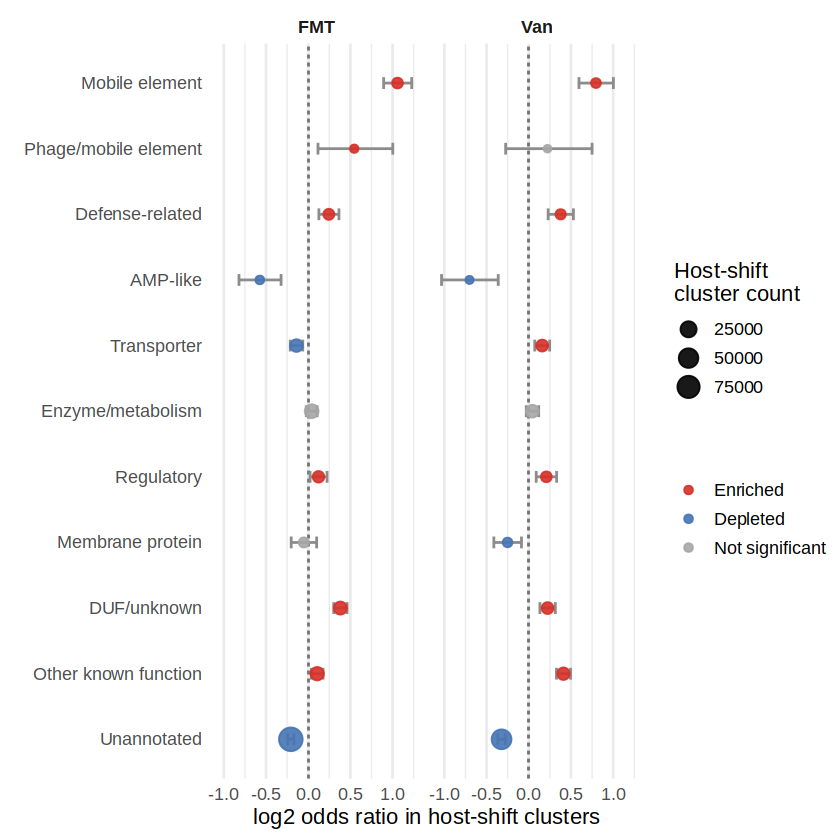

In [126]:
p_function_enrichment_forest <- ggplot(
  plot_enrichment,
  aes(x = log2_or_plot, y = test_class)
) +
  geom_vline(xintercept = 0, linetype = 2, color = "grey45") +
  geom_errorbarh(
    aes(xmin = ci_low_plot, xmax = ci_high_plot),
    height = 0.18,
    color = "grey55"
  ) +
  geom_point(
    aes(
      size = host_shift_in_class,
      color = direction
    ),
    alpha = 0.9
  ) +
  facet_wrap(~ group, ncol = 2) +
  scale_color_manual(
    values = c(
      "Enriched" = "#D73027",
      "Depleted" = "#4575B4",
      "Not significant" = "grey65"
    )
  ) +
  scale_size_continuous(range = c(1.5, 6)) +
  labs(
    x = "log2 odds ratio in host-shift clusters",
    y = "",
    color = "",
    size = "Host-shift\ncluster count"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major.y = element_blank(),
    strip.text = element_text(face = "bold"),
    legend.position = "right"
  )

p_function_enrichment_forest
ggexport(p_function_enrichment_forest,filename = "downstream_analysis/figures/f.rv.dark_cds_dark_matter_transporter_enrichment_forest_26_06_08.pdf",
         width = 8,height = 6)

### 2. changed cluster analysis and case

In [129]:
library(dplyr)
library(tidyr)
library(stringr)
library(purrr)
library(ggplot2)
library(ggalluvial)
library(ggrepel)
library(scales)

## 只保留发生 host-shift 且属于转移元件相关功能的 cluster
candidate_mobile_shift_clusters <- cluster_host_shift_bg %>%
  filter(
    is_host_shift,
    functional_class %in% c(
      "Mobile element",
      "Phage/mobile element",
      "Defense-related"
    )
  ) %>%
  select(
    group,
    cluster_name,
    functional_class,
    cds_n,
    cell_n,
    sample_n,
    species_n,
    sprot_text,
    pfam_name_text,
    pfam_desc_text,
    defense_type_text,
    defense_subtype_text
  ) %>%
  distinct()

In [130]:
library(dplyr)
library(stringr)
library(tidyr)

## =========================
## 1. 给候选 cluster 加 treatment_arm
## =========================

candidate_mobile_shift_clusters2 <- candidate_mobile_shift_clusters %>%
  mutate(
    treatment_arm = case_when(
      str_detect(group, regex("^FMT", ignore_case = TRUE)) ~ "FMT",
      str_detect(group, regex("^Van|Vancomycin", ignore_case = TRUE)) ~ "Vancomycin",
      TRUE ~ group
    )
  )

In [133]:
## Treatment-arm level pre/post cluster prevalence statistics
library(dplyr)
library(tidyr)
library(stringr)
library(purrr)

prop_test_one <- function(pre_x, pre_n, post_x, post_n) {
  if (is.na(pre_n) || is.na(post_n) || pre_n == 0 || post_n == 0) return(NA_real_)
  prop.test(x = c(post_x, pre_x), n = c(post_n, pre_n))$p.value
}

cltdf_arm_prepost <- cltdf2_anno %>%
  mutate(
    treatment_arm = case_when(
      str_detect(group, regex("^FMT", ignore_case = TRUE)) ~ "FMT",
      str_detect(group, regex("^Van|Vancomycin", ignore_case = TRUE)) ~ "Vancomycin",
      TRUE ~ as.character(group)
    ),
    condition2 = factor(condition2, levels = c("Pre", "Post"))
  ) %>%
  filter(!is.na(treatment_arm), !is.na(condition2), !is.na(cluster_name), !is.na(cell_id))

cell_arm_background <- cltdf_arm_prepost %>%
  distinct(treatment_arm, condition2, cell_id) %>%
  count(treatment_arm, condition2, name = "total_cells")

cluster_arm_prepost_stat <- cltdf_arm_prepost %>%
  distinct(treatment_arm, condition2, cluster_name, cell_id) %>%
  count(treatment_arm, condition2, cluster_name, name = "cluster_cells") %>%
  complete(treatment_arm, condition2, cluster_name, fill = list(cluster_cells = 0)) %>%
  left_join(cell_arm_background, by = c("treatment_arm", "condition2")) %>%
  mutate(cluster_cell_rate = cluster_cells / total_cells) %>%
  select(treatment_arm, condition2, cluster_name, cluster_cells, total_cells, cluster_cell_rate) %>%
  pivot_wider(
    names_from = condition2,
    values_from = c(cluster_cells, total_cells, cluster_cell_rate),
    values_fill = 0
  ) %>%
  mutate(
    delta_cell_rate = cluster_cell_rate_Post - cluster_cell_rate_Pre,
    log2_fc = log2((cluster_cell_rate_Post + 1e-6) / (cluster_cell_rate_Pre + 1e-6)),
    p_value = pmap_dbl(
      list(cluster_cells_Pre, total_cells_Pre, cluster_cells_Post, total_cells_Post),
      prop_test_one
    )
  ) %>%
  group_by(treatment_arm) %>%
  mutate(padj = p.adjust(p_value, method = "BH")) %>%
  ungroup()


Warning message:
“There were 311241 warnings in `mutate()`.
The first warning was:
ℹ In argument: `p_value = pmap_dbl(...)`.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect
ℹ Run `dplyr::last_dplyr_warnings()` to see the 311240 remaining warnings.”


In [134]:
key_cluster_score_table <- candidate_mobile_shift_clusters2 %>%
  left_join(
    cluster_arm_prepost_stat %>%
      select(
        treatment_arm,
        cluster_name,
        cluster_cells_Pre,
        cluster_cells_Post,
        total_cells_Pre,
        total_cells_Post,
        cluster_cell_rate_Pre,
        cluster_cell_rate_Post,
        delta_cell_rate,
        log2_fc,
        p_value,
        padj
      ),
    by = c("treatment_arm", "cluster_name")
  ) %>%
  mutate(
    abs_delta_cell_rate = abs(delta_cell_rate),
    direction = case_when(
      padj < 0.05 & delta_cell_rate > 0 ~ "Increased after treatment",
      padj < 0.05 & delta_cell_rate < 0 ~ "Decreased after treatment",
      delta_cell_rate > 0 ~ "Increased trend",
      delta_cell_rate < 0 ~ "Decreased trend",
      TRUE ~ "No clear change"
    ),

    priority_score =
      log10(cell_n + 1) +
      log10(sample_n + 1) +
      log10(species_n + 1) +
      abs_delta_cell_rate * 10 +
      ifelse(padj < 0.05, 2, 0) +
      ifelse(functional_class == "Mobile element", 1, 0)
  ) %>%
  arrange(desc(priority_score))

key_cluster_score_table

group,cluster_name,functional_class,cds_n,cell_n,sample_n,species_n,sprot_text,pfam_name_text,pfam_desc_text,⋯,total_cells_Post,cluster_cell_rate_Pre,cluster_cell_rate_Post,delta_cell_rate,log2_fc,p_value,padj,abs_delta_cell_rate,direction,priority_score
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Van,cl2233557,Mobile element,1282,870,9,34,,HTH_Tnp_1,Transposase,⋯,15610,0.068521843,0.0204996797,-0.048022164,-1.7409133,2.352951e-71,9.405241e-69,0.048022164,Decreased after treatment,8.964308
FMT,cl4268823,Mobile element,1517,1102,10,31,,HTH_Tnp_1,Transposase,⋯,13792,0.046541245,0.0171113689,-0.029429876,-1.4435013,2.306168e-46,1.686910e-42,0.029429876,Decreased after treatment,8.883417
FMT,cl1104830,Mobile element,1395,1143,8,50,,Gp49,Phage derived protein Gp49-like (DUF891),⋯,13792,0.031490593,0.0440835267,0.012592933,0.4853056,6.399747e-09,1.768454e-07,0.012592933,Increased after treatment,8.846168
Van,cl1513660,Defense-related,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),⋯,15610,0.059545183,0.0145419603,-0.045003222,-2.0336881,2.844033e-77,1.467053e-74,0.045003222,Decreased after treatment,8.716476
Van,cl3242909,Mobile element,541,533,10,53,,Recombinase,Recombinase,⋯,15610,0.019898265,0.0021140295,-0.017784235,-3.2339654,6.043540e-45,9.257226e-43,0.017784235,Decreased after treatment,8.679170
FMT,cl2362282,Mobile element,744,713,10,45,,Recombinase,Recombinase,⋯,13792,0.021765557,0.0123259861,-0.009439571,-0.8202931,4.165888e-10,1.563211e-08,0.009439571,Decreased after treatment,8.652244
Van,cl2362282,Mobile element,744,713,10,45,,Recombinase,Recombinase,⋯,15610,0.012417714,0.0058936579,-0.006524056,-1.0750358,6.537999e-07,7.743109e-06,0.006524056,Decreased after treatment,8.623089
Van,cl4268823,Mobile element,1517,1102,10,31,,HTH_Tnp_1,Transposase,⋯,15610,0.005236385,0.0022421525,-0.002994233,-1.2233191,4.144721e-04,2.738759e-03,0.002994233,Decreased after treatment,8.619061
Van,cl1374532,Mobile element,801,781,9,50,,Resolvase,"Resolvase, N terminal domain",⋯,15610,0.001496110,0.0003203075,-0.001175803,-2.2201538,4.798953e-03,2.269521e-02,0.001175803,Decreased after treatment,8.612535


In [135]:
nrow(key_cluster_score_table)

[1] 12265

In [136]:
top_key_clusters <- key_cluster_score_table %>%
  filter(
    cell_n >= 5,
    sample_n >= 2,
    species_n >= 2
  ) %>%
  arrange(desc(priority_score)) %>%
  slice_head(n = 20)

top_key_clusters


group,cluster_name,functional_class,cds_n,cell_n,sample_n,species_n,sprot_text,pfam_name_text,pfam_desc_text,⋯,total_cells_Post,cluster_cell_rate_Pre,cluster_cell_rate_Post,delta_cell_rate,log2_fc,p_value,padj,abs_delta_cell_rate,direction,priority_score
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Van,cl2233557,Mobile element,1282,870,9,34,,HTH_Tnp_1,Transposase,⋯,15610,0.068521843,0.0204996797,-0.048022164,-1.7409133,2.352951e-71,9.405241e-69,0.048022164,Decreased after treatment,8.964308
FMT,cl4268823,Mobile element,1517,1102,10,31,,HTH_Tnp_1,Transposase,⋯,13792,0.046541245,0.0171113689,-0.029429876,-1.4435013,2.306168e-46,1.686910e-42,0.029429876,Decreased after treatment,8.883417
FMT,cl1104830,Mobile element,1395,1143,8,50,,Gp49,Phage derived protein Gp49-like (DUF891),⋯,13792,0.031490593,0.0440835267,0.012592933,0.4853056,6.399747e-09,1.768454e-07,0.012592933,Increased after treatment,8.846168
Van,cl1513660,Defense-related,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),⋯,15610,0.059545183,0.0145419603,-0.045003222,-2.0336881,2.844033e-77,1.467053e-74,0.045003222,Decreased after treatment,8.716476
Van,cl3242909,Mobile element,541,533,10,53,,Recombinase,Recombinase,⋯,15610,0.019898265,0.0021140295,-0.017784235,-3.2339654,6.043540e-45,9.257226e-43,0.017784235,Decreased after treatment,8.679170
FMT,cl2362282,Mobile element,744,713,10,45,,Recombinase,Recombinase,⋯,13792,0.021765557,0.0123259861,-0.009439571,-0.8202931,4.165888e-10,1.563211e-08,0.009439571,Decreased after treatment,8.652244
Van,cl2362282,Mobile element,744,713,10,45,,Recombinase,Recombinase,⋯,15610,0.012417714,0.0058936579,-0.006524056,-1.0750358,6.537999e-07,7.743109e-06,0.006524056,Decreased after treatment,8.623089
Van,cl4268823,Mobile element,1517,1102,10,31,,HTH_Tnp_1,Transposase,⋯,15610,0.005236385,0.0022421525,-0.002994233,-1.2233191,4.144721e-04,2.738759e-03,0.002994233,Decreased after treatment,8.619061
Van,cl1374532,Mobile element,801,781,9,50,,Resolvase,"Resolvase, N terminal domain",⋯,15610,0.001496110,0.0003203075,-0.001175803,-2.2201538,4.798953e-03,2.269521e-02,0.001175803,Decreased after treatment,8.612535


In [140]:
case_cluster <- top_key_clusters %>%
  slice_head(n = 1) %>%
  pull(cluster_name)

case_group <- top_key_clusters %>%
  slice_head(n = 1) %>%
  pull(group)

case_cluster = "cl2233557"
case_cluster
case_group
case_cluster_distribution <- cltdf2_anno %>%
  filter(
    cluster_name == case_cluster,
    group == case_group
  ) %>%
  distinct(group, condition2, species, cell_id, sample, contig_id) %>%
  group_by(group, condition2, species) %>%
  summarise(
    cell_n = n_distinct(cell_id),
    sample_n = n_distinct(sample),
    contig_n = n_distinct(contig_id),
    .groups = "drop"
  ) %>%
  arrange(condition2, desc(cell_n))

case_cluster_distribution

[1] "cl2233557"

[1] "Van"

group,condition2,species,cell_n,sample_n,contig_n
<chr>,<fct>,<chr>,<int>,<int>,<int>
Van,Pre,Mediterraneibacter gnavus,410,2,664
Van,Pre,[Clostridium] innocuum,12,1,13
Van,Pre,Parabacteroides distasonis,6,1,8
Van,Pre,Thomasclavelia ramosa,6,1,10
Van,Pre,Longicatena caecimuris,5,1,10
Van,Pre,[Clostridium] scindens,4,1,5
Van,Pre,Bifidobacterium breve,3,1,16
Van,Pre,Blautia hominis,3,1,3
Van,Pre,Bacteroides thetaiotaomicron,2,2,2


In [142]:
case_cluster_annotation <- cluster_function_anno %>%
  filter(cluster_name == case_cluster) %>%
  select(
    cluster_name,
    functional_class,
    cds_n,
    cell_n,
    sample_n,
    species_n,
    sprot_text,
    pfam_name_text,
    pfam_desc_text,
    defense_type_text,
    defense_subtype_text,
    defense_activity_text
  )

case_cluster_annotation
case_cluster_sequences <- cltdf2_anno %>%
  filter(cluster_name == case_cluster) %>%
  distinct(
    cluster_name,
    cluster_id,
    contig_id,
    cell_id,
    sample,
    group,
    condition2,
    species
  ) %>%
  arrange(group, condition2, species)

case_cluster_sequences

cluster_name,functional_class,cds_n,cell_n,sample_n,species_n,sprot_text,pfam_name_text,pfam_desc_text,defense_type_text,defense_subtype_text,defense_activity_text
<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
cl2233557,Mobile element,1282,870,9,34,,HTH_Tnp_1,Transposase,,,


cluster_name,cluster_id,contig_id,cell_id,sample,group,condition2,species
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>
cl2233557,lib1_out_TCGTAGAACAGGGCCGATGTCAAGCGGTC_JGLKOLCL_00425_1,lib2_out_CTTCTCTACAGGAGTCCGGTCAAAACAAC_NNOHCLPJ_00166_1,lib2_out_CTTCTCTACAGGAGTCCGGTCAAAACAAC,C295_1,FMT,Pre,Agathobacter rectalis
cl2233557,lib1_out_TCGTAGAACAGGGCCGATGTCAAGCGGTC_JGLKOLCL_00425_1,lib2_out_CTAGCCTACAGTTAGGACGTCAAGTAGTC_AMEEIDHO_00091_1,lib2_out_CTAGCCTACAGTTAGGACGTCAAGTAGTC,C295_1,FMT,Pre,Alitiscatomonas sp900066535
cl2233557,lib1_out_TCGTAGAACAGGGCCGATGTCAAGCGGTC_JGLKOLCL_00425_1,lib2_out_TATCTCAACAGGGCCGATGTCAGTAATCG_AMHLFKND_00325_1,lib2_out_TATCTCAACAGGGCCGATGTCAGTAATCG,C295_1,FMT,Pre,Alitiscatomonas sp900066535
cl2233557,lib1_out_TCGTAGAACAGGGCCGATGTCAAGCGGTC_JGLKOLCL_00425_1,lib1_out_GTGTTAGACAGCAAGTTGGTCAAAGGTTC_OJENDIGB_00609_1,lib1_out_GTGTTAGACAGCAAGTTGGTCAAAGGTTC,C295_1,FMT,Pre,Bacteroides fragilis
cl2233557,lib1_out_TCGTAGAACAGGGCCGATGTCAAGCGGTC_JGLKOLCL_00425_1,lib2_out_CGAACATACAGTGCTTGCGTCAAGAATCT_ABCEDHIJ_00273_1,lib2_out_CGAACATACAGTGCTTGCGTCAAGAATCT,C295_1,FMT,Pre,Bacteroides fragilis
cl2233557,lib1_out_TCGTAGAACAGGGCCGATGTCAAGCGGTC_JGLKOLCL_00425_1,lib1_out_CGATGGCACAGTAAGAGAGTCACAGTAAC_LBCNLIGP_00145_1,lib1_out_CGATGGCACAGTAAGAGAGTCACAGTAAC,C295_1,FMT,Pre,Blautia parvula
cl2233557,lib1_out_TCGTAGAACAGGGCCGATGTCAAGCGGTC_JGLKOLCL_00425_1,lib1_out_CTTAGGAACAGTTCGAAGGTCAAGAATCT_CFCFHMLF_00267_1,lib1_out_CTTAGGAACAGTTCGAAGGTCAAGAATCT,C295_1,FMT,Pre,Blautia parvula
cl2233557,lib1_out_TCGTAGAACAGGGCCGATGTCAAGCGGTC_JGLKOLCL_00425_1,lib2_out_CAGTCCTACAGACGAGGAGTCAGGGTTGC_CBDKANBG_00075_1,lib2_out_CAGTCCTACAGACGAGGAGTCAGGGTTGC,C295_1,FMT,Pre,Blautia parvula
cl2233557,lib1_out_TCGTAGAACAGGGCCGATGTCAAGCGGTC_JGLKOLCL_00425_1,lib2_out_CGCTTCAACAGGCCTCTAGTCAGGATGTT_IHOPELBM_00024_1,lib2_out_CGCTTCAACAGGCCTCTAGTCAGGATGTT,C295_1,FMT,Pre,Blautia wexlerae


In [183]:
head(cltdf2)
clan = unique(cltdf2[,c("cluster_name","sample")])
sample_group_map <- data.frame(
  sample = c(
    "A1", "A2",
    "B1", "B2",
    "C282_1", "C282_2", "C282_3",
    "C295_1", "C295_2", "C295_3"
  ),
  sample_name = c(
    "FMT2", "FMT2",
    "Van2", "Van2",
    "Van1", "Van1", "Van1",
    "FMT1", "FMT1", "FMT1"
  ),
  stringsAsFactors = FALSE
)
clan = merge(clan,sample_group_map,by = "sample")
nrow(cltdf2_anno)
cltdf2_anno = merge(cltdf2_anno,clan,by = "cluster_name")
nrow(cltdf2_anno)

,cluster_name,cluster_id,contig_id,cell_id,sample,group,condition2,species,order,class,hypothetical_rate,cellnum,total_species_cds
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>
1,cl558142,GATCGAT_TACTTGT_ACGATAC_BIBIHLOC_00661_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01527_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
2,cl538369,GACTACA_GAAACTC_CGACTTC_IIKHPPGI_00583_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01162_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
3,cl502123,CTTCTCT_GTATAAG_TCTGGAA_DAEGBPMO_00033_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_00372_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
4,cl2792948,lib2_out_ATTCTACACAGCACTCCAGTCAAATCTTG_DFINIBOJ_00378_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01674_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
5,cl425366,CGTTCTG_TCAGATG_AGTGGGA_CJAGLNOB_00155_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01408_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
6,cl362947,CGAGAAG_GACGTGC_CGCGTTT_PJPMHMPN_00220_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01201_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439


[1] 11150714

[1] 56482472

In [184]:
head(cltdf2_anno)

,cluster_name,cluster_id,contig_id,cell_id,sample.x,group,condition2,species,order,class,⋯,best_pfam_description,best_pfam_function_class,pfam_names,pfam_function_classes,has_known_function,dark_level,has_defense_hit,amp_length_aa,sample.y,sample_name
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<lgl>,<dbl>,<chr>,<chr>
1,cl10,AAACCTG_AAACGTC_AGCTCCT_DOMAFCLC_00074_1,CAGCAGC_TCTGAGA_GTAATCG_DGPBJLDA_01067_1,CAGCAGC_TCTGAGA_GTAATCG,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,⋯,Septum formation initiator,Other Pfam,DivIC,Other Pfam,FALSE,Unannotated,FALSE,NA,C295_1,FMT1
2,cl10,AAACCTG_AAACGTC_AGCTCCT_DOMAFCLC_00074_1,CAGCAGC_TCTGAGA_GTAATCG_DGPBJLDA_01067_1,CAGCAGC_TCTGAGA_GTAATCG,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,⋯,Septum formation initiator,Other Pfam,DivIC,Other Pfam,FALSE,Unannotated,FALSE,NA,B1,Van2
3,cl10,AAACCTG_AAACGTC_AGCTCCT_DOMAFCLC_00074_1,CAGCAGC_TCTGAGA_GTAATCG_DGPBJLDA_01067_1,CAGCAGC_TCTGAGA_GTAATCG,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,⋯,Septum formation initiator,Other Pfam,DivIC,Other Pfam,FALSE,Unannotated,FALSE,NA,C295_3,FMT1
4,cl10,AAACCTG_AAACGTC_AGCTCCT_DOMAFCLC_00074_1,CAGCAGC_TCTGAGA_GTAATCG_DGPBJLDA_01067_1,CAGCAGC_TCTGAGA_GTAATCG,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,⋯,Septum formation initiator,Other Pfam,DivIC,Other Pfam,FALSE,Unannotated,FALSE,NA,A2,FMT2
5,cl10,AAACCTG_AAACGTC_AGCTCCT_DOMAFCLC_00074_1,CAGCAGC_TCTGAGA_GTAATCG_DGPBJLDA_01067_1,CAGCAGC_TCTGAGA_GTAATCG,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,⋯,Septum formation initiator,Other Pfam,DivIC,Other Pfam,FALSE,Unannotated,FALSE,NA,A1,FMT2
6,cl10,AAACCTG_AAACGTC_AGCTCCT_DOMAFCLC_00074_1,CAGCTAA_GGGCACT_AAGGTTC_EJNDDGLM_00214_1,CAGCTAA_GGGCACT_AAGGTTC,A2,FMT,Post,Hungatella effluvii,Lachnospirales,Clostridia,⋯,Septum formation initiator,Other Pfam,DivIC,Other Pfam,FALSE,Unannotated,FALSE,NA,C295_1,FMT1


In [ ]:
qsave(cltdf2_anno,file = "data/dark_matter/summary/all_merged_hypo_prodigal/cltdf2_anno_26_06_08.qs")

In [143]:
library(dplyr)
library(tidyr)
library(stringr)
library(purrr)
library(ggplot2)
library(ggpubr)
library(scales)

## =========================
## 1. 全部 cluster 基础表
## =========================

cltdf_all_stability <- cltdf2_anno %>%
  mutate(
    treatment_arm = case_when(
      str_detect(group, regex("^FMT", ignore_case = TRUE)) ~ "FMT",
      str_detect(group, regex("^Van|Vancomycin", ignore_case = TRUE)) ~ "Vancomycin",
      TRUE ~ group
    ),
    condition2 = factor(condition2, levels = c("Pre", "Post"))
  ) %>%
  filter(
    !is.na(treatment_arm),
    !is.na(group),
    !is.na(condition2),
    !is.na(cluster_name),
    !is.na(cell_id),
    !is.na(species),
    species != ""
  )
cell_background_all <- cltdf_all_stability %>%
  distinct(treatment_arm, group, condition2, cell_id) %>%
  count(treatment_arm, group, condition2, name = "total_cells")

cluster_cell_rate_all <- cltdf_all_stability %>%
  distinct(treatment_arm, group, condition2, cluster_name, cell_id) %>%
  count(treatment_arm, group, condition2, cluster_name, name = "cluster_cells") %>%
  left_join(
    cell_background_all,
    by = c("treatment_arm", "group", "condition2")
  ) %>%
  mutate(cluster_cell_rate = cluster_cells / total_cells) %>%
  select(treatment_arm, group, condition2, cluster_name, cluster_cells, total_cells, cluster_cell_rate) %>%
  pivot_wider(
    names_from = condition2,
    values_from = c(cluster_cells, total_cells, cluster_cell_rate),
    values_fill = 0
  ) %>%
  mutate(
    delta_cell_rate = cluster_cell_rate_Post - cluster_cell_rate_Pre,
    abs_delta_cell_rate = abs(delta_cell_rate),
    log2_fc = log2((cluster_cell_rate_Post + 1e-6) / (cluster_cell_rate_Pre + 1e-6))
  )

bray_similarity_from_df <- function(df) {
  wide <- df %>%
    select(condition2, species, prop) %>%
    pivot_wider(
      names_from = species,
      values_from = prop,
      values_fill = 0
    )

  if (!"Pre" %in% wide$condition2) {
    pre_vec <- rep(0, ncol(wide) - 1)
  } else {
    pre_vec <- wide %>%
      filter(condition2 == "Pre") %>%
      select(-condition2) %>%
      as.numeric()
  }

  if (!"Post" %in% wide$condition2) {
    post_vec <- rep(0, ncol(wide) - 1)
  } else {
    post_vec <- wide %>%
      filter(condition2 == "Post") %>%
      select(-condition2) %>%
      as.numeric()
  }

  denom <- sum(pre_vec + post_vec)

  if (denom == 0) return(NA_real_)

  bray_dist <- sum(abs(pre_vec - post_vec)) / denom
  1 - bray_dist
}
cluster_species_prop_all <- cltdf_all_stability %>%
  distinct(treatment_arm, group, condition2, cluster_name, species, cell_id) %>%
  count(treatment_arm, group, condition2, cluster_name, species, name = "cell_n") %>%
  group_by(treatment_arm, group, condition2, cluster_name) %>%
  mutate(prop = cell_n / sum(cell_n)) %>%
  ungroup()

cluster_species_stability_all <- cluster_species_prop_all %>%
  group_by(treatment_arm, group, cluster_name) %>%
  summarise(
    bray_similarity = bray_similarity_from_df(cur_data()),
    pre_species_n = n_distinct(species[condition2 == "Pre"]),
    post_species_n = n_distinct(species[condition2 == "Post"]),
    shared_species_n = length(intersect(
      unique(species[condition2 == "Pre"]),
      unique(species[condition2 == "Post"])
    )),
    union_species_n = length(union(
      unique(species[condition2 == "Pre"]),
      unique(species[condition2 == "Post"])
    )),
    .groups = "drop"
  ) %>%
  mutate(
    species_jaccard = shared_species_n / union_species_n,
    species_turnover_rate = 1 - species_jaccard
  )
cluster_global_stability <- cluster_cell_rate_all %>%
  left_join(
    cluster_species_stability_all,
    by = c("treatment_arm", "group", "cluster_name")
  ) %>%
  mutate(
    bray_similarity = replace_na(bray_similarity, 0),
    species_turnover_rate = replace_na(species_turnover_rate, 1)
  )

cluster_global_stability

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `bray_similarity = bray_similarity_from_df(cur_data())`.
ℹ In group 1: `treatment_arm = "FMT"`, `group = "FMT"`, `cluster_name =
  "cl10"`.
Caused by warning:
! `cur_data()` was deprecated in dplyr 1.1.0.
ℹ Please use `pick()` instead.”


treatment_arm,group,cluster_name,cluster_cells_Pre,cluster_cells_Post,total_cells_Pre,total_cells_Post,cluster_cell_rate_Pre,cluster_cell_rate_Post,delta_cell_rate,abs_delta_cell_rate,log2_fc,bray_similarity,pre_species_n,post_species_n,shared_species_n,union_species_n,species_jaccard,species_turnover_rate
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
FMT,FMT,cl10,6,17,17275,13792,3.473227e-04,0.0012325986,8.852759e-04,8.852759e-04,1.824376556,0.3333333,6,4,2,8,0.2500000,0.7500000
FMT,FMT,cl1000004,2,10,17275,13792,1.157742e-04,0.0007250580,6.092838e-04,6.092838e-04,2.636362751,1.0000000,1,1,1,1,1.0000000,0.0000000
FMT,FMT,cl1000008,21,40,17275,13792,1.215630e-03,0.0029002320,1.684602e-03,1.684602e-03,1.253775758,0.8571429,4,1,1,4,0.2500000,0.7500000
FMT,FMT,cl1000010,1,4,17275,13792,5.788712e-05,0.0002900232,2.321361e-04,2.321361e-04,2.305110152,1.0000000,1,1,1,1,1.0000000,0.0000000
FMT,FMT,cl1000031,2,8,17275,13792,1.157742e-04,0.0005800464,4.642722e-04,4.642722e-04,2.314931327,0.7777778,1,3,1,3,0.3333333,0.6666667
FMT,FMT,cl1000039,1,0,17275,0,5.788712e-05,0.0000000000,-5.788712e-05,5.788712e-05,-5.879880215,0.0000000,1,0,0,1,0.0000000,1.0000000
FMT,FMT,cl1000044,1,0,17275,0,5.788712e-05,0.0000000000,-5.788712e-05,5.788712e-05,-5.879880215,0.0000000,1,0,0,1,0.0000000,1.0000000
FMT,FMT,cl1000045,1,0,17275,0,5.788712e-05,0.0000000000,-5.788712e-05,5.788712e-05,-5.879880215,0.0000000,1,0,0,1,0.0000000,1.0000000
FMT,FMT,cl1000320,7,20,17275,13792,4.052098e-04,0.0014501160,1.044906e-03,1.044906e-03,1.836865764,0.8571429,2,3,1,4,0.2500000,0.7500000


In [180]:
colnames(cltdf2)

[1] "cluster_name"      "cluster_id"        "contig_id"        
 [4] "cell_id"           "sample"            "group"            
 [7] "condition2"        "species"           "order"            
[10] "class"             "hypothetical_rate" "cellnum"          
[13] "total_species_cds"

In [181]:

qsave(cluster_global_stability,file = "data/dark_matter/summary/all_merged_hypo_prodigal/cluster_global_stability_26_06_08.qs")
nrow(cluster_global_stability)
cluster_global_stability = merge(cluster_global_stability,clan,by = "cluster_name")
nrow(cluster_global_stability)

,cluster_name,cluster_id,contig_id,cell_id,sample,group,condition2,species,order,class,hypothetical_rate,cellnum,total_species_cds
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>
1,cl558142,GATCGAT_TACTTGT_ACGATAC_BIBIHLOC_00661_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01527_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
2,cl538369,GACTACA_GAAACTC_CGACTTC_IIKHPPGI_00583_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01162_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
3,cl502123,CTTCTCT_GTATAAG_TCTGGAA_DAEGBPMO_00033_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_00372_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
4,cl2792948,lib2_out_ATTCTACACAGCACTCCAGTCAAATCTTG_DFINIBOJ_00378_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01674_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
5,cl425366,CGTTCTG_TCAGATG_AGTGGGA_CJAGLNOB_00155_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01408_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439
6,cl362947,CGAGAAG_GACGTGC_CGCGTTT_PJPMHMPN_00220_1,AAACCTG_AAACGTC_TCTGGAA_MINIFDAB_01201_1,AAACCTG_AAACGTC_TCTGGAA,A2,FMT,Post,Mediterraneibacter gnavus,Lachnospirales,Clostridia,0.5672334,4503,3939439


[1] 427418

[1] 1821556

In [178]:
colnames(cluster_global_stability)
head(cluster_global_stability)
cluster_global_stability = merge(cluster_global_stability)

[1] "treatment_arm"          "group"                  "cluster_name"          
 [4] "cluster_cells_Pre"      "cluster_cells_Post"     "total_cells_Pre"       
 [7] "total_cells_Post"       "cluster_cell_rate_Pre"  "cluster_cell_rate_Post"
[10] "delta_cell_rate"        "abs_delta_cell_rate"    "log2_fc"               
[13] "bray_similarity"        "pre_species_n"          "post_species_n"        
[16] "shared_species_n"       "union_species_n"        "species_jaccard"       
[19] "species_turnover_rate"

treatment_arm,group,cluster_name,cluster_cells_Pre,cluster_cells_Post,total_cells_Pre,total_cells_Post,cluster_cell_rate_Pre,cluster_cell_rate_Post,delta_cell_rate,abs_delta_cell_rate,log2_fc,bray_similarity,pre_species_n,post_species_n,shared_species_n,union_species_n,species_jaccard,species_turnover_rate
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
FMT,FMT,cl10,6,17,17275,13792,3.473227e-04,0.0012325986,8.852759e-04,8.852759e-04,1.824377,0.3333333,6,4,2,8,0.2500000,0.7500000
FMT,FMT,cl1000004,2,10,17275,13792,1.157742e-04,0.0007250580,6.092838e-04,6.092838e-04,2.636363,1.0000000,1,1,1,1,1.0000000,0.0000000
FMT,FMT,cl1000008,21,40,17275,13792,1.215630e-03,0.0029002320,1.684602e-03,1.684602e-03,1.253776,0.8571429,4,1,1,4,0.2500000,0.7500000
FMT,FMT,cl1000010,1,4,17275,13792,5.788712e-05,0.0002900232,2.321361e-04,2.321361e-04,2.305110,1.0000000,1,1,1,1,1.0000000,0.0000000
FMT,FMT,cl1000031,2,8,17275,13792,1.157742e-04,0.0005800464,4.642722e-04,4.642722e-04,2.314931,0.7777778,1,3,1,3,0.3333333,0.6666667
FMT,FMT,cl1000039,1,0,17275,0,5.788712e-05,0.0000000000,-5.788712e-05,5.788712e-05,-5.879880,0.0000000,1,0,0,1,0.0000000,1.0000000


In [144]:
library(dplyr)
library(tidyr)
library(stringr)
library(scales)
library(tidyplots)

## =========================
## 1. 过滤低信息 cluster
## =========================

cluster_global_stability_filt <- cluster_global_stability %>%
  mutate(
    cluster_cells_Pre = replace_na(cluster_cells_Pre, 0),
    cluster_cells_Post = replace_na(cluster_cells_Post, 0),
    cluster_cell_rate_Pre = replace_na(cluster_cell_rate_Pre, 0),
    cluster_cell_rate_Post = replace_na(cluster_cell_rate_Post, 0),

    total_detected_cells = cluster_cells_Pre + cluster_cells_Post,
    max_cell_rate = pmax(cluster_cell_rate_Pre, cluster_cell_rate_Post),
    present_both = cluster_cells_Pre > 0 & cluster_cells_Post > 0
  )

## 用非零 cluster 的中位数作为动态阈值，避免阈值太武断
min_rate <- cluster_global_stability_filt %>%
  filter(max_cell_rate > 0) %>%
  summarise(x = quantile(max_cell_rate, 0.5, na.rm = TRUE)) %>%
  pull(x)

min_rate <- max(min_rate, 0.001)

cluster_global_stability_filt <- cluster_global_stability_filt %>%
  filter(
    total_detected_cells >= 50,
    max_cell_rate >= min_rate,
    present_both
  )

nrow(cluster_global_stability)
nrow(cluster_global_stability_filt)
min_rate

[1] 427418

[1] 38911

[1] 0.001

In [145]:
global_stability_long_filt <- cluster_global_stability_filt %>%
  select(
    treatment_arm,
    group,
    cluster_name,
    bray_similarity,
    abs_delta_cell_rate,
    species_turnover_rate
  ) %>%
  pivot_longer(
    cols = c(bray_similarity, abs_delta_cell_rate, species_turnover_rate),
    names_to = "metric",
    values_to = "value"
  ) %>%
  mutate(
    metric = recode(
      metric,
      bray_similarity = "Species composition similarity",
      abs_delta_cell_rate = "|Post - Pre cell proportion|",
      species_turnover_rate = "Species turnover rate"
    ),
    metric = factor(
      metric,
      levels = c(
        "Species composition similarity",
        "|Post - Pre cell proportion|",
        "Species turnover rate"
      )
    ),
    treatment_arm = factor(treatment_arm, levels = c("FMT", "Vancomycin"))
  )

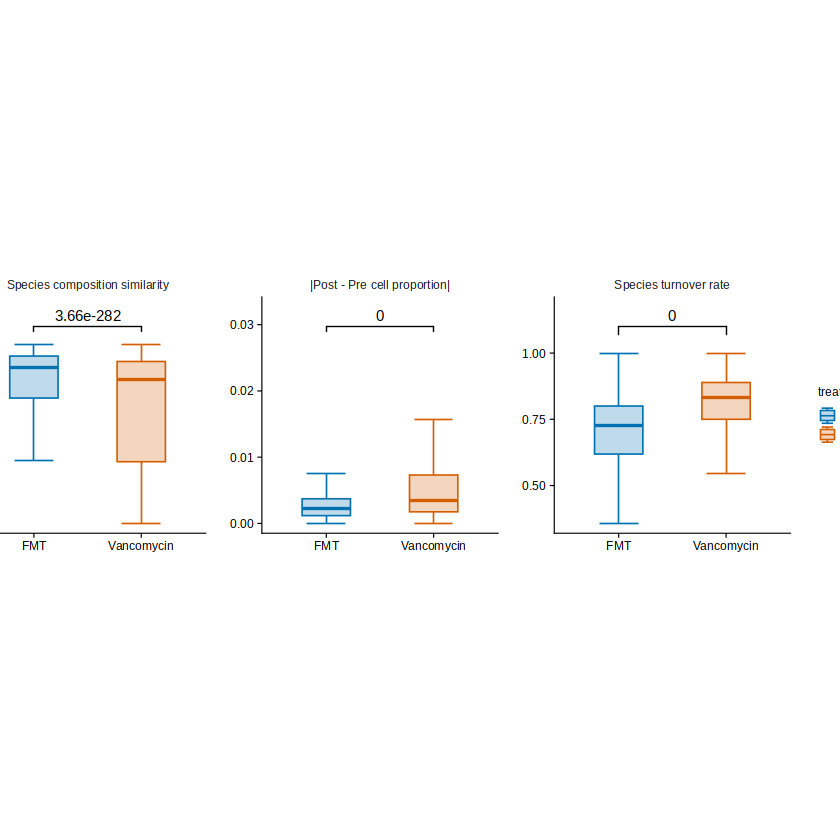

In [146]:
library(dplyr)
library(tidyplots)

## =========================
## 1. 只为画图创建 value_plot
## =========================

delta_ymax <- global_stability_long_filt %>%
  filter(metric == "|Post - Pre cell proportion|") %>%
  summarise(ymax = quantile(value, 0.99, na.rm = TRUE)) %>%
  pull(ymax)

global_stability_long_filt_plot <- global_stability_long_filt %>%
  mutate(
    value_plot = case_when(
      metric == "|Post - Pre cell proportion|" ~ pmin(value, delta_ymax),
      TRUE ~ value
    )
  )

p_global_stability_summary_tidy <- global_stability_long_filt_plot |>
  tidyplot(
    x = treatment_arm,
    y = value_plot,
    color = treatment_arm
  ) |>
  add_boxplot(
    box_width = 0.45,
    alpha = 0.25,
    show_outliers = FALSE,
    linewidth = 0.35
  ) |>
  add_test_pvalue(
    method = "wilcox_test",
    comparisons = list(c("FMT", "Vancomycin")),
    label = "p.adj",
    hide_info = TRUE,
    label.size = 3
  ) |>
  adjust_x_axis(title = "") |>
  adjust_y_axis(title = "") |>
  split_plot(by = metric, nrow = 1)

p_global_stability_summary_tidy

In [147]:
ggexport(p_global_stability_summary_tidy,
         filename = "downstream_analysis/figures/f.rv.cluster_global_stability_summary_boxplot_26_06_08.pdf",
        width = 12,height = 5)


file saved to downstream_analysis/figures/f.rv.cluster_global_stability_summary_boxplot_26_06_08.pdf



## Hub cluster select

In [150]:
colnames(key_cluster_score_table)
table(key_cluster_score_table$functional_class)

[1] "group"                  "cluster_name"           "functional_class"      
 [4] "cds_n"                  "cell_n"                 "sample_n"              
 [7] "species_n"              "sprot_text"             "pfam_name_text"        
[10] "pfam_desc_text"         "defense_type_text"      "defense_subtype_text"  
[13] "treatment_arm"          "cluster_cells_Pre"      "cluster_cells_Post"    
[16] "total_cells_Pre"        "total_cells_Post"       "cluster_cell_rate_Pre" 
[19] "cluster_cell_rate_Post" "delta_cell_rate"        "log2_fc"               
[22] "p_value"                "padj"                   "abs_delta_cell_rate"   
[25] "direction"              "priority_score"


     Defense-related       Mobile element Phage/mobile element 
                6569                 5128                  568 

In [176]:
head(key_cluster_score_table)

group,cluster_name,functional_class,cds_n,cell_n,sample_n,species_n,sprot_text,pfam_name_text,pfam_desc_text,⋯,total_cells_Post,cluster_cell_rate_Pre,cluster_cell_rate_Post,delta_cell_rate,log2_fc,p_value,padj,abs_delta_cell_rate,direction,priority_score
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Van,cl2233557,Mobile element,1282,870,9,34,,HTH_Tnp_1,Transposase,⋯,15610,0.06852184,0.020499680,-0.048022164,-1.7409133,2.352951e-71,9.405241e-69,0.048022164,Decreased after treatment,8.964308
FMT,cl4268823,Mobile element,1517,1102,10,31,,HTH_Tnp_1,Transposase,⋯,13792,0.04654124,0.017111369,-0.029429876,-1.4435013,2.306168e-46,1.686910e-42,0.029429876,Decreased after treatment,8.883417
FMT,cl1104830,Mobile element,1395,1143,8,50,,Gp49,Phage derived protein Gp49-like (DUF891),⋯,13792,0.03149059,0.044083527,0.012592933,0.4853056,6.399747e-09,1.768454e-07,0.012592933,Increased after treatment,8.846168
Van,cl1513660,Defense-related,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),⋯,15610,0.05954518,0.014541960,-0.045003222,-2.0336881,2.844033e-77,1.467053e-74,0.045003222,Decreased after treatment,8.716476
Van,cl3242909,Mobile element,541,533,10,53,,Recombinase,Recombinase,⋯,15610,0.01989826,0.002114029,-0.017784235,-3.2339654,6.043540e-45,9.257226e-43,0.017784235,Decreased after treatment,8.679170
FMT,cl2362282,Mobile element,744,713,10,45,,Recombinase,Recombinase,⋯,13792,0.02176556,0.012325986,-0.009439571,-0.8202931,4.165888e-10,1.563211e-08,0.009439571,Decreased after treatment,8.652244


In [151]:
library(dplyr)
library(stringr)
library(ggplot2)
library(ggrepel)
library(scales)
library(forcats)

meaningful_cluster_table <- key_cluster_score_table %>%
  mutate(
    abs_delta_cell_rate = abs(delta_cell_rate),
    neg_log10_fdr = -log10(padj + 1e-300),
    meaningful = case_when(
      padj < 0.05 &
        abs_delta_cell_rate >= max(0.005, quantile(abs_delta_cell_rate, 0.90, na.rm = TRUE)) &
        cell_n >= 5 &
        sample_n >= 2 ~ TRUE,
        # functional_class != "Unannotated" ~ TRUE,
      TRUE ~ FALSE
    ),
    direction = case_when(
      meaningful & delta_cell_rate > 0 ~ "Increased after treatment",
      meaningful & delta_cell_rate < 0 ~ "Decreased after treatment",
      TRUE ~ "Not prioritized"
    )
  ) %>%
  arrange(desc(meaningful), desc(priority_score))

meaningful_clusters <- meaningful_cluster_table %>%
  filter(meaningful)

nrow(meaningful_clusters)
table(meaningful_clusters$functional_class)

[1] 536


     Defense-related       Mobile element Phage/mobile element 
                 260                  250                   26 

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's alpha values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's alpha values.”
file saved to downstream_analysis/figures/f.rv.hub_cluster_vocano_26_06_08.pdf



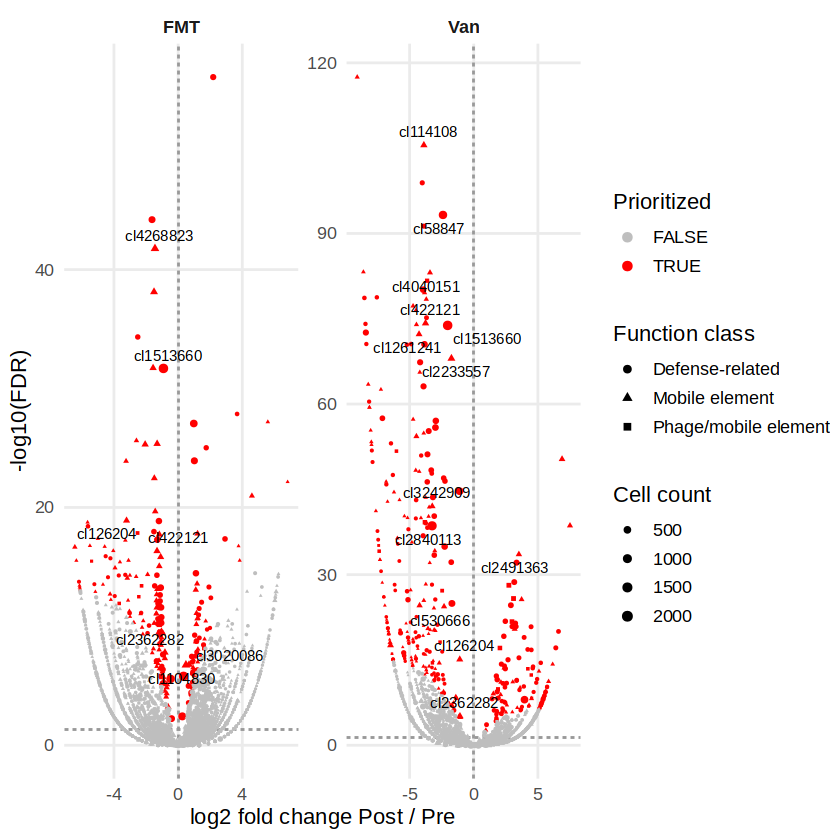

In [155]:
top_label_clusters <- meaningful_cluster_table %>%
  filter(meaningful) %>%
  arrange(desc(priority_score)) %>%
  slice_head(n = 20)

p_meaningful_cluster_volcano <- meaningful_cluster_table %>%
  ggplot(aes(x = log2_fc, y = neg_log10_fdr)) +
  geom_hline(yintercept = -log10(0.05), linetype = 2, color = "grey60") +
  geom_vline(xintercept = 0, linetype = 2, color = "grey60") +
  geom_point(
    aes(
      shape = functional_class,
      size = cell_n,
      color = meaningful
    )
  ) +
  geom_text_repel(
    data = top_label_clusters,
    aes(label = cluster_name),
    size = 3,
    max.overlaps = 40
  ) +
  facet_wrap(~ group, scales = "free") +
  scale_alpha_manual(values = c("TRUE" = 0.9, "FALSE" = 0.25)) +
  scale_size_continuous(range = c(0.1, 2)) +
  labs(
    x = "log2 fold change Post / Pre",
    y = "-log10(FDR)",
    shape = "Function class",
    size = "Cell count",
    color = "Prioritized"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    strip.text = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  ) + scale_color_manual(values = c("grey","red"))

p_meaningful_cluster_volcano
ggexport(p_meaningful_cluster_volcano,
         filename = "downstream_analysis/figures/f.rv.hub_cluster_vocano_26_06_08.pdf",
        width = 12,height = 5)


In [173]:
library(dplyr)
library(tidyplots)
library(ggpubr)

meaningful_cluster_class_stack <- meaningful_cluster_table %>%
  filter(meaningful) %>%
  count(group, functional_class, name = "cluster_n") %>%
  group_by(group) %>%
  mutate(
    cluster_prop = cluster_n / sum(cluster_n)
  ) %>%
  ungroup()

Warning message in ggplot2::stat_summary(fun = .fun, geom = "bar", color = NA, width = width, :
“Ignoring unknown parameters: `stacking`”
file saved to downstream_analysis/figures/f.rv.hub_cluster_basic_stat_26_06_08.pdf



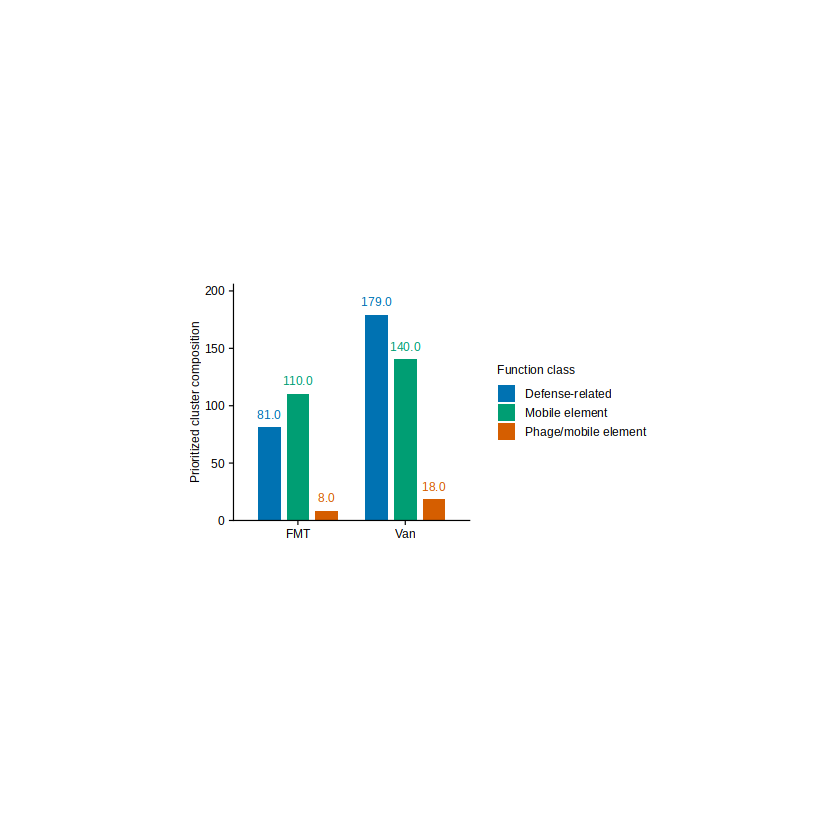

In [174]:
p_meaningful_cluster_class_stack_prop <- meaningful_cluster_class_stack |>
  tidyplot(
    x = group,
    y = cluster_n,
    color = functional_class
  ) |>
  add_sum_bar(
    stacking = "fill"
  ) |>
  add_sum_value() |>
  adjust_x_axis(title = "") |>
  adjust_y_axis(title = "Prioritized cluster composition") |>
  adjust_legend_title("Function class")
p_meaningful_cluster_class_stack_prop
ggexport(p_meaningful_cluster_class_stack_prop,
         filename = "downstream_analysis/figures/f.rv.hub_cluster_basic_stat_26_06_08.pdf",
        width = 5,height = 4)


In [154]:
head(meaningful_cluster_table)

group,cluster_name,functional_class,cds_n,cell_n,sample_n,species_n,sprot_text,pfam_name_text,pfam_desc_text,⋯,cluster_cell_rate_Post,delta_cell_rate,log2_fc,p_value,padj,abs_delta_cell_rate,direction,priority_score,neg_log10_fdr,meaningful
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<lgl>
Van,cl2233557,Mobile element,1282,870,9,34,,HTH_Tnp_1,Transposase,⋯,0.020499680,-0.048022164,-1.7409133,2.352951e-71,9.405241e-69,0.048022164,Decreased after treatment,8.964308,68.026630,TRUE
FMT,cl4268823,Mobile element,1517,1102,10,31,,HTH_Tnp_1,Transposase,⋯,0.017111369,-0.029429876,-1.4435013,2.306168e-46,1.686910e-42,0.029429876,Decreased after treatment,8.883417,41.772908,TRUE
FMT,cl1104830,Mobile element,1395,1143,8,50,,Gp49,Phage derived protein Gp49-like (DUF891),⋯,0.044083527,0.012592933,0.4853056,6.399747e-09,1.768454e-07,0.012592933,Increased after treatment,8.846168,6.752406,TRUE
Van,cl1513660,Defense-related,2657,2299,10,72,,ArdA,Antirestriction protein (ArdA),⋯,0.014541960,-0.045003222,-2.0336881,2.844033e-77,1.467053e-74,0.045003222,Decreased after treatment,8.716476,73.833554,TRUE
Van,cl3242909,Mobile element,541,533,10,53,,Recombinase,Recombinase,⋯,0.002114029,-0.017784235,-3.2339654,6.043540e-45,9.257226e-43,0.017784235,Decreased after treatment,8.679170,42.033519,TRUE
FMT,cl2362282,Mobile element,744,713,10,45,,Recombinase,Recombinase,⋯,0.012325986,-0.009439571,-0.8202931,4.165888e-10,1.563211e-08,0.009439571,Decreased after treatment,8.652244,7.805982,TRUE


In [160]:
case_clusters <- meaningful_cluster_table %>%
  filter(meaningful,cell_n > 200,abs_delta_cell_rate > 0.01) %>%
  group_by(group) %>%
  arrange(desc(priority_score), .by_group = TRUE) %>%
  slice_head(n = 5) %>%
  ungroup() %>%
  distinct(group, cluster_name, functional_class, priority_score)

case_clusters
case_cluster_species_comp <- cltdf2_anno %>%
  mutate(
    condition2 = factor(condition2, levels = c("Pre", "Post"))
  ) %>%
  inner_join(case_clusters, by = c("group", "cluster_name")) %>%
  distinct(group, condition2, cluster_name, functional_class, species, cell_id) %>%
  count(group, condition2, cluster_name, functional_class, species, name = "cell_n")
top_species_case <- case_cluster_species_comp %>%
  group_by(species) %>%
  summarise(total_cell_n = sum(cell_n), .groups = "drop") %>%
  arrange(desc(total_cell_n)) %>%
  slice_head(n = 10) %>%
  pull(species)

case_cluster_species_comp_plot <- case_cluster_species_comp %>%
  mutate(
    species_plot = ifelse(species %in% top_species_case, species, "Other"),
    group_cluster = paste(group, cluster_name, sep = " | ")
  ) %>%
  group_by(group, cluster_name, group_cluster, condition2, species_plot, functional_class) %>%
  summarise(cell_n = sum(cell_n), .groups = "drop") %>%
  group_by(group_cluster, condition2) %>%
  mutate(prop = cell_n / sum(cell_n)) %>%
  ungroup()

group,cluster_name,functional_class,priority_score
<chr>,<chr>,<chr>,<dbl>
FMT,cl4268823,Mobile element,8.883417
FMT,cl1104830,Mobile element,8.846168
FMT,cl1513660,Defense-related,8.590882
FMT,cl422121,Mobile element,8.390574
FMT,cl2840113,Defense-related,8.341558
Van,cl2233557,Mobile element,8.964308
Van,cl1513660,Defense-related,8.716476
Van,cl3242909,Mobile element,8.679170
Van,cl530666,Mobile element,8.604386


file saved to downstream_analysis/figures/f.rv.hub_cluster_case_species_composition_26_06_08.pdf



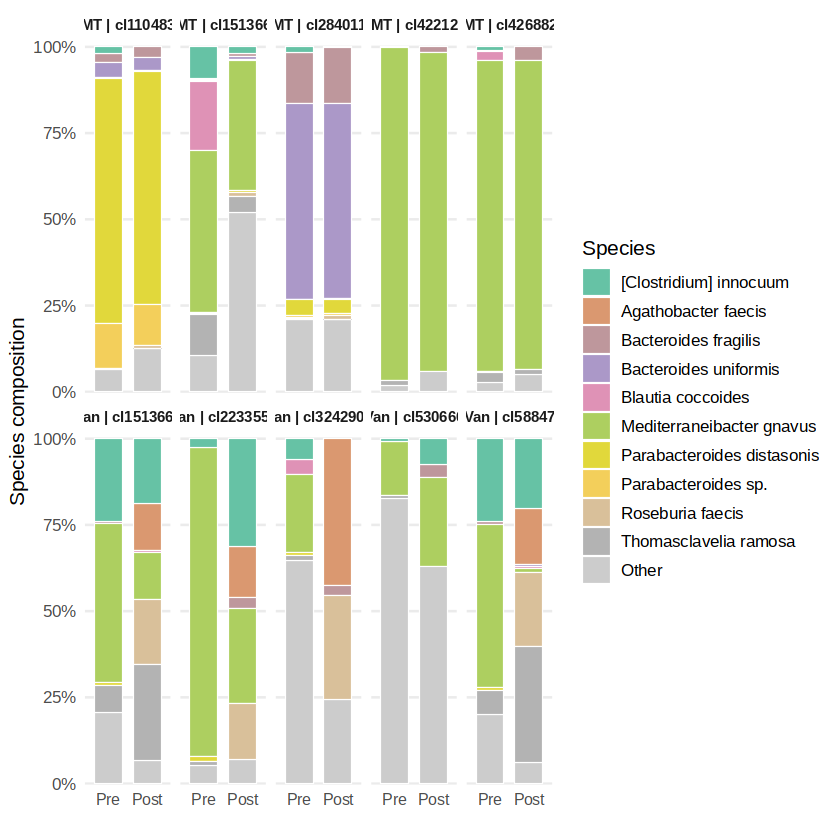

In [175]:
library(RColorBrewer)

species_levels <- levels(factor(case_cluster_species_comp_plot$species_plot))
species_main <- setdiff(species_levels, "Other")

species_cols <- setNames(
  colorRampPalette(brewer.pal(8, "Set2"))(length(species_main)),
  species_main
)

species_cols <- c(
  species_cols,
  "Other" = "grey80"
)
case_cluster_species_comp_plot$species_plot <- factor(
  case_cluster_species_comp_plot$species_plot,
  levels = c(sort(setdiff(unique(case_cluster_species_comp_plot$species_plot), "Other")), "Other")
)
p_case_cluster_species_comp_clean <- ggplot(
  case_cluster_species_comp_plot,
  aes(x = condition2, y = prop, fill = species_plot)
) +
  geom_col(width = 0.72, color = "white", linewidth = 0.25) +
  facet_wrap(~ group_cluster, ncol = 5) +
  scale_y_continuous(
    labels = percent_format(),
    expand = expansion(mult = c(0, 0.02))
  ) +
  scale_fill_manual(values = species_cols) +
  labs(
    x = "",
    y = "Species composition",
    fill = "Species"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    strip.text = element_text(size = 8.5, face = "bold"),
    axis.text.x = element_text(size = 9),
    legend.position = "right"
  )

p_case_cluster_species_comp_clean
ggexport(p_case_cluster_species_comp_clean,
         filename = "downstream_analysis/figures/f.rv.hub_cluster_case_species_composition_26_06_08.pdf",
        width = 8,height = 8)


In [166]:
head(case_cluster_species_comp_plot)

group,cluster_name,group_cluster,condition2,species_plot,functional_class,cell_n,prop
<chr>,<chr>,<chr>,<fct>,<fct>,<chr>,<int>,<dbl>
FMT,cl1104830,FMT | cl1104830,Pre,Bacteroides fragilis,Mobile element,15,0.027573529
FMT,cl1104830,FMT | cl1104830,Pre,Bacteroides uniformis,Mobile element,24,0.044117647
FMT,cl1104830,FMT | cl1104830,Pre,Mediterraneibacter gnavus,Mobile element,1,0.001838235
FMT,cl1104830,FMT | cl1104830,Pre,Other,Mobile element,35,0.064338235
FMT,cl1104830,FMT | cl1104830,Pre,Parabacteroides distasonis,Mobile element,387,0.711397059
FMT,cl1104830,FMT | cl1104830,Pre,Parabacteroides sp.,Mobile element,70,0.128676471
